# FinScore v2.0.12 — PUDIM

In [ ]:
## Alterações metodológicas: Versão 2.0.12
# 1. Retificação de erro de sinal na reconstrução do lucro líquido.
# 2. Conserto de parâmetro de exportação invertido.
# 3. Alteração do hash.
# 4. Reconstrução patrimonial assimétrica: inversão do sinal para corrigir.
# 5. Introdução em Monte Carlo de choques por exercício e por contas.
# 6. Autorestes acresceram testes de fidelidade econômica.
# 7. excesso de fontes: por padrão, vira caixa/aplicação financeira explícita.
# 8. Alternativas de amortização ou distribuição ficam parametrizadas.
# 9. Financiamento adicional: passa a aumentar tanto os subtotais do passivo quanto as contas de empréstimos, para não criar dívida “invisível” aos índices.
# 10. Monte Carlo: a abordagem atual permanece como sensibilidade independente; a nova usa fator comum persistente por exercício, choque específico por conta e cargas econômicas predefinidas.
# 11. Rejeição máxima aceitável: 25%, com alerta e invalidação interpretativa acima desse limite.
# 12. Redundância FP: material se a amplitude entre as três especificações atingir 25 pontos do FinScore estrutural ou mais.


## Alterações metodológicas: Versão 2.0.11
# 1. Reorganização da estrutura markdown e comentários do script.

## Alterações metodológicas Versão 2.0.10
# 1.  Saída final ao parecerista incorpora informações monte carlo e pca.
   
## Alterações metodológicas Versão 2.0.9
# 1.  Revisão completa do código.
# 2.  Comentários em cada célula do código.
# 3.  Testes com números diversos de simulações e validação do monte carlo.

## Alterações metodológicas Versão 2.0.7
# 1. cada indicador passou a separar nível atual (60%), trajetória (25%) e resiliência (15%);
# 2. o PCA passou a usar índices orientados e padronizados de forma robusta, com participação máxima de 15% e teste de estabilidade;
# 3. os núcleos passaram a ser agregados por média geométrica, com componente de gargalo e caps prudenciais;
# 4. foi criado um índice de confiabilidade separado do FinScore;
# 5. curvas excessivamente saturadas foram substituídas por tetos econômicos de 95 pontos;
# 6. o PL deixou de ser conta residual do Monte Carlo; ele é sorteado como driver explícito e o Ativo Total fecha a identidade;
# 7. foram incluídos cenários determinísticos, faixa de incerteza para classificação desconhecida da dívida e contribuição por indicador;
# 8. novos autotestes verificam monotonicidade, invariância monetária, não compensação, estabilidade do PCA e limites dos choques.

## 0. CONFIGURAÇÃO

#### 0.1 Caminho

In [2]:
# ALTERAR
CAMINHO_PLANILHA = r"C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\1Callamarys.xlsx"

In [3]:
# NÃO MEXER
import os
from pathlib import Path

if 'CAMINHO_PLANILHA' not in globals():
    raise NameError(
        "Variável `CAMINHO_PLANILHA` não definida. Edite a célula 0.1 Caminho antes de executar."
    )

# Normaliza para Path
CAMINHO_PLANILHA = CAMINHO_PLANILHA if isinstance(CAMINHO_PLANILHA, Path) else Path(CAMINHO_PLANILHA)

if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    dados_teste = Path.cwd() / "dados_teste"
    if dados_teste.exists():
        disponiveis = sorted(set(disponiveis) | set(dados_teste.glob("*.xlsx")), key=lambda p: str(p))
    if disponiveis:
        print("Arquivo não encontrado. Planilhas disponíveis (caminhos):")
        for arquivo in disponiveis:
            print(" -", arquivo)
    else:
        print("Arquivo não encontrado. Nenhuma planilha .xlsx encontrada em `cwd` ou `dados_teste`.")
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )

ABA_DADOS = os.environ.get("FINSCORE_ABA", "lancamentos")

#### 0.2 Serasa

In [4]:
# ALTERAR
# Evidência comportamental externa: permanece separada do FinScore.
SERASA_SCORE = 700               # inteiro ou float entre 0 e 1.000
SERASA_DATA_CONSULTA = "2026-07-23"       # exemplo: "2026-07-23"

# ALTERAR
# Indica se há restrição grave no Serasa. Quando True, apenas sinaliza o caso
# para análise especial; não altera o FinScore, o Serasa Score nem o Monte Carlo.
SERASA_RESTRICAO_GRAVE = False

#### 0.3 Exportar Excel

In [5]:
# 1: exportar; 0: Não exportar. Padrão: não exportar.
# VALOR PADRÃO: 0: Não.

import os
EXPORTAR_EXCEL = os.environ.get("FINSCORE_EXPORTAR", "1") == "0"

#### 0.4 Proxi de Juros

In [ ]:
# Padrão True: modelo admite: Despesas com Juros ~ Despesas Financeiras
USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS = True 


***

## 1. AMBIENTE


#### 1.1 Identificação do Modelo

In [6]:
# NÃO MEXER

# Versão do modelo
VERSAO_MODELO = "2.0.11"

In [7]:
# NÃO MEXER

# # Hash das células de código com a própria linha do hash neutralizada.
# É preenchido na geração deste notebook e permite identificar a implementação.
HASH_CODIGO_MODELO = "f3bed4ffb78cc427923520c31a2d351acc3d3478a9a7b5c651f8924ba80b29d9"

In [8]:
# NÃO MEXER
# Definição robusta de data/hora e arquivo de saída para evitar colisões de nome
import datetime as _dt
from pathlib import Path
import os

DATA_HORA_PROCESSAMENTO = _dt.datetime.now()

ARQUIVO_SAIDA = Path(
    os.environ.get(
        "FINSCORE_SAIDA",
        f"resultados_finscore_{VERSAO_MODELO}_{DATA_HORA_PROCESSAMENTO:%Y%m%d_%H%M}.xlsx",
    )
)

print(f"Versão: {VERSAO_MODELO}")
print(f"Hash do código: {HASH_CODIGO_MODELO}")
if "CAMINHO_PLANILHA" in globals():
    try:
        print(f"Planilha: {Path(CAMINHO_PLANILHA).resolve()}")
    except Exception:
        print("Planilha: definida, mas não é possível resolver o caminho.")
else:
    print("Planilha: CAMINHO_PLANILHA não definida.")

print(f"Aba: {ABA_DADOS if 'ABA_DADOS' in globals() else '<NA>'}")

Versão: 2.0.11
Hash do código: f3bed4ffb78cc427923520c31a2d351acc3d3478a9a7b5c651f8924ba80b29d9
Planilha: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\1Callamarys.xlsx
Aba: lancamentos


#### 1.2 Bibliotecas Python

In [9]:
# NÃO MEXER
import math
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

#### 1.3 Setup FinScore

##### 1. Monte Carlo

In [10]:
# Valor padrão em investigação
MONTE_CARLO_NUM = 1000

In [11]:
# NÃO MEXER
NUM_SIMULACOES = int(os.environ.get("FINSCORE_SIMULACOES", MONTE_CARLO_NUM))
SEMENTE = int(os.environ.get("FINSCORE_SEMENTE", "20260723"))

In [12]:
## MONTE CARLO
# Parâmetros gerais e de sensibilidade.
# Amplitudes mínima e máxima dos choques
DELTA_MIN = 0.05 # O algoritmo observa a maior variação histórica da conta entre os três anos. Se essa variação tiver sido inferior a 5%, usará 5%.
DELTA_MAX = 0.35 # Se uma conta tiver variado 60% historicamente, o Monte Carlo não repetirá toda essa amplitude. O choque ficará limitado a 35%.
# Ponto crítico: os limites de 5% e 35% são escolhas normativas. Precisam ser justificados e testados empiricamente para verificar se não produzem incerteza artificialmente estreita ou ampla.

# Tolerância contábil: Permite divergência de até 1% na verificação das identidades contábeis.
BALANCE_TOLERANCE = 0.01/2

# Limite de tentativas do Monte Carlo
MAX_ATTEMPT_FACTOR = 40 # fator de multiplicação do número de simulações.

# Cobertura mínima de cada núcleo
# Exige que pelo menos 70% do peso informacional de um núcleo esteja disponível para calcular sua nota. O FinScore possui dois núcleos:econômico-operacional e financeiro-patrimonial. A cobertura considera os pesos dos indicadores e sua disponibilidade temporal. Não é simplesmente “70% da quantidade de índices”. Exemplo: Indicadores disponíveis representam 80% dos pesos → núcleo calculado; Indicadores disponíveis representam 60% dos pesos → núcleo não calculado. Se a cobertura ficar abaixo de 70%, a nota do núcleo recebe NaN. Isso evita calcular um resultado aparentemente preciso com informações insuficientes.
# O limite de 70% também é normativo e precisa ser validado por testes de sensibilidade.
MIN_NUCLEUS_COVERAGE = 0.70

# Limites de sensibilidade do FinScore. Após as simulações, o algoritmo calcula a frequência com que cada versão do FinScore ficou abaixo de 125, 250 e 500. Se a frequência for maior que o limite, o FinScore é considerado sensível e recebe alerta. O analista deve avaliar se a sensibilidade é aceitável ou se há necessidade de ajustes.
SENSITIVITY_THRESHOLDS = [125, 250, 500]

In [13]:
# Somente drivers são sorteados. Totais contábeis e resultados conciliados são # derivados; por isso não se atribui a eles uma "amplitude declarada" falsa.
# Esse conjunto contém os chamados drivers, isto é, contas primárias submetidas diretamente aos choques aleatórios ou determinísticos da simulação.
# A lógica é que essas contas representam as fontes iniciais das alterações econômicas. Por exemplo, no cenário adverso: Receita cai; Contas a receber aumentam; Estoques aumentam; Caixa diminui; Dívida aumenta. 
# Depois desses choques, o modelo deve reconstruir os totais e resultados contábeis correspondentes.
SIMULATION_DRIVER_ACCOUNTS = {
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Imobilizado_Liquido", "p_Fornecedores",
    "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
    "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
    "r_Despesa_IR_CSLL", "r_Despesas_Financeiras",
}


##### 2. PCA

In [14]:
# ============================================================
# CONSTANTES DO PCA — Estabilidade e Adaptabilidade
# ============================================================

# Seed para reproduzibilidade dos testes de estabilidade do PCA
PCA_STABILITY_SEED = 42

# Número mínimo de variáveis ativas para aceitar o PCA
PCA_MIN_ACTIVE_VARIABLES = 3

# Número de repetições do teste de estabilidade
PCA_STABILITY_REPETITIONS = 160

# Desvio-padrão do ruído nas perturbações de estabilidade
PCA_PERTURBATION_SD = 0.05

# Distância L1 máxima permitida entre pesos originais e perturbados
PCA_MAX_MEAN_L1_DISTANCE = 0.25

# Similaridade de cosseno mínima entre pesos originais e perturbados
PCA_MIN_MEAN_COSINE = 0.90

# Maior peso individual que o PCA puro pode atribuir a um indicador
PCA_MAX_PURE_WEIGHT = 0.50

# Compartilhamento adaptativo: até 15% dos pesos podem vir do PCA
PCA_ADAPTIVE_SHARE = 0.15

# Pesos dos núcleos EO e FP na agregação final por média geométrica
NUCLEUS_WEIGHTS = {
    "EO": 0.50,  # Econômico-Operacional
    "FP": 0.50,  # Financeiro-Patrimonial
}

# Compartilhamento do gargalo: quanto a nota é puxada para baixo pelo núcleo mais fraco
BOTTLENECK_SHARE = 0.25

# Clipping robusto para padronização: limita extremos a ±3 desvios-padrão robustos
PCA_ROBUST_CLIP = 3.0

In [15]:
## PCA
# A nota temporal deixa de ser uma média opaca dos três anos.
# Nível atual domina; trajetória e pior desempenho evitam leitura pontual.
TEMPORAL_COMPONENT_WEIGHTS = {
    "nivel_atual": 0.60, # É a nota do indicador no balanço mais recente. e as notas anuais de liquidez forem: 2023: 40; 2024: 60; e 2025: 80, então: nível atual = 80 -- O ano mais recente domina a nota temporal com peso de 60%.
    "trajetoria": 0.25, # Mede se o indicador melhorou ou piorou entre o primeiro e o último ano válido: trajetória = 50 + 0,5 × (nota final − nota inicial). No exemplo: trajetória = 50 + 0,5 × (80 − 40) -- trajetória = 70. A interpretação é: 50: estabilidade; acima de 50: melhoria; abaixo de 50: deterioração. O resultado é limitado ao intervalo de 0 a 100.
    "resiliencia": 0.15, # É a pior nota observada nos três exercícios:
}

# O PCA é diagnóstico auxiliar. Com três observações, não pode definir sozinho a relevância econômica dos indicadores.
# Esse bloco controla quanto o PCA pode influenciar os pesos dos indicadores e quando essa influência será aceita.
# A lógica geral é:
# calcular pesos fixos definidos economicamente;
# calcular os pesos sugeridos pelo PCA;
# testar se esses pesos do PCA são estáveis;
# se forem estáveis, permitir influência máxima de 15%;

In [16]:
## 1. Participação do PCA
# No caso, define que o PCA pode responder por apenas 15% do peso final de cada indicador.
# Os outros 85% vêm dos pesos fixos definidos pela metodologia:
# peso final = 85% × peso fixo + 15% × peso indicado pelo PCA
PCA_ADAPTIVE_SHARE = 0.15

In [17]:
## 2. Número mínimo de indicadores
# O PCA somente será utilizado se houver pelo menos três indicadores válidos e com variabilidade suficiente no núcleo analisado.
# três ou mais indicadores utilizáveis: tenta calcular o PCA;
# menos de três: abandona o PCA e utiliza os pesos fixos.
# “Indicador ativo” não significa apenas indicador preenchido. Ele também precisa apresentar alguma variação entre os três exercícios. Uma variável constante não fornece informação de variância ao PCA.
PCA_MIN_ACTIVE_VARIABLES = 3

In [18]:
## 3. Número de testes de estabilidade
# Depois de calcular o PCA original, o algoritmo cria 160 pequenas perturbações nos dados e recalcula os pesos.
# A pergunta é: Se os dados mudarem muito pouco, os pesos do PCA permanecem semelhantes?
# Se pequenas mudanças gerarem pesos muito diferentes, o PCA é considerado instável e descartado da ponderação final.
# Essas 160 repetições não são as simulações de Monte Carlo do FinScore. São testes internos específicos para a estabilidade dos pesos do PCA.
# Também não constituem um bootstrap inferencial, porque não há reamostragem das observações.
PCA_STABILITY_REPETITIONS = 160

In [19]:
## 4. Intensidade da perturbação
# Adiciona um ruído aleatório com desvio-padrão de 0,05 aos indicadores já padronizados. Como os dados foram padronizados, isso representa uma perturbação pequena: ruído-padrão = 5% de um desvio-padrão. 
# A finalidade não é criar cenários econômicos. É apenas verificar se uma alteração pequena muda radicalmente os pesos do PCA.
PCA_PERTURBATION_SD = 0.05

In [20]:
## 5. Distância L1 máxima
# A distância L1 soma as diferenças absolutas entre os pesos originais e os pesos obtidos após a perturbação.
# Se a distância L1 for maior que 0,25, o PCA é considerado instável e descartado da ponderação final.
PCA_MAX_MEAN_L1_DISTANCE = 0.25

In [21]:
## 6. Similaridade de cosseno mínima
# A similaridade de cosseno verifica se a estrutura relativa dos pesos perturbados continua apontando aproximadamente na mesma direção dos pesos originais.
# Ela varia, neste contexto, aproximadamente entre:
# próximo de 1: pesos muito semelhantes;
# próximo de 0: estruturas muito diferentes.
# O PCA somente é aceito se: similaridade média ≥ 0,90. Assim, o código exige pelo menos 90% de semelhança direcional média.
# A distância L1 e o cosseno são complementares:
# L1 mede quanto os valores mudaram;
# cosseno mede se o padrão relativo permaneceu semelhante.
PCA_MIN_MEAN_COSINE = 0.90

In [22]:
# Orientação usada apenas para leitura das cargas do PCA.
# A importância usa cargas absolutas e, portanto, não depende do sinal.

# Esses três indicadores têm relação inversa com a capacidade financeira:
# maior endividamento exigível → pior;
# maior dívida líquida/ativo → pior;
# maior concentração do endividamento no curto prazo → pior.
# O valor -1 informa essa direção desfavorável. Indicadores não listados presumivelmente têm direção positiva: quanto maiores, melhor.
# No PCA, uma carga pode ser positiva ou negativa sem que isso, isoladamente, defina a importância do indicador. A importância é calculada pelo valor absoluto:
# Assim:
# Carga = +0,80 → importância = 0,80
# Carga = −0,80 → importância = 0,80
# O sinal serve apenas para interpretar a direção da relação com o componente. Ele não altera o peso adaptativo dado ao indicador.
# Há uma distinção essencial:
# INDICATOR_DIRECTION: interpretação econômica previamente estabelecida;
# sinal da carga do PCA: associação estatística dentro daquela amostra.
# Esses sinais não são necessariamente iguais. Além disso, o sinal de um componente principal pode ser completamente invertido sem alterar o PCA. Por isso, o código está correto ao não usar diretamente o sinal da carga como medida de importância.
INDICATOR_DIRECTION = {
    "endividamento_exigivel": -1,
    "divida_liquida_ativo": -1,
    "composicao_endividamento": -1,
}

##### 3. Parâmetros de controle

In [23]:
# ALTERAR APENAS SE TIVER CERTEZA DO QUE ESTÁ FAZENDO

# Definição das regras que orientam a validação dos dados, o tratamento de inconsistências, os limites de materialidade, a política de correções automáticas e a execução dos autotestes. 
# O objetivo é garantir que o cálculo seja feito de forma consistente, auditable e com transparência sobre quando o resultado pode ser considerado confiável ou provisório.

In [24]:
# VALOR PADRÃO: Sim: 1.

# Eles verificam, entre outras coisas, se:
# existem as 21 contas primárias;
# a identidade contábil é respeitada;
# os dados originais não são alterados;
# os scores permanecem entre 0 e 1.000;
# os pesos do PCA somam 100%;
# a participação do PCA não excede 15%;
# multiplicar todos os valores por 1.000 não muda o FinScore;
# aumentar a dívida não melhora indevidamente o score;
# aumentar caixa com capital próprio não piora o score;
# um núcleo muito ruim não é totalmente compensado pelo outro;
# a mesma semente produz as mesmas simulações;
# os choques do Monte Carlo respeitam os limites;
# os cenários determinísticos permanecem contabilmente válidos;
# inconsistências e correções são detectadas e auditadas;
# o Serasa não é misturado automaticamente ao FinScore.
EXECUTAR_AUTOTESTES = os.environ.get("FINSCORE_AUTOTESTES", "1") == "1"

In [25]:
# NÃO MEXER

## Política de correção:
# - a origem nunca é alterada;
# - correções automáticas só entram na cópia analítica quando a confiança
#   mínima é atingida;
# - toda correção automática material mantém o resultado como provisório.

## Tratamento de erros antes do cálculo
# Corrigir somente quando uma identidade contábil permitir deduzir o valor com alta confiança, preservando os dados originalmente informados.
POLITICA_CORRECAO = "HIERARQUIA_CONTABIL_CONTROLADA"

# Determina se uma correção identificada pelo algoritmo será realmente utilizada na base de análise:
# True: aplica a correção na cópia usada para calcular o FinScore;
# False: apenas registra a correção proposta, sem alterar a base analítica.
# A base original nunca é modificada.
APLICAR_CORRECOES_AUTOMATICAS = True

# Confiança mínima para corrigir automaticamente uma conta. Se a confiança for menor, a correção é apenas registrada.
LIMIAR_CONFIANCA_AUTOMATICA = 0.90

# Significa que uma alteração igual ou superior a 1% do Ativo Total é considerada material.
# Uma correção material gera alerta, bloqueia o uso definitivo do resultado e faz o score ser tratado como provisório até confirmação documental.
LIMIAR_MATERIALIDADE = 0.01       # 1% do Ativo Total

# Com Ativo Total de R$ 1.000.000: 5% × R$ 1.000.000 = R$ 50.000. Se os componentes de uma conta excederem o subtotal em pelo menos R$ 50.000, o problema recebe classificação mais grave, como potencial viés crítico.
# A diferença entre os dois limites é:
# 1%: já merece alerta por ser material;
# 5%: indica impacto alto ou crítico.
LIMIAR_VIES_ALTO = 0.05           # 5% do Ativo Total

# Se os dados ainda permitem o cálculo, mas existe uma correção ou inconsistência que impede uma decisão definitiva, apresente o FinScore como provisório.
PERMITIR_SCORE_PROVISORIO = True

# Ajustes manuais opcionais. Não use para "fazer fechar" sem documento-fonte.
# Exemplo:
# CORRECOES_MANUAIS = [{
#     "ano": 2025,
#     "conta": "p_Passivo_Nao_Circulante",
#     "valor": 123456.78,
#     "fonte": "BP assinado, p. 2",
#     "justificativa": "Erro de transcrição confirmado",
#     "responsavel": "Analista responsável",
#     "confirmado": True,
# }]
CORRECOES_MANUAIS = []

##### 4. Contas

In [26]:
## Primárias
# Contas oriundas dos lançamentos manuais. 
# São elas que recebem os choques aleatórios ou determinísticos do Monte Carlo. As demais contas derivadas são calculadas a partir dessas primárias.
PRIMARY = [
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Ativo_Circulante", "p_Imobilizado_Liquido", "p_Ativo_Total",
    "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
    "p_Obrigacoes_Trabalhistas_CP", "p_Passivo_Circulante",
    "p_Passivo_Nao_Circulante", "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Resultado_Antes_IR_CSLL",
    "r_Lucro_Liquido", "r_Receitas_Financeiras", "r_Despesa_IR_CSLL",
    "r_Despesas_Financeiras",
]

# Contas que podem ter sinal negativo
# contas como receita, CMV, despesas financeiras e despesa de IR/CSLL estão em NONNEGATIVE. Isso significa que devem ser lançadas pelo valor absoluto, sem sinal negativo
SIGNED_ACCOUNTS = {
    "p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido",
}
STRICTLY_POSITIVE = {"p_Ativo_Total"}
NONNEGATIVE = set(PRIMARY) - SIGNED_ACCOUNTS

In [27]:
## Derivadas
# São calculadas a partir das contas primárias. 
DERIVED_SIMULATION_ACCOUNTS = set(PRIMARY) - SIMULATION_DRIVER_ACCOUNTS

##### 5. CAPs

In [28]:
# Limites Contábeis Preestabelecidos

In [ ]:
# Caps preliminares e versionados. Eles não substituem calibração setorial;
# impedem apenas que uma condição patrimonial crítica receba nota incompatível.

## Condições críticas: tetos de FinScore para situações específicas
PRUDENTIAL_CAPS = {
    "pl_negativo": 350.0, # Patrimônio Líquido negativo
    "pl_ativo_abaixo_2pct": 500.0, # Capitalização inferior a 2%. Capitalização = Patrimônio Líquido / Ativo Total
    "pl_ativo_abaixo_5pct": 650.0, # Capitalização entre 2% e 5%
    "endividamento_maior_igual_100pct": 500.0, # Endividamento igual ou superior a 100%. Endividamento exigível = (Passivo Circulante + Passivo Não Circulante) / Ativo Total
    "endividamento_maior_igual_95pct": 650.0, # Endividamento entre 95% e 100%
    "cobertura_juros_abaixo_1x": 500.0, # Cobertura de juros inferior a 1x. Cobertura de juros = Resultado Antes do IR/CSLL / Despesas Financeiras
}

# r_Despesas_Financeiras só pode representar juros quando a origem da conta
# tiver sido conferida. Se False, Cobertura de Juros ficará indisponível.
COBERTURA_JUROS_TETO_ECONOMICO = 10.0 # Limita a Cobertura de Juros a 10x. Se a empresa tiver cobertura de juros de 15x, o modelo considera apenas 10x para fins de cálculo do FinScore. Isso evita que empresas com endividamento muito baixo recebam nota excessivamente alta apenas por terem juros baixos.

# Pesos estruturais: trajetória do EBIT já é capturada no bloco temporal.
# Capitalização entra explicitamente; capitalização e endividamento têm peso combinado limitado para reduzir redundância contábil.
FIXED_WEIGHTS = {
    "crescimento_receita": 0.15,
    "margem_bruta": 0.10,
    "margem_ebit": 0.30,
    "margem_liquida": 0.20,
    "giro_ativo": 0.25,
    "capitalizacao": 0.20,
    "endividamento_exigivel": 0.10,
    "liquidez_corrente": 0.15,
    "liquidez_seca": 0.10,
    "ccl_ativo": 0.10,
    "divida_liquida_ativo": 0.10,
    "cobertura_juros": 0.15,
    "composicao_endividamento": 0.10,
}

NUCLEI = {
    "EO": [
        "crescimento_receita", "margem_bruta", "margem_ebit",
        "margem_liquida", "giro_ativo",
    ],
    "FP": [
        "capitalizacao", "endividamento_exigivel", "liquidez_corrente",
        "liquidez_seca", "ccl_ativo", "divida_liquida_ativo",
        "cobertura_juros", "composicao_endividamento",
    ],
}

# O EBIT aparece de duas maneiras diferentes: seu nível relativo é capturado pela margem EBIT; sua evolução ao longo dos exercícios é capturada pelo bloco temporal.
# Verificar a calibração destes pesos posteriormente.

##### 6. Conversão

In [30]:
# Indicadores viram Notas

In [31]:
# O parâmetro CURVE_MAX_SCORE = 95.0 limita a nota máxima de cada indicador a 95. A justificativa é prudencial: um número contábil excepcional não significa empresa perfeita nem ausência total de risco. Também evita que um indicador extremamente favorável compense excessivamente fragilidades em outros.

In [32]:
# Curvas normativas preliminares. O teto econômico é 95, não 100:
# valor extremo gera alerta de plausibilidade, não prêmio adicional.
# O melhor desempenho econômico observável pelas curvas recebe, no máximo, 95 pontos. A justificativa é prudencial: um indicador excepcionalmente alto não representa ausência total de risco nem qualidade perfeita.
CURVE_MAX_SCORE = 95.0

# Os pares em ANCHORS são pontos de referência — ou “âncoras” — usados para construir uma curva por interpolação. Cada par tem o formato: (valor_do_indicador, nota_correspondente). Se a empresa tiver margem exatamente igual a uma âncora, recebe a nota associada. Se estiver entre duas âncoras, o código deve calcular uma nota intermediária por interpolação linear.
ANCHORS = {
    "crescimento_receita": [ # A curva premia crescimento e pune retração. Ponto crítico: crescimento muito alto não é necessariamente saudável. Pode decorrer de inflação, aquisição, início recente das atividades, expansão financiada por dívida ou base anterior muito baixa. Por isso, essa curva precisa ser combinada com margens, giro, liquidez e endividamento.
        (-0.30, 0), (0, 45), (0.10, 70), (0.25, 90), (0.50, 95),
    ],
    "margem_bruta": [ # Margem negativa indica que a receita não cobre os custos diretos. Margens maiores representam maior capacidade de absorver despesas operacionais, financeiras e tributárias. A fragilidade é fortemente setorial: uma distribuidora pode ser saudável com margem bruta baixa, enquanto uma prestadora de serviços pode apresentar margem muito maior. Uma curva única pode favorecer determinados modelos de negócio.
        (-0.10, 0), (0, 10), (0.15, 45), (0.30, 75), (0.50, 95),
    ],
    "margem_ebit": [ # Mede a rentabilidade operacional antes dos efeitos dos juros e dos tributos sobre o lucro. Uma margem igual a zero recebe 35 porque a operação não está produzindo lucro operacional, mas também não apresenta prejuízo operacional. Ainda assim, a nota talvez seja relativamente generosa, especialmente porque esse indicador recebe peso estrutural de 30% no núcleo EO.
        (-0.20, 0), (0, 35), (0.10, 70), (0.20, 90), (0.35, 95),
    ],
    "margem_liquida": [ # Mede quanto da receita permanece como lucro após custos, despesas, resultado financeiro e tributos. A curva alcança notas altas mais cedo que a margem EBIT porque, normalmente, a margem líquida é inferior à operacional.
        (-0.20, 0), (0, 35), (0.07, 70), (0.15, 90), (0.25, 95),
    ],
    "giro_ativo": [ # A interpretação depende do setor. Comércio tende a apresentar giro maior; atividades industriais, imobiliárias e de infraestrutura podem demandar ativos elevados e apresentar giro menor sem que isso indique baixa eficiência.
        (0, 0), (0.30, 25), (0.70, 60), (1.20, 85), (2, 95), (5, 95),
    ],
    "capitalizacao": [ # Quanto maior a participação do patrimônio próprio no financiamento dos ativos, maior a capacidade patrimonial de absorver perdas. Capitalização negativa representa passivo a descoberto. Capitalização próxima de zero recebe nota muito baixa, mesmo que o patrimônio ainda seja formalmente positivo.
        (-0.20, 0), (0, 5), (0.05, 20), (0.15, 50), (0.30, 80), (0.50, 95),
    ],
    "endividamento_exigivel": [ # Essa é uma curva decrescente: quanto maior o endividamento, menor a nota. (Endividamento exigível = (Passivo Circulante + Passivo Não Circulante) / Ativo Total)
        (0, 95), (0.30, 85), (0.50, 60), (0.70, 30), (1, 0), (1.50, 0),
    ],
    "liquidez_corrente": [ # Liquidez igual a 1 significa equivalência contábil entre ativos e passivos circulantes, mas sem folga para perdas, inadimplência, estoques obsoletos ou diferenças de vencimento. Por isso recebe nota intermediária, não alta. Liquidez excessiva também não ganha prêmio adicional. Pode inclusive indicar caixa ocioso, estoques elevados ou capital de giro mal empregado
        (0, 0), (0.70, 10), (1, 45), (1.30, 70), (1.80, 95), (4, 95),
    ],
    "liquidez_seca": [ # Ainda assim, sua interpretação é setorial: estoques são mais relevantes para uma indústria ou varejista do que para uma prestadora de serviços.
        (0, 0), (0.50, 10), (0.80, 40), (1.10, 70), (1.50, 95), (3, 95),
    ],
    "ccl_ativo": [ # Diferentemente das liquidez corrente e seca, esse indicador relaciona a folga de curto prazo ao tamanho total da empresa.
        (-0.50, 0), (-0.10, 15), (0, 45), (0.10, 65), (0.25, 85), (0.50, 95),
    ],
    "divida_liquida_ativo": [ # Valor negativo significa que o caixa supera a dívida onerosa. Entretanto, não recebe nota acima de 95 nem deve ser automaticamente considerado perfeito: caixa excepcionalmente elevado pode ser temporário ou decorrer da venda de ativos.
        (-0.30, 95), (0, 90), (0.20, 70), (0.40, 35), (0.70, 0),
    ],
    "composicao_endividamento": [ # Quanto maior a concentração das obrigações no curto prazo, maior a pressão imediata sobre o caixa. A curva não mede o volume total de dívida: uma empresa pode ter pouca dívida, mas toda no curto prazo. Por isso, deve ser interpretada em conjunto com endividamento exigível e liquidez.
        (0, 95), (0.30, 80), (0.50, 55), (0.75, 25), (1, 0),
    ],
    "cobertura_juros": [ # Cobertura igual a 1 significa que o EBIT é apenas suficiente para os juros, sem margem para oscilações. Por isso, recebe somente 25 pontos. O ponto (50, 95) mantém o platô e evita extrapolação indevida.
        (-2, 0), (0, 5), (1, 25), (2, 55), (4, 80), (10, 95), (50, 95),
    ],
}

##### 7. Definição dos cenários

In [33]:
SCENARIO_DEFINITIONS = {
    "BASE": { # O cenário combina choques que podem se reforçar mutuamente. A empresa vende menos, recebe mais lentamente, acumula estoques, perde caixa e recorre a mais dívida.
        "descricao": "Manutenção aproximada da estrutura observada.",
        "receita": 0.00, "margem_ebit": 0.00, "contas_receber": 0.00,
        "estoques": 0.00, "caixa": 0.00, "juros": 0.00,
        "divida": 0.00, "pl": 0.00, "pc_total": 0.00, "pnc_total": 0.00,
    },
    "ADVERSO": { # O cenário adverso representa uma situação de declínio econômico, onde a empresa enfrenta redução de receitas, compressão de margens e pressão sobre seu capital de giro.
        "descricao": "Queda de receita, compressão de margem e pressão de capital de giro.",
        "receita": -0.10, "margem_ebit": -0.20, "contas_receber": 0.15,
        "estoques": 0.10, "caixa": -0.15, "juros": 0.25,
        "divida": 0.10, "pl": -0.10, "pc_total": 0.08, "pnc_total": 0.05,
    },
    "SEVERO": { # O cenário severo representa uma situação de estresse econômico, onde a empresa enfrenta uma queda significativa nas receitas, margens comprimidas e desafios financeiros mais acentuados.
        "descricao": "Estresse forte de atividade, margem, liquidez e custo financeiro.",
        "receita": -0.25, "margem_ebit": -0.40, "contas_receber": 0.30,
        "estoques": 0.20, "caixa": -0.30, "juros": 0.60,
        "divida": 0.25, "pl": -0.25, "pc_total": 0.18, "pnc_total": 0.12,
    },
}

#### 1.4 Verificação da Planilha

In [34]:
assert len(PRIMARY) == 21
assert np.isclose(sum(TEMPORAL_COMPONENT_WEIGHTS.values()), 1.0)
assert np.isclose(sum(NUCLEUS_WEIGHTS.values()), 1.0)
for nucleo, colunas in NUCLEI.items():
    assert np.isclose(sum(FIXED_WEIGHTS[c] for c in colunas), 1.0)

print(f"Ambiente carregado e premissas estruturais da {VERSAO_MODELO} verificadas.")

Ambiente carregado e premissas estruturais da 2.0.11 verificadas.


In [35]:
# NÃO MEXER
if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    print("Arquivo não encontrado. Planilhas disponíveis nesta pasta:")
    for arquivo in disponiveis:
        print(" -", arquivo.name)
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )

In [36]:
# NÃO MEXER
import datetime as _dt
from pathlib import Path
import os

DATA_HORA_PROCESSAMENTO = _dt.datetime.now()
ARQUIVO_SAIDA = Path(
    os.environ.get(
        "FINSCORE_SAIDA",
        f"resultados_finscore_{VERSAO_MODELO}_{DATA_HORA_PROCESSAMENTO:%Y%m%d_%H%M}.xlsx",
    )
)

print(f"Versão: {VERSAO_MODELO}")
print(f"Hash do código: {HASH_CODIGO_MODELO}")
print(f"Planilha: {CAMINHO_PLANILHA.resolve()}")
print(f"Aba: {ABA_DADOS}")

Versão: 2.0.11
Hash do código: f3bed4ffb78cc427923520c31a2d351acc3d3478a9a7b5c651f8924ba80b29d9
Planilha: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\1Callamarys.xlsx
Aba: lancamentos


In [37]:
## Regras metodológicas da correção
# - `NaN` significa ausência ou impossibilidade de cálculo; nunca é convertido silenciosamente em zero.
# - A base original permanece imutável e recebe hash próprio.
# - Toda correção ou quarentena é registrada com regra, materialidade, confiança, impacto e confirmação.
# - Reconciliação algorítmica não equivale a validação documental.
# - O FinScore e a confiabilidade são apresentados separadamente.
# - As curvas, pesos, caps e regras de estabilidade são normativos e precisam de calibração futura por setor e porte.

#### 1.5 Verificação das Contas

In [38]:
import hashlib
import json


QUALITY_COLUMNS = [
    "severidade", "tipo", "conta", "exercicios", "detalhe",
    "bloqueia_calculo", "bloqueia_decisao", "bloqueia_score",
]

AUDIT_COLUMNS = [
    "evento_id", "data_hora", "etapa", "acao", "status_acao", "ano", "conta",
    "valor_original", "valor_proposto", "valor_utilizado", "delta_absoluto",
    "delta_percentual", "materialidade_pct_ativo", "regra_id",
    "regra_descricao", "evidencia", "confianca", "potencial_vies",
    "indicadores_afetados", "requer_confirmacao", "confirmado",
    "bloqueia_calculo", "bloqueia_decisao", "fonte", "responsavel",
]


def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    # Tolerância relativa evita divisões por denominadores materialmente nulos.
    b_float = b.astype(float)
    scale = max(float(b_float.abs().median(skipna=True) or 0.0), 1.0)
    denominator = b_float.where(b_float.abs() > 1e-9 * scale)
    return a.astype(float).div(denominator).replace([np.inf, -np.inf], np.nan)


def _is_blank_accounting_value(value) -> bool:
    if pd.isna(value):
        return True
    return str(value).strip().lower() in {
        "", "-", "--", "n/a", "na", "nan", "none", "null"
    }


def parse_accounting_value(value) -> float:
    # Converte números e textos contábeis sem confundir ausência com zero.
    if _is_blank_accounting_value(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if np.isfinite(value) else np.nan

    text = str(value).strip()
    negative_parentheses = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if not text or text in {"-", "+", ".", ","}:
        return np.nan

    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3 and len(parts) > 1
            else text.replace(",", ".")
        )
    elif text.count(".") > 1:
        parts = text.split(".")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3
            else "".join(parts[:-1]) + "." + parts[-1]
        )

    try:
        number = float(text)
    except ValueError:
        return np.nan
    return -abs(number) if negative_parentheses else number


def dataframe_sha256(df: pd.DataFrame) -> str:
    # O hash permite provar se a base usada numa execução foi alterada.
    normalized = df.copy()
    normalized = normalized.reindex(sorted(normalized.columns), axis=1)
    payload = pd.util.hash_pandas_object(
        normalized, index=True, categorize=True
    ).values.tobytes()
    return hashlib.sha256(payload).hexdigest()


def load_raw_data(path: Path, sheet_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    source = pd.read_excel(path, sheet_name=sheet_name)
    missing_columns = [c for c in ["ano", *PRIMARY] if c not in source.columns]
    if missing_columns:
        raise ValueError(f"Colunas ausentes na aba {sheet_name}: {missing_columns}")

    source = source[["ano", *PRIMARY]].dropna(how="all", subset=PRIMARY).copy()
    if len(source) != 3:
        raise ValueError(f"A aba deve ter 3 exercícios preenchidos; encontrei {len(source)}.")

    year_numeric = pd.to_numeric(source["ano"], errors="coerce")
    invalid_year = year_numeric.isna() | (year_numeric <= 0) | (year_numeric % 1 != 0)
    if invalid_year.any():
        rows = (source.index[invalid_year] + 2).tolist()
        raise ValueError(f"Exercício/ano deve ser inteiro positivo. Linhas inválidas: {rows}")
    source["ano"] = year_numeric.astype(int)
    if source["ano"].duplicated().any():
        years = source.loc[source["ano"].duplicated(keep=False), "ano"].tolist()
        raise ValueError(f"Há exercícios duplicados: {years}")
    source = source.sort_values("ano").reset_index(drop=True)

    report = []
    for column in PRIMARY:
        original = source[column].copy()
        converted = original.map(parse_accounting_value)
        blank = original.map(_is_blank_accounting_value)
        invalid = converted.isna() & ~blank
        absent = converted.isna() & blank
        if invalid.any():
            report.append({
                "severidade": "CRITICA",
                "tipo": "erro_conversao",
                "conta": column,
                "exercicios": ", ".join(source.loc[invalid, "ano"].astype(str)),
                "detalhe": "Valor textual não pôde ser convertido; revisar a origem.",
                "bloqueia_calculo": True,
                "bloqueia_decisao": True,
                "bloqueia_score": True,
            })
        if absent.any():
            report.append({
                "severidade": "AVISO",
                "tipo": "ausencia",
                "conta": column,
                "exercicios": ", ".join(source.loc[absent, "ano"].astype(str)),
                "detalhe": "Informação ausente preservada como NaN; não equivale a zero.",
                "bloqueia_calculo": False,
                "bloqueia_decisao": False,
                "bloqueia_score": False,
            })
        source[column] = converted

    return source, pd.DataFrame(report, columns=QUALITY_COLUMNS)


def _known_sum(row: pd.Series, columns: list[str]) -> float:
    values = row[columns]
    return float(values.sum(skipna=True)) if values.notna().any() else np.nan


def _balance_implied(row: pd.Series, account: str) -> float:
    at = row["p_Ativo_Total"]
    pc = row["p_Passivo_Circulante"]
    pnc = row["p_Passivo_Nao_Circulante"]
    pl = row["p_Patrimonio_Liquido"]
    return {
        "p_Ativo_Total": pc + pnc + pl,
        "p_Passivo_Circulante": at - pnc - pl,
        "p_Passivo_Nao_Circulante": at - pc - pl,
        "p_Patrimonio_Liquido": at - pc - pnc,
    }[account]


def validate_correct_and_prepare(
    raw: pd.DataFrame,
    import_report: pd.DataFrame,
    manual_corrections: list[dict] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    '''
    Cria uma cópia analítica corrigida sem modificar `raw`.

    A função separa:
    1. erro comprovável/correção;
    2. inferência por identidade;
    3. conflito não identificável/quarentena;
    4. problema ainda impeditivo.
    '''
    analysis = raw.copy(deep=True)
    issues = import_report.to_dict("records")
    audit: list[dict] = []
    manual_corrections = manual_corrections or []

    def add_issue(severity, kind, account, year, detail, calc=False, decision=False):
        issues.append({
            "severidade": severity,
            "tipo": kind,
            "conta": account,
            "exercicios": str(year),
            "detalhe": detail,
            "bloqueia_calculo": bool(calc),
            "bloqueia_decisao": bool(decision),
            "bloqueia_score": bool(calc),
        })

    def add_audit(
        *,
        stage,
        action,
        status_action,
        year,
        account,
        original,
        proposed,
        used,
        rule_id,
        rule_description,
        evidence,
        confidence,
        bias,
        indicators,
        requires_confirmation,
        confirmed,
        blocks_calculation,
        blocks_decision,
        source="",
        responsible="",
    ):
        at = raw.loc[raw["ano"].eq(year), "p_Ativo_Total"]
        at_value = float(at.iloc[0]) if len(at) and pd.notna(at.iloc[0]) else np.nan
        delta = (
            float(used - original)
            if pd.notna(used) and pd.notna(original)
            else np.nan
        )
        delta_pct = (
            delta / abs(float(original))
            if pd.notna(delta) and pd.notna(original) and abs(float(original)) > 1e-12
            else np.nan
        )
        if pd.notna(at_value) and abs(at_value) > 1e-12:
            if pd.notna(delta):
                materiality = abs(delta) / abs(at_value)
            elif pd.isna(original) and pd.notna(used):
                materiality = abs(float(used)) / abs(at_value)
            elif pd.notna(original) and pd.isna(used):
                materiality = abs(float(original)) / abs(at_value)
            elif pd.notna(proposed) and pd.notna(original):
                materiality = abs(float(proposed) - float(original)) / abs(at_value)
            else:
                materiality = np.nan
        else:
            materiality = np.nan
        audit.append({
            "evento_id": f"EVT-{len(audit) + 1:04d}",
            "data_hora": DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
            "etapa": stage,
            "acao": action,
            "status_acao": status_action,
            "ano": int(year),
            "conta": account,
            "valor_original": original,
            "valor_proposto": proposed,
            "valor_utilizado": used,
            "delta_absoluto": delta,
            "delta_percentual": delta_pct,
            "materialidade_pct_ativo": materiality,
            "regra_id": rule_id,
            "regra_descricao": rule_description,
            "evidencia": evidence,
            "confianca": confidence,
            "potencial_vies": bias,
            "indicadores_afetados": indicators,
            "requer_confirmacao": bool(requires_confirmation),
            "confirmado": bool(confirmed),
            "bloqueia_calculo": bool(blocks_calculation),
            "bloqueia_decisao": bool(blocks_decision),
            "fonte": source,
            "responsavel": responsible,
        })

    years = raw["ano"].astype(int).tolist()
    if any(b - a != 1 for a, b in zip(years[:-1], years[1:])):
        add_issue(
            "AVISO", "serie_temporal", "ano", ", ".join(map(str, years)),
            "Os três exercícios não são consecutivos.", False, False
        )

    # ETAPA A — correções manuais documentadas têm precedência.
    for correction in manual_corrections:
        year = int(correction["ano"])
        account = correction["conta"]
        if account not in PRIMARY:
            raise ValueError(f"Conta inválida em CORRECOES_MANUAIS: {account}")
        matches = analysis.index[analysis["ano"].eq(year)]
        if len(matches) != 1:
            raise ValueError(f"Exercício não encontrado em correção manual: {year}")
        if not correction.get("fonte") or not correction.get("justificativa"):
            raise ValueError(
                "Correção manual exige `fonte` e `justificativa`."
            )
        idx = matches[0]
        original = analysis.at[idx, account]
        proposed = parse_accounting_value(correction["valor"])
        confirmed = bool(correction.get("confirmado", False))
        if pd.isna(proposed):
            raise ValueError(f"Valor inválido na correção manual de {account}/{year}.")
        analysis.at[idx, account] = proposed
        add_audit(
            stage="CORRECAO_MANUAL",
            action="SUBSTITUICAO_DOCUMENTADA",
            status_action="APLICADA",
            year=year,
            account=account,
            original=original,
            proposed=proposed,
            used=proposed,
            rule_id="R-MAN-001",
            rule_description="Correção manual baseada em documento-fonte.",
            evidence=correction["justificativa"],
            confidence=1.0 if confirmed else 0.75,
            bias="ALTO" if not confirmed else "CONTROLADO",
            indicators="Todos os índices dependentes da conta.",
            requires_confirmation=True,
            confirmed=confirmed,
            blocks_calculation=False,
            blocks_decision=not confirmed,
            source=correction["fonte"],
            responsible=correction.get("responsavel", ""),
        )

    # ETAPA B — corrige para zero uma única rubrica cuja retirada reconcilia
    # exatamente o balanço. Isso evita escolher PL/AT/PC como "conta plug".
    balance_cols = [
        "p_Ativo_Total", "p_Passivo_Circulante",
        "p_Passivo_Nao_Circulante", "p_Patrimonio_Liquido",
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        if not row[balance_cols].notna().all():
            continue
        at = float(row["p_Ativo_Total"])
        tolerance = BALANCE_TOLERANCE * max(abs(at), 1.0)
        difference = (
            row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
            - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
        )
        if abs(difference) <= tolerance:
            continue

        removable = []
        for account in [
            "p_Passivo_Circulante",
            "p_Passivo_Nao_Circulante",
            "p_Patrimonio_Liquido",
        ]:
            implied = _balance_implied(row, account)
            if abs(implied) <= tolerance and abs(float(row[account])) > tolerance:
                removable.append((account, float(implied)))

        if len(removable) == 1:
            account, _implied = removable[0]
            # A diferença residual pode ser um artefato de ponto flutuante.
            # A regra é semanticamente "saldo zero", portanto grava 0.0 exato.
            proposed = 0.0
            original = float(row[account])
            confidence = 0.97 # Correção de uma conta redundante para zero
            apply = (
                APLICAR_CORRECOES_AUTOMATICAS
                and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
            )
            used = proposed if apply else original
            if apply:
                analysis.at[idx, account] = proposed
            material = abs(original - proposed) / max(abs(at), 1.0)
            bias = "CRITICO" if material >= 0.10 else "ALTO"
            add_audit(
                stage="RECONCILIACAO_BP",
                action="CORRECAO_AUTOMATICA_PARA_ZERO",
                status_action="APLICADA" if apply else "PROPOSTA",
                year=year,
                account=account,
                original=original,
                proposed=proposed,
                used=used,
                rule_id="R-BAL-001",
                rule_description=(
                    "Única rubrica cuja retirada faz Ativo = PC + PNC + PL."
                ),
                evidence=(
                    f"Valor implícito pela identidade: {proposed:,.2f}; "
                    f"diferença anterior: {difference:,.2f}."
                ),
                confidence=confidence,
                bias=bias,
                indicators="Endividamento, composição do passivo e score FP.",
                requires_confirmation=True,
                confirmed=False,
                blocks_calculation=not apply,
                blocks_decision=True,
            )
        else:
            add_issue(
                "CRITICA", "balanco_nao_fecha", "p_Patrimonio_Liquido", year,
                f"Diferença de fechamento: {difference:,.2f} "
                f"({difference / at:.2%} do ativo); correção não unívoca.",
                True, True,
            )

    # ETAPA C — infere uma única parcela ausente da identidade principal.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        absent = [c for c in balance_cols if pd.isna(row[c])]
        if len(absent) != 1:
            continue
        account = absent[0]
        proposed = _balance_implied(row, account)
        valid = np.isfinite(proposed)
        valid &= proposed > 0 if account == "p_Ativo_Total" else True
        valid &= proposed >= 0 if account in {
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante"
        } else True
        confidence = 0.99 if valid else 0.0 # Inferência de uma conta pela identidade patrimonial
        apply = (
            valid
            and APLICAR_CORRECOES_AUTOMATICAS
            and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
        )
        if apply:
            analysis.at[idx, account] = float(proposed)
        at = row["p_Ativo_Total"]
        material = (
            abs(float(proposed)) / max(abs(float(at)), 1.0)
            if valid and pd.notna(at) else np.nan
        )
        bias = (
            "CRITICO" if pd.notna(material) and material >= 0.10
            else "ALTO" if pd.notna(material) and material >= 0.05
            else "MODERADO"
        )
        add_audit(
            stage="RECONCILIACAO_BP",
            action="INFERENCIA_IDENTIDADE",
            status_action="APLICADA" if apply else "REJEITADA",
            year=year,
            account=account,
            original=np.nan,
            proposed=proposed,
            used=proposed if apply else np.nan,
            rule_id="R-BAL-002",
            rule_description=(
                "Única parcela ausente inferida por Ativo = PC + PNC + PL."
            ),
            evidence="Os outros três elementos da identidade estão presentes.",
            confidence=confidence,
            bias=bias,
            indicators="Todos os índices dependentes da parcela inferida.",
            requires_confirmation=True,
            confirmed=False,
            blocks_calculation=not apply,
            blocks_decision=True,
        )

    # ETAPA D — se o detalhamento excede o subtotal, não se escolhe uma conta
    # como errada. O grupo é retirado apenas da cópia analítica.
    subtotal_rules = [
        (
            "p_Ativo_Circulante",
            ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
            "R-SUB-AC-001",
        ),
        (
            "p_Passivo_Circulante",
            [
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP",
                "p_Emprestimos_Financiamentos_CP",
            ],
            "R-SUB-PC-001",
        ),
        (
            "p_Passivo_Nao_Circulante",
            ["p_Emprestimos_Financiamentos_LP"],
            "R-SUB-PNC-001",
        ),
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        for subtotal, parts, rule_id in subtotal_rules:
            if pd.isna(row[subtotal]):
                continue
            known = _known_sum(row, parts)
            tolerance = BALANCE_TOLERANCE * max(abs(float(row[subtotal])), 1.0)
            excess = known - float(row[subtotal]) if pd.notna(known) else np.nan
            if pd.isna(excess) or excess <= tolerance:
                continue
            material = (
                excess / max(abs(float(at)), 1.0) if pd.notna(at) else np.nan
            )
            bias = (
                "CRITICO" if pd.notna(material) and material >= LIMIAR_VIES_ALTO
                else "ALTO"
            )
            add_issue(
                "CRITICA", "subtotal_inferior_componentes", subtotal, year,
                f"Componentes excedem o subtotal em {excess:,.2f}. "
                "Detalhamento colocado em quarentena na base analítica.",
                False, True,
            )
            for part in parts:
                original = analysis.at[idx, part]
                if pd.isna(original):
                    continue
                analysis.at[idx, part] = np.nan
                add_audit(
                    stage="CONTROLE_SUBTOTAIS",
                    action="QUARENTENA_DETALHAMENTO",
                    status_action="APLICADA",
                    year=year,
                    account=part,
                    original=original,
                    proposed=np.nan,
                    used=np.nan,
                    rule_id=rule_id,
                    rule_description=(
                        f"Detalhamento incompatível com o subtotal {subtotal}; "
                        "nenhuma rubrica foi escolhida arbitrariamente."
                    ),
                    evidence=(
                        f"Soma conhecida: {known:,.2f}; subtotal: "
                        f"{row[subtotal]:,.2f}; excesso: {excess:,.2f}."
                    ),
                    confidence=1.0,
                    bias=bias,
                    indicators=(
                        "Dívida financeira, NCG, saldo de tesouraria e métricas "
                        "dependentes do detalhamento."
                    ),
                    requires_confirmation=True,
                    confirmed=False,
                    blocks_calculation=False,
                    blocks_decision=True,
                )

    # ETAPA E — valida sinais e identidades depois das correções.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        for account in NONNEGATIVE:
            value = row[account]
            if pd.notna(value) and value < 0:
                add_issue(
                    "CRITICA", "sinal_invalido", account, year,
                    "Conta definida como não negativa contém valor negativo.",
                    True, True,
                )
        for account in STRICTLY_POSITIVE:
            value = row[account]
            if pd.notna(value) and value <= 0:
                add_issue(
                    "CRITICA", "valor_nao_positivo", account, year,
                    "Conta deve ser estritamente positiva.", True, True,
                )

        if row[balance_cols].notna().all():
            difference = (
                row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
                - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
            )
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if abs(difference) > tolerance:
                add_issue(
                    "CRITICA", "balanco_nao_fecha_pos_correcao",
                    "p_Patrimonio_Liquido", year,
                    f"Diferença remanescente: {difference:,.2f}.",
                    True, True,
                )
        else:
            missing_balance = [c for c in balance_cols if pd.isna(row[c])]
            add_issue(
                "CRITICA", "balanco_incompleto_pos_correcao",
                ", ".join(missing_balance), year,
                "A identidade principal continua incompleta.", True, True,
            )

        if row[
            ["p_Ativo_Total", "p_Ativo_Circulante", "p_Imobilizado_Liquido"]
        ].notna().all():
            minimum_asset = row["p_Ativo_Circulante"] + row["p_Imobilizado_Liquido"]
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if minimum_asset - row["p_Ativo_Total"] > tolerance:
                add_issue(
                    "CRITICA", "ativo_total_inferior_componentes",
                    "p_Ativo_Total", year,
                    f"Ativo total é {minimum_asset - row['p_Ativo_Total']:,.2f} "
                    "menor que AC + Imobilizado.",
                    True, True,
                )

    issues_df = pd.DataFrame(issues, columns=QUALITY_COLUMNS)
    audit_df = pd.DataFrame(audit, columns=AUDIT_COLUMNS)

    if not issues_df.empty:
        severity_order = pd.Categorical(
            issues_df["severidade"],
            categories=["CRITICA", "AVISO", "INFO"],
            ordered=True,
        )
        issues_df = (
            issues_df.assign(_ordem=severity_order)
            .sort_values(["_ordem", "exercicios", "conta"])
            .drop(columns="_ordem")
            .reset_index(drop=True)
        )

    blocking_calculation = (
        int(issues_df["bloqueia_calculo"].sum()) if not issues_df.empty else 0
    )
    blocking_decision = (
        int(issues_df["bloqueia_decisao"].sum()) if not issues_df.empty else 0
    )
    if not audit_df.empty:
        blocking_calculation += int(audit_df["bloqueia_calculo"].sum())
        blocking_decision += int(audit_df["bloqueia_decisao"].sum())

    apt_calculation = blocking_calculation == 0
    provisional = apt_calculation and blocking_decision > 0
    if apt_calculation and not provisional:
        label = "APTA PARA CALCULO E DECISAO"
    elif provisional and PERMITIR_SCORE_PROVISORIO:
        label = "APTA SOMENTE PARA SCORE PROVISORIO"
    else:
        label = "NAO APTA PARA SCORING"

    status = {
        "apto_score": bool(apt_calculation),
        "apto_calculo": bool(apt_calculation),
        "apto_decisao": bool(apt_calculation and not provisional),
        "score_provisorio": bool(provisional),
        "status": label,
        "ocorrencias_criticas": int(
            issues_df["severidade"].eq("CRITICA").sum()
        ) if not issues_df.empty else 0,
        "ocorrencias_aviso": int(
            issues_df["severidade"].eq("AVISO").sum()
        ) if not issues_df.empty else 0,
        "correcoes_aplicadas": int(
            audit_df["status_acao"].eq("APLICADA").sum()
        ) if not audit_df.empty else 0,
        "correcoes_pendentes_confirmacao": int(
            (
                audit_df["requer_confirmacao"]
                & ~audit_df["confirmado"]
            ).sum()
        ) if not audit_df.empty else 0,
    }
    return analysis, issues_df, audit_df, status


def build_traceability(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    audit_df: pd.DataFrame,
) -> pd.DataFrame:
    original_long = reported.melt(
        id_vars="ano", var_name="conta", value_name="valor_reportado"
    )
    used_long = used.melt(
        id_vars="ano", var_name="conta", value_name="valor_utilizado"
    )
    trace = original_long.merge(used_long, on=["ano", "conta"], how="outer")
    trace["alterado"] = ~(
        trace["valor_reportado"].eq(trace["valor_utilizado"])
        | (trace["valor_reportado"].isna() & trace["valor_utilizado"].isna())
    )
    trace["origem_valor"] = np.select(
        [
            trace["alterado"] & trace["valor_utilizado"].isna(),
            trace["alterado"] & trace["valor_reportado"].isna(),
            trace["alterado"],
        ],
        ["QUARENTENA", "INFERENCIA", "CORRECAO"],
        default="REPORTADO",
    )
    if not audit_df.empty:
        event_map = (
            audit_df.groupby(["ano", "conta"])["evento_id"]
            .apply(lambda x: ", ".join(x.astype(str)))
            .rename("evento_id")
            .reset_index()
        )
        trace = trace.merge(event_map, on=["ano", "conta"], how="left")
    else:
        trace["evento_id"] = ""
    return trace.sort_values(["ano", "conta"]).reset_index(drop=True)

In [39]:
df_contas_reportadas, df_relatorio_importacao = load_raw_data(
    CAMINHO_PLANILHA, ABA_DADOS
)
df_contas_analise, df_qualidade, df_correcoes_auditoria, status_qualidade = (
    validate_correct_and_prepare(
        df_contas_reportadas,
        df_relatorio_importacao,
        CORRECOES_MANUAIS,
    )
)
df_rastreabilidade_contas = build_traceability(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
HASH_DADOS_UTILIZADOS = dataframe_sha256(df_contas_analise)

print("Contas reportadas — preservadas sem sobrescrita:")
display(df_contas_reportadas)
print("Correções e quarentenas aplicadas somente na cópia analítica:")
display(df_correcoes_auditoria)
print("Status após correção controlada:")
display(pd.DataFrame([status_qualidade]))
print("Ocorrências de qualidade:")
display(df_qualidade)

if status_qualidade["score_provisorio"]:
    print(
        "ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. "
        "As correções materiais ainda exigem confirmação documental."
    )
elif not status_qualidade["apto_calculo"]:
    print(
        "DECISÃO DO GATE: base NÃO APTA. "
        "O score e a simulação serão ignorados."
    )


Contas reportadas — preservadas sem sobrescrita:


,ano,p_Caixa_Equivalentes,p_Contas_Receber_Clientes,p_Estoques,p_Ativo_Circulante,p_Imobilizado_Liquido,p_Ativo_Total,p_Fornecedores,p_Obrigacoes_Tributarias_CP,p_Obrigacoes_Trabalhistas_CP,p_Passivo_Circulante,p_Passivo_Nao_Circulante,p_Emprestimos_Financiamentos_CP,p_Emprestimos_Financiamentos_LP,p_Patrimonio_Liquido,r_Receita_Liquida,r_CMV_CPV_CSV,r_Resultado_Antes_IR_CSLL,r_Lucro_Liquido,r_Receitas_Financeiras,r_Despesa_IR_CSLL,r_Despesas_Financeiras
0,2023,"866,692.1700","21,022,546.7400","4,214,126.2600","30,155,696.8100","4,643,898.5900","45,691,823.1400","10,451,458.3600","3,822,337.0300",NaN,"28,792,919.3600","16,907,576.0500","11,422,789.0300","4,946,566.7300","-8,672.2700","95,106,175.2500","65,824,950.2700","-867,094.7500","-1,308,028.8500","270,648.6900","440,934.1000","5,529,085.0600"
1,2024,"1,354,317.4100","14,244,826.3500","4,468,286.4400","26,856,465.6700","4,042,636.0900","42,755,285.8000","16,932,018.8700","2,088,507.0200",NaN,"25,559,367.3200","17,098,359.9100","4,886,301.8000","6,513,609.9500","97,558.5700","109,413,078.8700","88,206,086.3600","-332,498.9700","-332,498.9700","324,031.8200",0.0000,"2,672,324.1700"
2,2025,"1,476,087.9800","17,335,133.2000","3,617,245.7600","34,822,074.3600","3,100,133.1900","52,468,948.6900","20,032,426.6600","2,643,845.8400",NaN,"33,815,961.2800","18,587,989.9700","9,231,249.2800","11,721,854.1100","64,997.4400","141,317,648.8700","116,709,271.0200","-2,626,266.8700","-2,626,266.8700","305,877.9700",0.0000,"4,974,550.5500"


Correções e quarentenas aplicadas somente na cópia analítica:


,evento_id,data_hora,etapa,acao,status_acao,ano,conta,valor_original,valor_proposto,valor_utilizado,delta_absoluto,delta_percentual,materialidade_pct_ativo,regra_id,regra_descricao,evidencia,confianca,potencial_vies,indicadores_afetados,requer_confirmacao,confirmado,bloqueia_calculo,bloqueia_decisao,fonte,responsavel


Status após correção controlada:


,apto_score,apto_calculo,apto_decisao,score_provisorio,status,ocorrencias_criticas,ocorrencias_aviso,correcoes_aplicadas,correcoes_pendentes_confirmacao
0,True,True,True,False,APTA PARA CALCULO E DECISAO,0,1,0,0


Ocorrências de qualidade:


,severidade,tipo,conta,exercicios,detalhe,bloqueia_calculo,bloqueia_decisao,bloqueia_score
0,AVISO,ausencia,p_Obrigacoes_Trabalhistas_CP,"2023, 2024, 2025",Informação ausente preservada como NaN; não equivale a zero.,False,False,False


##### 8. Índices

In [40]:
def derive(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["d_Ativo_Nao_Circulante"] = x.p_Ativo_Total - x.p_Ativo_Circulante
    x["d_Outros_Ativos_Circulantes"] = (
        x.p_Ativo_Circulante - x.p_Caixa_Equivalentes
        - x.p_Contas_Receber_Clientes - x.p_Estoques
    )
    x["d_Outros_Ativos_Nao_Circulantes"] = (
        x.p_Ativo_Total - x.p_Ativo_Circulante - x.p_Imobilizado_Liquido
    )
    x["d_Passivo_Exigivel_Total"] = (
        x.p_Passivo_Circulante + x.p_Passivo_Nao_Circulante
    )
    x["d_Outras_Obrigacoes_CP"] = (
        x.p_Passivo_Circulante - x.p_Fornecedores
        - x.p_Obrigacoes_Tributarias_CP - x.p_Obrigacoes_Trabalhistas_CP
        - x.p_Emprestimos_Financiamentos_CP
    )
    x["d_Outras_Obrigacoes_LP"] = (
        x.p_Passivo_Nao_Circulante - x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Bruta"] = (
        x.p_Emprestimos_Financiamentos_CP + x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Liquida"] = (
        x.d_Divida_Financeira_Bruta - x.p_Caixa_Equivalentes
    )
    x["d_Capital_Circulante_Liquido"] = (
        x.p_Ativo_Circulante - x.p_Passivo_Circulante
    )
    x["d_Ativo_Circulante_Operacional_Simplificado"] = (
        x.p_Contas_Receber_Clientes + x.p_Estoques
    )
    x["d_Passivo_Circulante_Operacional_Simplificado"] = (
        x.p_Fornecedores + x.p_Obrigacoes_Tributarias_CP
        + x.p_Obrigacoes_Trabalhistas_CP
    )
    x["d_Necessidade_Capital_Giro_Simplificada"] = (
        x.d_Ativo_Circulante_Operacional_Simplificado
        - x.d_Passivo_Circulante_Operacional_Simplificado
    )
    x["d_Saldo_Tesouraria_Simplificado"] = (
        x.d_Capital_Circulante_Liquido
        - x.d_Necessidade_Capital_Giro_Simplificada
    )
    x["d_Lucro_Bruto"] = x.r_Receita_Liquida - x.r_CMV_CPV_CSV
    x["d_Resultado_Financeiro_Liquido"] = (
        x.r_Receitas_Financeiras - x.r_Despesas_Financeiras
    )
    x["d_EBIT"] = (
        x.r_Resultado_Antes_IR_CSLL
        + x.r_Despesas_Financeiras
        - x.r_Receitas_Financeiras
    )
    x["d_Resultado_Apos_Impostos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Despesa_IR_CSLL
    )
    x["d_Outros_Efeitos_Pos_Tributacao"] = (
        x.r_Lucro_Liquido - x.d_Resultado_Apos_Impostos
    )
    x["d_IR_CSLL_Outros_Efeitos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Lucro_Liquido
    )
    x["d_Ativo_Medio"] = (
        x.p_Ativo_Total + x.p_Ativo_Total.shift(1)
    ) / 2
    x.loc[x.index[0], "d_Ativo_Medio"] = np.nan
    return x


def indices(x: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index)
    out["crescimento_receita"] = x.r_Receita_Liquida.pct_change(fill_method=None)
    out.loc[out.index[0], "crescimento_receita"] = np.nan
    out["margem_bruta"] = safe_div(x.d_Lucro_Bruto, x.r_Receita_Liquida)
    out["margem_ebit"] = safe_div(x.d_EBIT, x.r_Receita_Liquida)
    out["margem_liquida"] = safe_div(x.r_Lucro_Liquido, x.r_Receita_Liquida)
    out["giro_ativo"] = safe_div(x.r_Receita_Liquida, x.d_Ativo_Medio)
    out["capitalizacao"] = safe_div(x.p_Patrimonio_Liquido, x.p_Ativo_Total)
    out["endividamento_exigivel"] = safe_div(
        x.d_Passivo_Exigivel_Total, x.p_Ativo_Total
    )
    out["liquidez_corrente"] = safe_div(
        x.p_Ativo_Circulante, x.p_Passivo_Circulante
    )
    out["liquidez_seca"] = safe_div(
        x.p_Ativo_Circulante - x.p_Estoques, x.p_Passivo_Circulante
    )
    out["ccl_ativo"] = safe_div(
        x.d_Capital_Circulante_Liquido, x.p_Ativo_Total
    )
    out["divida_liquida_ativo"] = safe_div(
        x.d_Divida_Financeira_Liquida, x.p_Ativo_Total
    )
    out["composicao_endividamento"] = safe_div(
        x.p_Passivo_Circulante, x.d_Passivo_Exigivel_Total
    )

    if USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS:
        coverage = safe_div(x.d_EBIT, x.r_Despesas_Financeiras)
        zero_interest = x.r_Despesas_Financeiras.eq(0)
        coverage = coverage.mask(
            zero_interest & x.d_EBIT.gt(0),
            COBERTURA_JUROS_TETO_ECONOMICO,
        )
        coverage = coverage.mask(
            zero_interest & x.d_EBIT.lt(0),
            ANCHORS["cobertura_juros"][0][0],
        )
        out["cobertura_juros"] = coverage
    else:
        out["cobertura_juros"] = np.nan
    return out


def score_indices(ind: pd.DataFrame) -> pd.DataFrame:
    # A transformação é normativa, versionada e separada do PCA.
    scores = pd.DataFrame(index=ind.index)
    for column, points in ANCHORS.items():
        xp, fp = zip(*points)
        values = ind[column].to_numpy(float)
        scores[column] = np.interp(values, xp, fp, left=fp[0], right=fp[-1])
        scores.loc[ind[column].isna(), column] = np.nan
    return scores


def explain_missing_indices(ind: pd.DataFrame) -> pd.DataFrame:
    # Motivos explícitos de NaN melhoram a rastreabilidade e evitam imputação
    # acidental em etapas posteriores.
    dependencies = {
        "crescimento_receita": ["r_Receita_Liquida (dois exercícios)"],
        "margem_bruta": ["r_Receita_Liquida", "r_CMV_CPV_CSV"],
        "margem_ebit": [
            "r_Resultado_Antes_IR_CSLL", "r_Despesas_Financeiras",
            "r_Receitas_Financeiras", "r_Receita_Liquida",
        ],
        "margem_liquida": ["r_Lucro_Liquido", "r_Receita_Liquida"],
        "giro_ativo": ["r_Receita_Liquida", "Ativo Total de dois exercícios"],
        "capitalizacao": ["p_Patrimonio_Liquido", "p_Ativo_Total"],
        "endividamento_exigivel": [
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante", "p_Ativo_Total",
        ],
        "liquidez_corrente": ["p_Ativo_Circulante", "p_Passivo_Circulante"],
        "liquidez_seca": [
            "p_Ativo_Circulante", "p_Estoques", "p_Passivo_Circulante",
        ],
        "ccl_ativo": [
            "p_Ativo_Circulante", "p_Passivo_Circulante", "p_Ativo_Total",
        ],
        "divida_liquida_ativo": [
            "Empréstimos CP e LP", "p_Caixa_Equivalentes", "p_Ativo_Total",
        ],
        "composicao_endividamento": [
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante",
        ],
        "cobertura_juros": ["d_EBIT", "r_Despesas_Financeiras/proxy de juros"],
    }
    rows = []
    for indicator in ind.columns:
        for idx in ind.index[ind[indicator].isna()]:
            rows.append({
                "ano": int(df_contas_analise.loc[idx, "ano"]),
                "indicador": indicator,
                "motivo": "Dependência ausente, quarentenada ou denominador materialmente nulo.",
                "dependencias": "; ".join(dependencies.get(indicator, [])),
            })
    return pd.DataFrame(
        rows, columns=["ano", "indicador", "motivo", "dependencias"]
    )

##### 9. Vieses

In [41]:
BIAS_COLUMNS = [
    "alerta_id", "severidade", "categoria", "ano", "conta",
    "valor_referencia", "valor_observado", "metrica", "limiar",
    "materialidade_pct_ativo", "risco_vies", "impacto_provavel",
    "tratamento_modelo", "acao_recomendada", "bloqueia_decisao",
]


def detect_material_bias(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    corrections: pd.DataFrame,
) -> pd.DataFrame:
    '''
    Sinaliza observações capazes de dominar denominadores, curvas ou o PCA.

    Os alertas não alteram contas primárias. O tratamento ocorre por exclusão
    explícita, curva limitada de nota ou revisão manual, conforme o caso.
    '''
    alerts: list[dict] = []

    def add(
        severity, category, year, account, reference, observed, metric,
        threshold, materiality, risk, impact, treatment, recommendation,
        blocks_decision,
    ):
        alerts.append({
            "alerta_id": f"ALT-{len(alerts) + 1:04d}",
            "severidade": severity,
            "categoria": category,
            "ano": year,
            "conta": account,
            "valor_referencia": reference,
            "valor_observado": observed,
            "metrica": metric,
            "limiar": threshold,
            "materialidade_pct_ativo": materiality,
            "risco_vies": risk,
            "impacto_provavel": impact,
            "tratamento_modelo": treatment,
            "acao_recomendada": recommendation,
            "bloqueia_decisao": bool(blocks_decision),
        })

    # Correções/quarentenas materiais aparecem também como alerta destacado.
    if not corrections.empty:
        for _, event in corrections.iterrows():
            materiality = event["materialidade_pct_ativo"]
            if (
                event["potencial_vies"] in {"ALTO", "CRITICO"}
                or (
                    pd.notna(materiality)
                    and materiality >= LIMIAR_MATERIALIDADE
                )
            ):
                add(
                    "CRITICA" if event["potencial_vies"] == "CRITICO" else "ALTA",
                    "CORRECAO_OU_QUARENTENA_MATERIAL",
                    int(event["ano"]),
                    event["conta"],
                    event["valor_original"],
                    event["valor_utilizado"],
                    "materialidade da alteração sobre o Ativo Total",
                    LIMIAR_MATERIALIDADE,
                    materiality,
                    event["potencial_vies"],
                    event["indicadores_afetados"],
                    "Score calculado como provisório; valor reportado preservado.",
                    "Confirmar em BP/DRE assinados e registrar aprovação.",
                    True,
                )

    # Ausências que eliminam indicadores inteiros.
    missing_rules = {
        "r_CMV_CPV_CSV": (
            "Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",
            "Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.",
        ),
        "p_Emprestimos_Financiamentos_LP": (
            "Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.",
            "Confirmar saldo zero ou obter a composição da dívida de longo prazo.",
        ),
    }
    for account, (impact, recommendation) in missing_rules.items():
        missing_count = int(reported[account].isna().sum())
        if missing_count:
            add(
                "CRITICA" if missing_count == len(reported) else "ALTA",
                "COBERTURA_INFORMACIONAL",
                "TODOS" if missing_count == len(reported) else "PARCIAL",
                account,
                len(reported),
                missing_count,
                "exercícios ausentes",
                1,
                np.nan,
                "CRITICO" if missing_count == len(reported) else "ALTO",
                impact,
                "Indicadores dependentes permanecem NaN; pesos não são criados.",
                recommendation,
                missing_count == len(reported),
            )

    # Denominador patrimonial muito pequeno: não é erro, mas pode gerar ROE
    # explosivo e falsa aparência de rentabilidade.
    for _, row in used.iterrows():
        if pd.notna(row["p_Patrimonio_Liquido"]) and pd.notna(row["p_Ativo_Total"]):
            ratio = row["p_Patrimonio_Liquido"] / row["p_Ativo_Total"]
            if abs(ratio) < 0.05:
                add(
                    "CRITICA" if abs(ratio) < 0.02 else "ALTA",
                    "DENOMINADOR_FRAGIL",
                    int(row["ano"]),
                    "p_Patrimonio_Liquido",
                    0.05,
                    ratio,
                    "PL / Ativo Total",
                    0.05,
                    abs(ratio),
                    "CRITICO" if abs(ratio) < 0.02 else "ALTO",
                    "ROE e métricas sobre capital próprio podem se tornar explosivos.",
                    "ROE não entra no score enquanto o denominador estiver abaixo do limiar.",
                    "Explicar a mutação do PL com DMPL/notas.",
                    True,
                )

    derived_local = derive(used)
    index_local = indices(derived_local)
    score_local = score_indices(index_local)

    # Saturação de curvas: muitos valores em 0/100 comprimem informação,
    # reduzem a capacidade de discriminação e podem inflar o score consolidado.
    for indicator in score_local.columns:
        valid = score_local[indicator].dropna()
        if len(valid) < 2:
            continue
        upper_count = int(valid.ge(CURVE_MAX_SCORE - 1e-9).sum())
        lower_count = int(valid.le(0.001).sum())
        if max(upper_count, lower_count) >= 2:
            boundary = CURVE_MAX_SCORE if upper_count >= lower_count else 0
            add(
                "ALTA", "SATURACAO_CURVA", "SERIE", indicator,
                boundary, max(upper_count, lower_count),
                "exercícios no limite da curva de nota", 2,
                np.nan, "ALTO",
                "Comprime diferenças econômicas e reduz a informação disponível ao PCA.",
                "A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",
                "Revisar âncoras por setor/porte antes de uso em produção.",
                False,
            )

    # Giro acima de 5x e lucro maior que o ativo são possíveis em negócios
    # asset-light, mas dominam comparações intrafirma.
    for idx, row in used.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        ll = row["r_Lucro_Liquido"]
        giro = index_local.at[idx, "giro_ativo"]
        if pd.notna(giro) and giro > 5:
            add(
                "ALTA", "INDICE_EXTREMO", year, "giro_ativo", 5.0, giro,
                "Receita / Ativo médio", 5.0, np.nan, "ALTO",
                "Pode concentrar a variância e premiar redução abrupta do ativo.",
                "Curva de nota é limitada; PCA usa o índice bruto tratado de forma robusta.",
                "Confirmar perímetro contábil e alienações/reorganizações.",
                False,
            )
        if pd.notna(ll) and pd.notna(at) and abs(at) > 1e-12:
            ratio = ll / at
            if abs(ratio) > 1:
                add(
                    "ALTA", "INDICE_EXTREMO", year, "r_Lucro_Liquido",
                    at, ll, "Lucro líquido / Ativo Total", 1.0,
                    abs(ll) / abs(at), "ALTO",
                    "ROA simples pode refletir ativo muito baixo, não apenas rentabilidade.",
                    "ROA não é usado sem revisão do perímetro patrimonial.",
                    "Validar se BP e DRE pertencem ao mesmo perímetro e exercício.",
                    True,
                )

        interest = row["r_Despesas_Financeiras"]
        coverage = index_local.at[idx, "cobertura_juros"]
        if pd.notna(coverage) and abs(coverage) > 50:
            add(
                "ALTA", "INDICE_EXTREMO", year, "r_Despesas_Financeiras",
                50.0, coverage, "Cobertura de juros (proxy)", 50.0,
                abs(interest) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Despesa financeira muito baixa pode inflar a cobertura.",
                "Curva de nota limita o efeito; proxy permanece identificada.",
                "Confirmar se a conta representa efetivamente juros.",
                False,
            )

        residual = derived_local.at[idx, "d_Outros_Efeitos_Pos_Tributacao"]
        if (
            pd.notna(residual) and pd.notna(ll)
            and abs(residual) > 0.10 * max(abs(ll), 1.0)
        ):
            add(
                "ALTA", "DRE_NAO_RECONCILIADA", year,
                "d_Outros_Efeitos_Pos_Tributacao", 0.0, residual,
                "|Resultado após impostos - Lucro líquido| / |Lucro líquido|",
                0.10,
                abs(residual) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Pode indicar conta omitida, sinal invertido ou diferença de perímetro.",
                "Residual é exposto; não é redistribuído entre EBIT, imposto e lucro.",
                "Reconciliar DRE e identificar outros efeitos pós-tributação.",
                True,
            )

    # Variações abruptas são alertas, não correções.
    monitored = [
        "p_Ativo_Total", "p_Patrimonio_Liquido",
        "p_Contas_Receber_Clientes", "p_Caixa_Equivalentes",
        "p_Emprestimos_Financiamentos_CP", "r_Despesas_Financeiras",
    ]
    for account in monitored:
        series = used[account]
        for idx in range(1, len(used)):
            previous = series.iloc[idx - 1]
            current = series.iloc[idx]
            if pd.isna(previous) or pd.isna(current) or abs(previous) <= 1e-12:
                continue
            change = current / previous - 1
            if abs(change) >= 0.50:
                at = used.iloc[idx]["p_Ativo_Total"]
                add(
                    "ALTA", "VARIACAO_ABRUPTA", int(used.iloc[idx]["ano"]),
                    account, previous, current, "variação anual", 0.50,
                    abs(current - previous) / abs(at) if pd.notna(at) and at else np.nan,
                    "ALTO",
                    "Pode dominar a tendência temporal e o PCA com apenas três anos.",
                    "Valor não é alterado; nota é limitada e alerta permanece visível.",
                    "Confirmar evento econômico, reclassificação e perímetro.",
                    False,
                )

    return pd.DataFrame(alerts, columns=BIAS_COLUMNS)


if "df_contas_reportadas" not in globals():
    # Tenta carregar automaticamente se a função de leitura estiver disponível
    if "load_raw_data" in globals() and "CAMINHO_PLANILHA" in globals() and "ABA_DADOS" in globals():
        try:
            df_contas_reportadas, df_relatorio_importacao = load_raw_data(
                CAMINHO_PLANILHA, ABA_DADOS
            )
            # Atualiza hash e exibe a tabela carregada
            if "dataframe_sha256" in globals():
                HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
            try:
                display(df_contas_reportadas)
            except Exception:
                pass
        except Exception as _err:
            raise NameError(
                "df_contas_reportadas não definida e tentativa automática de load_raw_data falhou: "
                f"{_err}"
            )
    else:
        raise NameError(
            "df_contas_reportadas não definida. Execute a célula de carregamento de dados (load_raw_data)"
        )

df_alertas_vies = detect_material_bias(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

status_qualidade["alertas_vies_alto_critico"] = int(
    df_alertas_vies["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
) if not df_alertas_vies.empty else 0

print("Alertas de valores com potencial de viés material:")
display(df_alertas_vies)



def synchronize_quality_taxonomy(
    quality: pd.DataFrame,
    alerts: pd.DataFrame,
) -> pd.DataFrame:
    '''Uniformiza ausência crítica entre as abas de qualidade e de alertas.'''
    output = quality.copy()
    if output.empty or alerts.empty:
        return output
    critical_missing = set(
        alerts.loc[
            alerts["categoria"].eq("COBERTURA_INFORMACIONAL")
            & alerts["bloqueia_decisao"],
            "conta",
        ].astype(str)
    )
    mask = output["tipo"].eq("ausencia") & output["conta"].isin(critical_missing)
    output.loc[mask, "severidade"] = "CRITICA"
    output.loc[mask, "bloqueia_decisao"] = True
    output.loc[mask, "detalhe"] = (
        output.loc[mask, "detalhe"].astype(str)
        + " Ausência material: bloqueia decisão até confirmação documental."
    )
    return output


def calculate_reliability(
    reported: pd.DataFrame,
    quality: pd.DataFrame,
    corrections: pd.DataFrame,
    alerts: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    '''
    Calcula Q em [0,1] sem alterar o FinScore.

    Q não é probabilidade estatística. É um índice normativo de completude,
    reconciliação, evidência e plausibilidade da informação utilizada.
    '''
    completeness = float(reported[PRIMARY].notna().mean().mean())

    balance_failures = int(
        quality["tipo"].astype(str).str.contains(
            "balanco_nao_fecha|balanco_incompleto", regex=True
        ).sum()
    ) if not quality.empty else 0
    dre_failures = int(
        alerts["categoria"].eq("DRE_NAO_RECONCILIADA").sum()
    ) if not alerts.empty else 0
    reconciliation = max(0.0, 1.0 - 0.40 * balance_failures - 0.15 * dre_failures)

    if corrections.empty or not corrections["requer_confirmacao"].any():
        evidence = 1.0
    else:
        pending = corrections["requer_confirmacao"]
        evidence = float(corrections.loc[pending, "confirmado"].mean())

    # Eventos do mesmo ano/regra podem ser partes da mesma quarentena.
    # Usa-se a maior materialidade do grupo para evitar dupla contagem.
    materiality = (
        corrections.assign(
            _materialidade=corrections[
                "materialidade_pct_ativo"
            ].fillna(0).clip(lower=0)
        )
        .groupby(["ano", "regra_id"])["_materialidade"]
        .max()
        .sum()
        if not corrections.empty else 0.0
    )
    correction_control = float(np.exp(-4.0 * materiality))

    high_alerts = int(
        alerts["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
    ) if not alerts.empty else 0
    plausibility = max(0.40, 1.0 - 0.03 * high_alerts)

    abrupt = int(
        alerts["categoria"].eq("VARIACAO_ABRUPTA").sum()
    ) if not alerts.empty else 0
    temporal_consistency = max(0.50, 1.0 - 0.10 * abrupt)

    components = {
        "completude": (completeness, 0.25),
        "reconciliacao": (reconciliation, 0.20),
        "evidencia_documental": (evidence, 0.20),
        "controle_correcoes": (correction_control, 0.15),
        "plausibilidade": (plausibility, 0.15),
        "consistencia_temporal": (temporal_consistency, 0.05),
    }
    rows = []
    q = 0.0
    for component, (value, weight) in components.items():
        contribution = value * weight
        q += contribution
        rows.append({
            "componente": component,
            "nota_0_1": value,
            "peso": weight,
            "contribuicao": contribution,
        })

    if q >= 0.90:
        label = "ALTA"
    elif q >= 0.75:
        label = "RAZOAVEL"
    elif q >= 0.60:
        label = "PROVISORIA"
    else:
        label = "INSUFICIENTE_PARA_DECISAO"

    return pd.DataFrame(rows), {
        "indice_confiabilidade": float(q),
        "classificacao_confiabilidade": label,
    }


df_qualidade = synchronize_quality_taxonomy(df_qualidade, df_alertas_vies)
df_confiabilidade_componentes, confiabilidade_observada = calculate_reliability(
    df_contas_reportadas,
    df_qualidade,
    df_correcoes_auditoria,
    df_alertas_vies,
)

# Alertas materiais e Q insuficiente bloqueiam decisão, mas não apagam o
# diagnóstico numérico. O score permanece explicitamente exploratório.
alertas_bloqueadores = int(
    df_alertas_vies["bloqueia_decisao"].sum()
) if not df_alertas_vies.empty else 0
q_observado = confiabilidade_observada["indice_confiabilidade"]
status_qualidade["apto_decisao"] = bool(
    status_qualidade["apto_calculo"]
    and status_qualidade["apto_decisao"]
    and alertas_bloqueadores == 0
    and q_observado >= 0.75
)
status_qualidade["score_provisorio"] = bool(
    status_qualidade["apto_calculo"] and not status_qualidade["apto_decisao"]
)
status_qualidade["indice_confiabilidade"] = q_observado
status_qualidade["classificacao_confiabilidade"] = (
    confiabilidade_observada["classificacao_confiabilidade"]
)
status_qualidade["alertas_bloqueadores_decisao"] = alertas_bloqueadores
# A confiabilidade e as fragilidades prudenciais geram alertas, mas não
# bloqueiam um FinScore tecnicamente calculável. O bloqueio fica reservado
# aos impedimentos de integridade/suficiência capturados por apto_calculo.
status_qualidade["classificacao_uso"] = (
    "BLOQUEADO"
    if not status_qualidade["apto_calculo"]
    else "CALCULADO_COM_ALERTAS"
    if not status_qualidade["apto_decisao"]
    else "CALCULADO"
)
status_qualidade["status"] = (
    "NAO APTA PARA SCORING"
    if not status_qualidade["apto_calculo"]
    else "FINSCORE CALCULADO COM ALERTAS PRUDENCIAIS E DOCUMENTAIS"
    if not status_qualidade["apto_decisao"]
    else "FINSCORE CALCULADO SEM ALERTAS MATERIAIS"
)

print("Índice de confiabilidade — apresentado separadamente do FinScore:")
display(pd.DataFrame([confiabilidade_observada]).round(4))
display(df_confiabilidade_componentes.round(4))

Alertas de valores com potencial de viés material:


,alerta_id,severidade,categoria,ano,conta,valor_referencia,valor_observado,metrica,limiar,materialidade_pct_ativo,risco_vies,impacto_provavel,tratamento_modelo,acao_recomendada,bloqueia_decisao
0,ALT-0001,CRITICA,DENOMINADOR_FRAGIL,2023,p_Patrimonio_Liquido,0.0500,-0.0002,PL / Ativo Total,0.0500,0.0002,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
1,ALT-0002,CRITICA,DENOMINADOR_FRAGIL,2024,p_Patrimonio_Liquido,0.0500,0.0023,PL / Ativo Total,0.0500,0.0023,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
2,ALT-0003,CRITICA,DENOMINADOR_FRAGIL,2025,p_Patrimonio_Liquido,0.0500,0.0012,PL / Ativo Total,0.0500,0.0012,CRITICO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
3,ALT-0004,ALTA,SATURACAO_CURVA,SERIE,giro_ativo,95.0000,2.0000,exercícios no limite da curva de nota,2.0000,NaN,ALTO,Comprime diferenças econômicas e reduz a informação disponível ao PCA.,"A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",Revisar âncoras por setor/porte antes de uso em produção.,False
4,ALT-0005,ALTA,VARIACAO_ABRUPTA,2024,p_Patrimonio_Liquido,"-8,672.2700","97,558.5700",variação anual,0.5000,0.0025,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
5,ALT-0006,ALTA,VARIACAO_ABRUPTA,2024,p_Caixa_Equivalentes,"866,692.1700","1,354,317.4100",variação anual,0.5000,0.0114,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
6,ALT-0007,ALTA,VARIACAO_ABRUPTA,2024,p_Emprestimos_Financiamentos_CP,"11,422,789.0300","4,886,301.8000",variação anual,0.5000,0.1529,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
7,ALT-0008,ALTA,VARIACAO_ABRUPTA,2025,p_Emprestimos_Financiamentos_CP,"4,886,301.8000","9,231,249.2800",variação anual,0.5000,0.0828,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
8,ALT-0009,ALTA,VARIACAO_ABRUPTA,2024,r_Despesas_Financeiras,"5,529,085.0600","2,672,324.1700",variação anual,0.5000,0.0668,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False
9,ALT-0010,ALTA,VARIACAO_ABRUPTA,2025,r_Despesas_Financeiras,"2,672,324.1700","4,974,550.5500",variação anual,0.5000,0.0439,ALTO,Pode dominar a tendência temporal e o PCA com apenas três anos.,Valor não é alterado; nota é limitada e alerta permanece visível.,"Confirmar evento econômico, reclassificação e perímetro.",False


Índice de confiabilidade — apresentado separadamente do FinScore:


,indice_confiabilidade,classificacao_confiabilidade
0,0.9181,ALTA


,componente,nota_0_1,peso,contribuicao
0,completude,0.9524,0.2500,0.2381
1,reconciliacao,1.0000,0.2000,0.2000
2,evidencia_documental,1.0000,0.2000,0.2000
3,controle_correcoes,1.0000,0.1500,0.1500
4,plausibilidade,0.7000,0.1500,0.1050
5,consistencia_temporal,0.5000,0.0500,0.0250


#### 1.6 Avaliação do Score

In [42]:
# Score temporal, estrutural e adaptativo (PCA limitado)

In [43]:
# O decorador gera automaticamente métodos como __init__ e __repr__.
@dataclass
class PCAProfile:
    # Pesos finais atribuídos aos indicadores do núcleo.
    weights: pd.Series
    # Medidas usadas para avaliar validade e estabilidade do PCA.
    diagnostics: dict
    # Cargas das componentes e comparação entre pesos.
    loadings: pd.DataFrame


# Normaliza os pesos estruturais para que sua soma seja igual a 1.
def _normalized_fixed_weights(columns: list[str]) -> pd.Series:
    # Seleciona, no dicionário global, apenas os indicadores recebidos.
    weights = pd.Series({c: FIXED_WEIGHTS[c] for c in columns}, dtype=float)
    # Converte os pesos brutos em proporções.
    return weights / weights.sum()


# Prepara a matriz numérica que será submetida ao PCA.
def _robust_pca_matrix(
    # Tabela contendo os indicadores brutos.
    indicator_table: pd.DataFrame,
    # Lista dos indicadores pertencentes ao núcleo analisado.
    columns: list[str],
) -> tuple[list[str], np.ndarray]:
    '''Orienta, imputa pela mediana e padroniza robustamente os índices.'''
    # Conta quantas observações válidas existem em cada indicador.
    counts = indicator_table[columns].notna().sum()
    # Mantém somente indicadores com pelo menos duas observações
    # e alguma variabilidade; uma variável constante não ajuda o PCA.
    usable = [
        c for c in columns
        if counts[c] >= 2
        and indicator_table[c].dropna().std(ddof=0) > 1e-12
    ]
    # Se nenhuma variável puder ser usada, devolve uma matriz sem colunas.
    if not usable:
        return [], np.empty((len(indicator_table), 0))

    # Cria uma cópia para não modificar a tabela original.
    work = indicator_table[usable].copy()
    # Trata separadamente cada indicador aproveitável.
    for column in usable:
        # Orienta o sinal: após esta operação, valor maior deve significar
        # melhor condição econômico-financeira.
        work[column] = work[column] * INDICATOR_DIRECTION.get(column, 1)
        # Substitui ausências pela mediana observada do próprio indicador.
        work[column] = work[column].fillna(work[column].median())

    # Receberá cada coluna já centralizada, escalada e limitada.
    z_columns = []
    for column in usable:
        # Converte a série em vetor NumPy de números reais.
        values = work[column].to_numpy(float)
        # Usa a mediana como centro robusto.
        center = float(np.median(values))
        # Calcula o desvio absoluto mediano.
        mad = float(np.median(np.abs(values - center)))
        # O fator 1,4826 aproxima o MAD ao desvio-padrão sob normalidade.
        scale = 1.4826 * mad
        # Se o MAD for praticamente zero, tenta usar o intervalo interquartil.
        if scale <= 1e-12:
            q75, q25 = np.quantile(values, [0.75, 0.25])
            scale = float((q75 - q25) / 1.349)
        # Se o intervalo interquartil também falhar, tenta o desvio-padrão.
        if scale <= 1e-12:
            scale = float(np.std(values, ddof=0))
        # Se ainda não houver escala, ignora a coluna por ser constante.
        if scale <= 1e-12:
            continue
        # Padroniza robustamente e limita extremos ao intervalo normativo.
        z_columns.append(np.clip((values - center) / scale, -PCA_ROBUST_CLIP, PCA_ROBUST_CLIP))

    # Se nenhuma coluna sobreviveu, devolve matriz vazia.
    if not z_columns:
        return [], np.empty((len(indicator_table), 0))
    # Empilha os vetores como colunas de uma única matriz para o PCA.
    return usable[:len(z_columns)], np.column_stack(z_columns)


# Estima o PCA e converte suas cargas em importâncias relativas.
def _pca_importance(z: np.ndarray) -> tuple[np.ndarray, PCA, int]:
    # Limita o modelo a duas componentes e respeita os limites de linhas
    # e colunas da matriz.
    n_components = min(2, z.shape[0] - 1, z.shape[1])
    # Instancia o PCA determinístico por decomposição SVD completa.
    pca = PCA(n_components=n_components, svd_solver="full")
    # Ajusta as componentes à matriz padronizada.
    pca.fit(z)
    # Soma, para cada indicador, a carga absoluta ponderada pela parcela
    # de variância explicada de cada componente.
    importance = (
        np.abs(pca.components_).T * pca.explained_variance_ratio_
    ).sum(axis=1)
    # Normaliza as importâncias para somarem 1.
    importance = importance / importance.sum()
    # Devolve pesos, objeto ajustado e número de componentes.
    return importance, pca, n_components


# Constrói o perfil de pesos adaptativos de um núcleo.
def pca_profile(
    indicator_table: pd.DataFrame,
    columns: list[str],
) -> PCAProfile:
    # Calcula os pesos normativos de referência.
    fixed = _normalized_fixed_weights(columns)
    # Prepara as variáveis válidas e a matriz robustamente padronizada.
    usable, z = _robust_pca_matrix(indicator_table, columns)

    # Diagnóstico padrão utilizado quando o PCA não puder ser aceito.
    fallback = {
        "variaveis_ativas": len(usable),
        "componentes": 0,
        "variancia_pc1": np.nan,
        "variancia_pc2": np.nan,
        "participacao_adaptativa": 0.0,
        "distancia_l1_media": np.nan,
        "similaridade_cosseno_media": np.nan,
        "maior_peso_pca_puro": np.nan,
        "n_efetivo_pesos": float(1 / np.square(fixed).sum()),
        "fonte_pca": "indices_orientados_padronizados_robustamente",
    }
    # Exige um número mínimo de variáveis ativas.
    if len(usable) < PCA_MIN_ACTIVE_VARIABLES:
        # Nesse caso, mantém integralmente os pesos estruturais.
        return PCAProfile(
            fixed,
            {"status_pca": "fallback_variaveis_insuficientes", **fallback},
            pd.DataFrame(),
        )

    # Estima os pesos puramente determinados pelo PCA.
    pure_local, pca, n_components = _pca_importance(z)

    # Teste de estabilidade: pequenas perturbações não podem produzir pesos
    # radicalmente diferentes. Não é bootstrap inferencial.
    # Cria um gerador aleatório reproduzível.
    rng = np.random.default_rng(PCA_STABILITY_SEED + len(columns))
    # Armazena as distâncias e similaridades obtidas nas repetições.
    l1_distances, cosines = [], []
    # Repete a estimação após pequenas perturbações aleatórias.
    for _ in range(PCA_STABILITY_REPETITIONS):
        # Acrescenta ruído normal de baixa intensidade.
        perturbed = z + rng.normal(0.0, PCA_PERTURBATION_SD, size=z.shape)
        # Recentraliza cada coluna perturbada.
        perturbed -= perturbed.mean(axis=0)
        # Calcula o desvio-padrão de cada coluna.
        sd = perturbed.std(axis=0, ddof=0)
        # Remove eventual coluna que tenha perdido toda a variação.
        perturbed = perturbed[:, sd > 1e-12]
        # Ignora a repetição se a dimensão tiver mudado.
        if perturbed.shape[1] != z.shape[1]:
            continue
        # Reestima a importância com os dados perturbados.
        candidate, _, _ = _pca_importance(perturbed)
        # Mede a alteração absoluta total dos pesos.
        l1_distances.append(float(np.abs(candidate - pure_local).sum()))
        # Calcula o denominador da similaridade do cosseno.
        denominator = np.linalg.norm(candidate) * np.linalg.norm(pure_local)
        # Mede se os vetores de pesos continuam apontando na mesma direção.
        cosines.append(
            float(np.dot(candidate, pure_local) / denominator)
            if denominator > 0 else 0.0
        )

    # Resume a estabilidade média; usa valores conservadores se não houver teste.
    mean_l1 = float(np.mean(l1_distances)) if l1_distances else np.inf
    mean_cosine = float(np.mean(cosines)) if cosines else 0.0
    # Identifica o maior peso individual produzido pelo PCA.
    max_pure = float(np.max(pure_local))
    # O PCA só é aceito se passar simultaneamente pelos três limites.
    stable = (
        mean_l1 <= PCA_MAX_MEAN_L1_DISTANCE
        and mean_cosine >= PCA_MIN_MEAN_COSINE
        and max_pure <= PCA_MAX_PURE_WEIGHT
    )

    # Cria um vetor completo, atribuindo zero às variáveis que ficaram inativas.
    pure = pd.Series(0.0, index=columns)
    pure.loc[usable] = pure_local
    # Guarda a variância explicada pelas componentes.
    variance = pca.explained_variance_ratio_

    # Organiza as cargas das componentes em tabela auditável.
    loadings = pd.DataFrame(
        pca.components_.T,
        index=usable,
        columns=[f"PC{i+1}" for i in range(n_components)],
    )
    # Acrescenta à tabela a importância pura estimada.
    loadings["importancia_pca_pura"] = pure.loc[usable]
    # Acrescenta o peso estrutural correspondente.
    loadings["peso_fixo"] = fixed.loc[usable]

    # Se o PCA for estável, mistura pesos fixos e empíricos.
    if stable:
        adaptive = (
            (1 - PCA_ADAPTIVE_SHARE) * fixed
            + PCA_ADAPTIVE_SHARE * pure
        )
        # Garante novamente soma unitária após a combinação.
        adaptive = adaptive / adaptive.sum()
        status = "estimado_estavel_com_encolhimento"
        share = PCA_ADAPTIVE_SHARE
    else:
        # Se for instável ou concentrado, abandona a adaptação.
        adaptive = fixed
        status = "fallback_instabilidade_ou_concentracao"
        share = 0.0

    # Registra os pesos efetivamente usados.
    loadings["peso_adaptativo_final"] = adaptive.loc[usable]
    # Consolida as métricas de diagnóstico do perfil.
    diagnostics = {
        "status_pca": status,
        "variaveis_ativas": len(usable),
        "componentes": n_components,
        "variancia_pc1": float(variance[0]) if len(variance) > 0 else np.nan,
        "variancia_pc2": float(variance[1]) if len(variance) > 1 else np.nan,
        "participacao_adaptativa": share,
        "distancia_l1_media": mean_l1,
        "similaridade_cosseno_media": mean_cosine,
        "maior_peso_pca_puro": max_pure,
        "n_efetivo_pesos": float(1 / np.square(adaptive).sum()),
        "fonte_pca": "indices_orientados_padronizados_robustamente",
    }
    # Retorna pesos, diagnóstico e cargas em uma única estrutura.
    return PCAProfile(adaptive, diagnostics, loadings)


# Resume cada indicador ao longo do tempo em uma única nota temporal.
def temporal_indicator_table(score_table: pd.DataFrame) -> pd.DataFrame:
    '''
    Para cada indicador:
    - nível = nota do exercício mais recente;
    - trajetória = 50 + metade da mudança da nota entre extremos válidos;
    - resiliência = pior nota válida.

    Componente indisponível não vira zero: reduz cobertura e os pesos restantes
    são normalizados apenas para produzir a nota condicional.
    '''
    # Receberá uma linha de resultado para cada indicador.
    rows = []
    # Percorre todas as colunas da tabela de notas anuais.
    for indicator in score_table.columns:
        # Converte as notas do indicador para ponto flutuante.
        series = score_table[indicator].astype(float)
        # Descarta ausências somente para os cálculos que exigem dados válidos.
        valid = series.dropna()
        # O nível é obrigatoriamente a nota do último exercício.
        level = float(series.iloc[-1]) if pd.notna(series.iloc[-1]) else np.nan
        # Trajetória e resiliência começam indisponíveis.
        trend = np.nan
        resilience = np.nan
        # Exige nota atual e pelo menos dois exercícios válidos.
        if pd.notna(level) and len(valid) >= 2:
            # Converte a mudança entre extremos válidos em nota centrada em 50.
            trend = float(np.clip(50.0 + 0.5 * (valid.iloc[-1] - valid.iloc[0]), 0, 100))
            # A resiliência é definida pela pior nota observada.
            resilience = float(valid.min())

        # Reúne os três componentes temporais do indicador.
        components = {
            "nivel_atual": level,
            "trajetoria": trend,
            "resiliencia": resilience,
        }
        # Soma apenas os pesos dos componentes efetivamente disponíveis.
        available_weight = sum(
            TEMPORAL_COMPONENT_WEIGHTS[name]
            for name, value in components.items()
            if np.isfinite(value)
        )
        # Calcula média ponderada condicional aos componentes disponíveis.
        temporal_score = (
            sum(
                TEMPORAL_COMPONENT_WEIGHTS[name] * value
                for name, value in components.items()
                if np.isfinite(value)
            ) / available_weight
            if available_weight > 0 else np.nan
        )
        # Registra valores e cobertura informacional.
        rows.append({
            "indicador": indicator,
            **components,
            "nota_temporal": temporal_score,
            "cobertura_temporal": available_weight,
        })
    # Converte os registros em tabela indexada pelo nome do indicador.
    return pd.DataFrame(rows).set_index("indicador")


# Combina os dois núcleos por média geométrica ponderada.
def _geometric_nucleus_score(eo_1000: float, fp_1000: float) -> float:
    # A média geométrica não admite base negativa; o modelo também trata
    # qualquer núcleo não positivo como incapacidade integral.
    if eo_1000 <= 0 or fp_1000 <= 0:
        return 0.0
    # Normaliza cada núcleo, aplica os expoentes e volta à escala 0–1000.
    return float(
        1000
        * (eo_1000 / 1000) ** NUCLEUS_WEIGHTS["EO"]
        * (fp_1000 / 1000) ** NUCLEUS_WEIGHTS["FP"]
    )


# Calcula as versões estrutural, adaptativa e prudencial do FinScore.
def calculate_scores(
    # Índices econômico-financeiros usados para estimar os pesos do PCA.
    indicator_table: pd.DataFrame,
    # Notas normativas anuais, já transformadas para a escala 0–100.
    score_table: pd.DataFrame,
    # Permite reutilizar perfis anteriormente estimados.
    profiles_override: dict[str, PCAProfile] | None = None,
) -> tuple[dict, dict[str, PCAProfile], pd.DataFrame, pd.DataFrame]:
    # Usa os perfis fornecidos ou estima um perfil para cada núcleo.
    profiles = (
        profiles_override
        if profiles_override is not None
        else {n: pca_profile(indicator_table, cols) for n, cols in NUCLEI.items()}
    )
    # Converte as notas anuais em nível, trajetória, resiliência e nota temporal.
    temporal = temporal_indicator_table(score_table)
    # Dicionário que receberá todos os resultados agregados.
    result: dict = {}
    # Lista que permitirá auditar a contribuição de cada indicador.
    contributions = []

    # Executa o cálculo com pesos fixos e, depois, com pesos adaptativos.
    for method in ("estrutural", "adaptativo"):
        # Armazena as notas internas dos núcleos na escala 0–100.
        nucleus_values = {}
        # Percorre os núcleos EO e FP definidos globalmente.
        for nucleus, columns in NUCLEI.items():
            # Recupera os pesos estruturais normalizados do núcleo.
            fixed = _normalized_fixed_weights(columns)
            # Escolhe os pesos conforme o método em execução.
            weights = fixed if method == "estrutural" else profiles[nucleus].weights
            # Seleciona os indicadores temporais pertencentes ao núcleo.
            local = temporal.loc[columns]
            # Identifica os indicadores que possuem nota temporal calculável.
            valid = local["nota_temporal"].notna()
            # Mede cobertura com os pesos fixos, evitando que o PCA modifique
            # a própria medida de suficiência informacional.
            coverage_value = float(
                np.dot(
                    fixed.to_numpy(),
                    local["cobertura_temporal"].fillna(0).to_numpy(float),
                )
            )
            # Registra a cobertura do núcleo e do método.
            result[f"cobertura_{nucleus}_{method}"] = coverage_value

            # Sem indicador válido ou cobertura mínima, o núcleo fica ausente.
            if not valid.any() or coverage_value < MIN_NUCLEUS_COVERAGE:
                nucleus_values[nucleus] = np.nan
                result[f"nucleo_{nucleus}_{method}"] = np.nan
                continue

            # Seleciona os pesos dos indicadores disponíveis.
            active_weights = weights.loc[columns][valid]
            # Redistribui proporcionalmente o peso das variáveis ausentes.
            active_weights = active_weights / active_weights.sum()
            # Seleciona as notas temporais correspondentes.
            active_scores = local.loc[valid, "nota_temporal"]
            # Calcula a média ponderada do núcleo em escala 0–100.
            nucleus_score = float(np.dot(active_scores, active_weights))
            # Preserva internamente a escala 0–100.
            nucleus_values[nucleus] = nucleus_score
            # Publica a nota do núcleo na escala final 0–1000.
            result[f"nucleo_{nucleus}_{method}"] = 10 * nucleus_score

            # Decompõe o resultado para fins de auditoria.
            for indicator in active_scores.index:
                contributions.append({
                    "metodo": method,
                    "nucleo": nucleus,
                    "indicador": indicator,
                    "nota_temporal": active_scores[indicator],
                    "peso_no_nucleo": active_weights[indicator],
                    "contribuicao_nucleo_pontos": (
                        active_scores[indicator] * active_weights[indicator]
                    ),
                    "cobertura_temporal": temporal.at[
                        indicator, "cobertura_temporal"
                    ],
                })

        # O FinScore somente existe se todos os núcleos tiverem nota válida.
        if all(np.isfinite(nucleus_values[n]) for n in NUCLEI):
            # Converte ambos os núcleos para 0–1000.
            eo = 10 * nucleus_values["EO"]
            fp = 10 * nucleus_values["FP"]
            # Calcula a combinação geométrica.
            base = _geometric_nucleus_score(eo, fp)
            # Identifica o núcleo mais fraco.
            bottleneck = min(eo, fp)
            # Aproxima parcialmente o resultado do gargalo para obter
            # uma versão mais prudencial.
            prudential_method = (
                (1 - BOTTLENECK_SHARE) * base
                + BOTTLENECK_SHARE * bottleneck
            )
            # Registra score-base, gargalo e score após penalização.
            result[f"finscore_{method}"] = base
            result[f"gargalo_{method}"] = bottleneck
            result[f"finscore_{method}_pos_gargalo"] = prudential_method
        else:
            # Se algum núcleo estiver ausente, todos os agregados ficam NaN.
            result[f"finscore_{method}"] = np.nan
            result[f"gargalo_{method}"] = np.nan
            result[f"finscore_{method}_pos_gargalo"] = np.nan

    # Recupera as versões prudenciais calculadas pelos dois métodos.
    structural = result["finscore_estrutural_pos_gargalo"]
    adaptive = result["finscore_adaptativo_pos_gargalo"]
    # Adota o menor resultado: divergência nunca beneficia a empresa.
    result["finscore_prudencial_pre_cap"] = (
        min(structural, adaptive)
        if np.isfinite(structural) and np.isfinite(adaptive)
        else np.nan
    )
    # Neste ponto, o score ainda não recebeu os caps da função seguinte.
    result["finscore_prudencial"] = result["finscore_prudencial_pre_cap"]
    # Mede a distância entre os modelos antes da penalização por gargalo.
    result["divergencia_modelos"] = (
        abs(result["finscore_estrutural"] - result["finscore_adaptativo"])
        if np.isfinite(result["finscore_estrutural"])
        and np.isfinite(result["finscore_adaptativo"])
        else np.nan
    )
    # Devolve resultados, perfis, tabela temporal e contribuições.
    return result, profiles, temporal.reset_index(), pd.DataFrame(contributions)


# Examina condições críticas do último exercício e define o teto prudencial.
def evaluate_prudential_caps(
    # Tabela dos índices calculados.
    index_table: pd.DataFrame,
    # Tabela das contas contábeis usadas no modelo.
    accounts: pd.DataFrame,
) -> tuple[float, pd.DataFrame]:
    # A avaliação prudencial usa somente o exercício mais recente.
    latest_index = index_table.iloc[-1]
    latest_accounts = accounts.iloc[-1]
    # Receberá todas as regras disparadas simultaneamente.
    candidates = []

    # Função interna que padroniza o registro de uma regra.
    def add(rule, condition, observed, threshold, cap, rationale):
        # Só registra o candidato se a condição for verdadeira.
        if bool(condition):
            candidates.append({
                "regra": rule,
                "valor_observado": observed,
                "limiar": threshold,
                "cap": cap,
                "justificativa": rationale,
            })

    # Lê os quatro valores necessários às regras de limitação.
    pl = latest_accounts["p_Patrimonio_Liquido"]
    cap_ratio = latest_index["capitalizacao"]
    debt_ratio = latest_index["endividamento_exigivel"]
    interest_coverage = latest_index["cobertura_juros"]

    # Cap aplicável quando o patrimônio líquido é negativo.
    add(
        "CAP-PL-NEG", pd.notna(pl) and pl < 0, pl, 0,
        PRUDENTIAL_CAPS["pl_negativo"],
        "Patrimônio líquido negativo limita a capacidade de absorção de perdas.",
    )
    # Cap aplicável quando a capitalização está entre 0% e 2%.
    add(
        "CAP-PL-2", pd.notna(cap_ratio) and 0 <= cap_ratio < 0.02,
        cap_ratio, 0.02, PRUDENTIAL_CAPS["pl_ativo_abaixo_2pct"],
        "Capitalização inferior a 2% do Ativo Total.",
    )
    # Cap aplicável quando a capitalização está entre 2% e 5%.
    add(
        "CAP-PL-5", pd.notna(cap_ratio) and 0.02 <= cap_ratio < 0.05,
        cap_ratio, 0.05, PRUDENTIAL_CAPS["pl_ativo_abaixo_5pct"],
        "Capitalização inferior a 5% do Ativo Total.",
    )
    # Cap aplicável quando o passivo exigível alcança ou supera o ativo.
    add(
        "CAP-END-100", pd.notna(debt_ratio) and debt_ratio >= 1.00,
        debt_ratio, 1.00, PRUDENTIAL_CAPS["endividamento_maior_igual_100pct"],
        "Passivo exigível igual ou superior ao Ativo Total.",
    )
    # Cap aplicável quando o endividamento fica entre 95% e 100% do ativo.
    add(
        "CAP-END-95",
        pd.notna(debt_ratio) and 0.95 <= debt_ratio < 1.00,
        debt_ratio, 0.95,
        PRUDENTIAL_CAPS["endividamento_maior_igual_95pct"],
        "Passivo exigível consome ao menos 95% do Ativo Total.",
    )
    # Cap aplicável quando o EBIT não cobre uma vez a despesa financeira.
    add(
        "CAP-JUROS-1",
        pd.notna(interest_coverage) and interest_coverage < 1.0,
        interest_coverage, 1.0,
        PRUDENTIAL_CAPS["cobertura_juros_abaixo_1x"],
        "EBIT não cobre integralmente a despesa financeira usada como proxy.",
    )
    # Organiza as regras disparadas em tabela auditável.
    table = pd.DataFrame(
        candidates,
        columns=[
            "regra", "valor_observado", "limiar", "cap", "justificativa",
        ],
    )
    # O teto final é o mais restritivo; sem regra, permanece em 1000.
    return (
        float(table["cap"].min()) if not table.empty else 1000.0,
        table,
    )

In [44]:
MODELO_APTO = status_qualidade["apto_calculo"]
RESULTADO_PROVISORIO = not status_qualidade["apto_decisao"]

df_contas_derivadas = pd.DataFrame()
df_indices_observados = pd.DataFrame()
df_notas_observadas = pd.DataFrame()
df_motivos_nan = pd.DataFrame()
df_score_temporal = pd.DataFrame()
df_contribuicoes_score = pd.DataFrame()
df_caps_prudenciais = pd.DataFrame()
df_intervalos_incerteza = pd.DataFrame()
finscore_observado = {}
pca_observado = {}


def score_prepared_base(
    prepared: pd.DataFrame,
    profiles_override: dict[str, PCAProfile] | None = None,
) -> tuple[dict, dict[str, PCAProfile]]:
    derived_local = derive(prepared)
    indices_local = indices(derived_local)
    notes_local = score_indices(indices_local)
    result, profiles, _, _ = calculate_scores(
        indices_local, notes_local, profiles_override
    )
    cap, _ = evaluate_prudential_caps(indices_local, prepared)
    result["cap_prudencial_aplicavel"] = cap
    result["finscore_prudencial"] = min(
        result["finscore_prudencial_pre_cap"], cap
    ) if np.isfinite(result["finscore_prudencial_pre_cap"]) else np.nan
    return result, profiles


def missing_debt_classification_interval(
    base: pd.DataFrame,
    profiles: dict[str, PCAProfile],
) -> pd.DataFrame:
    '''
    Faixa parcial para dívida onerosa desconhecida.

    Limite favorável: rubrica ausente é zero.
    Limite conservador: todo o subtotal do passivo correspondente é oneroso.
    O passivo total não muda; varia apenas sua classificação.
    '''
    missing_rules = {
        "p_Emprestimos_Financiamentos_CP": "p_Passivo_Circulante",
        "p_Emprestimos_Financiamentos_LP": "p_Passivo_Nao_Circulante",
    }
    active = [
        (account, subtotal)
        for account, subtotal in missing_rules.items()
        if base[account].isna().any()
    ]
    if not active:
        return pd.DataFrame(
            columns=["cenario", "hipotese", "finscore_prudencial"]
        )

    favorable = base.copy()
    conservative = base.copy()
    details = []
    for account, subtotal in active:
        mask = base[account].isna() & base[subtotal].notna()
        favorable.loc[mask, account] = 0.0
        conservative.loc[mask, account] = base.loc[mask, subtotal]
        details.append(f"{account} em [0; {subtotal}]")

    favorable_score, _ = score_prepared_base(favorable, profiles)
    conservative_score, _ = score_prepared_base(conservative, profiles)
    return pd.DataFrame([
        {
            "cenario": "FAVORAVEL",
            "hipotese": "; ".join(details) + " — saldos ausentes tratados como zero.",
            "finscore_prudencial": favorable_score["finscore_prudencial"],
        },
        {
            "cenario": "CONSERVADOR",
            "hipotese": "; ".join(details) + " — todo subtotal tratado como dívida onerosa.",
            "finscore_prudencial": conservative_score["finscore_prudencial"],
        },
    ])


if MODELO_APTO:
    df_contas_derivadas = derive(df_contas_analise)
    df_indices_observados = indices(df_contas_derivadas)
    df_notas_observadas = score_indices(df_indices_observados)
    df_motivos_nan = explain_missing_indices(df_indices_observados)
    (
        finscore_observado,
        pca_observado,
        df_score_temporal,
        df_contribuicoes_score,
    ) = calculate_scores(df_indices_observados, df_notas_observadas)

    cap_aplicavel, df_caps_prudenciais = evaluate_prudential_caps(
        df_indices_observados, df_contas_analise
    )
    finscore_observado["cap_prudencial_aplicavel"] = cap_aplicavel
    finscore_observado["finscore_prudencial"] = min(
        finscore_observado["finscore_prudencial_pre_cap"],
        cap_aplicavel,
    )
    finscore_observado.update(confiabilidade_observada)
    finscore_observado["classificacao_uso"] = status_qualidade[
        "classificacao_uso"
    ]
    finscore_observado["natureza_resultado"] = (
        "EXPLORATORIO_QUALIDADE_INSUFICIENTE"
        if q_observado < 0.60
        else "PROVISORIO_CORRECOES_OU_ALERTAS_PENDENTES"
        if RESULTADO_PROVISORIO
        else "DECISORIO_NA_POLITICA_ATUAL"
    )
    finscore_observado["utilizavel_decisao"] = (
        "SIM" if status_qualidade["apto_decisao"] else "NAO"
    )

    df_intervalos_incerteza = missing_debt_classification_interval(
        df_contas_analise, pca_observado
    )
    if not df_intervalos_incerteza.empty:
        finscore_observado["faixa_incerteza_inferior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].min()
        )
        finscore_observado["faixa_incerteza_superior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].max()
        )
    else:
        finscore_observado["faixa_incerteza_inferior"] = (
            finscore_observado["finscore_prudencial"]
        )
        finscore_observado["faixa_incerteza_superior"] = (
            finscore_observado["finscore_prudencial"]
        )

    print("FinScore observado, caps, confiabilidade e faixa parcial:")
    display(pd.DataFrame([finscore_observado]).round(2))
    if not df_caps_prudenciais.empty:
        print("Caps prudenciais acionados:")
        display(df_caps_prudenciais)
    if not df_intervalos_incerteza.empty:
        print("Faixa parcial decorrente da classificação desconhecida da dívida:")
        display(df_intervalos_incerteza.round(2))
    if not status_qualidade["apto_decisao"]:
        print(
            "ALERTA: o resultado é exploratório/provisório e não pode ser "
            "utilizado em decisão até a resolução das pendências."
        )

    diagnostics_rows = []
    weight_rows = []
    loading_rows = []
    for nucleus, profile in pca_observado.items():
        diagnostics_rows.append({"nucleo": nucleus, **profile.diagnostics})
        for indicator, weight in profile.weights.items():
            weight_rows.append({
                "nucleo": nucleus,
                "indicador": indicator,
                "peso_adaptativo": weight,
                "peso_fixo": _normalized_fixed_weights(NUCLEI[nucleus])[indicator],
            })
        if not profile.loadings.empty:
            local = profile.loadings.reset_index().rename(
                columns={"index": "indicador"}
            )
            local.insert(0, "nucleo", nucleus)
            loading_rows.extend(local.to_dict("records"))

    df_diagnostico_pca = pd.DataFrame(diagnostics_rows)
    df_pesos_pca = pd.DataFrame(weight_rows)
    df_cargas_pca = pd.DataFrame(loading_rows)
    display(df_diagnostico_pca.round(4))
    display(df_pesos_pca.round(4))
else:
    df_diagnostico_pca = pd.DataFrame()
    df_pesos_pca = pd.DataFrame()
    df_cargas_pca = pd.DataFrame()
    print("FinScore não calculado: gate de qualidade reprovado.")

FinScore observado, caps, confiabilidade e faixa parcial:


,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos,cap_prudencial_aplicavel,indice_confiabilidade,classificacao_confiabilidade,classificacao_uso,natureza_resultado,utilizavel_decisao,faixa_incerteza_inferior,faixa_incerteza_superior
0,1.0000,572.2900,1.0000,332.1100,435.9600,332.1100,409.9900,1.0000,560.8800,1.0000,339.7600,436.5400,339.7600,412.3400,409.9900,409.9900,0.5800,500.0000,0.9200,ALTA,CALCULADO_COM_ALERTAS,PROVISORIO_CORRECOES_OU_ALERTAS_PENDENTES,NAO,409.9900,409.9900


Caps prudenciais acionados:


,regra,valor_observado,limiar,cap,justificativa
0,CAP-PL-2,0.0012,0.0200,500.0000,Capitalização inferior a 2% do Ativo Total.
1,CAP-END-95,0.9988,0.9500,650.0000,Passivo exigível consome ao menos 95% do Ativo Total.
2,CAP-JUROS-1,0.4106,1.0000,500.0000,EBIT não cobre integralmente a despesa financeira usada como proxy.


ALERTA: o resultado é exploratório/provisório e não pode ser utilizado em decisão até a resolução das pendências.


,nucleo,status_pca,variaveis_ativas,componentes,variancia_pc1,variancia_pc2,participacao_adaptativa,distancia_l1_media,similaridade_cosseno_media,maior_peso_pca_puro,n_efetivo_pesos,fonte_pca
0,EO,estimado_estavel_com_encolhimento,5,2,0.7843,0.2157,0.1500,0.0306,0.9996,0.3584,4.5464,indices_orientados_padronizados_robustamente
1,FP,estimado_estavel_com_encolhimento,8,2,0.8273,0.1727,0.1500,0.0222,0.9997,0.2013,7.5398,indices_orientados_padronizados_robustamente


,nucleo,indicador,peso_adaptativo,peso_fixo
0,EO,crescimento_receita,0.1405,0.1500
1,EO,margem_bruta,0.1388,0.1000
2,EO,margem_ebit,0.3088,0.3000
3,EO,margem_liquida,0.1866,0.2000
4,EO,giro_ativo,0.2255,0.2500
5,FP,capitalizacao,0.1767,0.2000
6,FP,endividamento_exigivel,0.0917,0.1000
7,FP,liquidez_corrente,0.1557,0.1500
8,FP,liquidez_seca,0.0961,0.1000
9,FP,ccl_ativo,0.1132,0.1000


#### 1.7 Cenários

In [45]:
# Determinísticos e Monte Carlo de sensibilidade

In [46]:
# ============================================================
# MÓDULO DE SIMULAÇÃO E SENSIBILIDADE DO FINSCORE
# ============================================================

# Este trecho implementa duas formas de avaliar a sensibilidade do FinScore:
# simulação estocástica de Monte Carlo;
# cenários determinísticos predefinidos.
# Ao final, ele produz estatísticas descritivas e identifica quais contas estão mais associadas às variações do FinScore.

# Estima a amplitude relativa de cada conta primária a partir das variações históricas.
def triangular_widths(df: pd.DataFrame) -> dict[str, float]:
    # Calcula ou armazena o valor de `widths`.
    widths = {}
    # Percorre sequencialmente os elementos indicados.
    for column in PRIMARY:
        # Converte a série em vetor NumPy para o cálculo vetorizado.
        values = df[column].to_numpy(float)
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        valid_pairs = (
            # Usa uma operação vetorizada do NumPy para calcular este valor.
            np.isfinite(values[:-1])
            # Dá continuidade à instrução lógica iniciada neste bloco.
            & np.isfinite(values[1:])
            # Dá continuidade à instrução lógica iniciada neste bloco.
            & (np.abs(values[:-1]) > 1e-12)
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Usa uma operação vetorizada do NumPy para calcular este valor.
        changes = np.abs(np.diff(values)[valid_pairs] / values[:-1][valid_pairs])
        # Calcula ou armazena o valor de `raw_width`.
        raw_width = float(np.max(changes)) if changes.size else DELTA_MIN
        # Limita o valor ao intervalo econômico ou numérico definido.
        widths[column] = float(np.clip(raw_width, DELTA_MIN, DELTA_MAX))
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return widths


# Sorteia contas que, por definição, não podem assumir valores negativos.
def _sample_nonnegative(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    values: np.ndarray,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    delta: float,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    rng: np.random.Generator,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> np.ndarray:
    # Calcula ou armazena o valor de `sampled`.
    sampled = values.astype(float).copy()
    # Usa uma operação vetorizada do NumPy para calcular este valor.
    active = np.isfinite(values) & (values > 1e-12)
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if active.any():
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        sampled[active] = rng.triangular(
            # Usa uma operação vetorizada do NumPy para calcular este valor.
            np.maximum(0, values[active] * (1 - delta)),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            values[active],
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            values[active] * (1 + delta),
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return sampled


# Sorteia contas que podem assumir valores positivos ou negativos.
def _sample_signed(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    values: np.ndarray,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    delta: float,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    rng: np.random.Generator,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> np.ndarray:
    # Cada valor não nulo respeita exatamente a amplitude relativa declarada.
    # Zero permanece zero: criar capital/resultado do nada exigiria outro driver.
    # Calcula ou armazena o valor de `sampled`.
    sampled = values.astype(float).copy()
    # Usa uma operação vetorizada do NumPy para calcular este valor.
    active = np.isfinite(values) & (np.abs(values) > 1e-12)
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if active.any():
        # Usa uma operação vetorizada do NumPy para calcular este valor.
        half = np.abs(values[active]) * delta
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        sampled[active] = rng.triangular(
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            values[active] - half,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            values[active],
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            values[active] + half,
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return sampled


# Reconstrói um total contábil com base nas partes simuladas e no residual histórico.
def _rebuild_total(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    sim: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    total: str,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    parts: list[str],
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    width: float,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    rng: np.random.Generator,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> None:
    # Verifica a disponibilidade dos dados necessários.
    all_parts_known = base[parts].notna().all(axis=1)
    # Verifica a disponibilidade dos dados necessários.
    total_known = base[total].notna()
    # Calcula ou armazena o valor de `rebuild`.
    rebuild = all_parts_known & total_known

    # Atualiza a coluna indicada no cenário em construção.
    sim[total] = np.nan
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if rebuild.any():
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        residual = (
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            base.loc[rebuild, total]
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            - base.loc[rebuild, parts].sum(axis=1)
        # Converte a série em vetor NumPy para o cálculo vetorizado.
        ).to_numpy(float)
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if (residual < -1e-9).any():
            # Interrompe a execução porque a condição encontrada invalida o processamento.
            raise ValueError(
                # Dá continuidade à instrução lógica iniciada neste bloco.
                f"Residual negativo em {total}; a base deveria ter sido bloqueada."
            # Encerra a estrutura iniciada nas linhas anteriores.
            )
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        residual_sim = _sample_nonnegative(
            # Usa uma operação vetorizada do NumPy para calcular este valor.
            np.maximum(residual, 0), width, rng
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        sim.loc[rebuild, total] = (
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            sim.loc[rebuild, parts].sum(axis=1).to_numpy(float)
            # Dá continuidade à instrução lógica iniciada neste bloco.
            + residual_sim
        # Encerra a estrutura iniciada nas linhas anteriores.
        )

    # Calcula ou armazena o valor de `fallback`.
    fallback = total_known & ~rebuild
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if fallback.any():
        # Quando o detalhamento está incompleto, o subtotal é driver explícito.
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        sim.loc[fallback, total] = _sample_nonnegative(
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            base.loc[fallback, total].to_numpy(float), width, rng
        # Encerra a estrutura iniciada nas linhas anteriores.
        )


# Gera uma trajetória contábil aleatória preservando as principais identidades.
def simulate_trajectory(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    widths: dict[str, float],
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    rng: np.random.Generator,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> pd.DataFrame:
    # Calcula ou armazena o valor de `sim`.
    sim = base.copy(deep=True)

    # Percorre sequencialmente os elementos indicados.
    for column in [
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Imobilizado_Liquido", "p_Fornecedores",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Emprestimos_Financiamentos_CP",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Emprestimos_Financiamentos_LP",
    # Dá continuidade à instrução lógica iniciada neste bloco.
    ]:
        # Atualiza a coluna indicada no cenário em construção.
        sim[column] = _sample_nonnegative(
            # Converte a série em vetor NumPy para o cálculo vetorizado.
            base[column].to_numpy(float), widths[column], rng
        # Encerra a estrutura iniciada nas linhas anteriores.
        )

    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        sim, base, "p_Ativo_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["p_Ativo_Circulante"], rng,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        sim, base, "p_Passivo_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        [
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Obrigacoes_Trabalhistas_CP",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Emprestimos_Financiamentos_CP",
        # Encerra a estrutura iniciada nas linhas anteriores.
        ],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["p_Passivo_Circulante"], rng,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        sim, base, "p_Passivo_Nao_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        ["p_Emprestimos_Financiamentos_LP"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["p_Passivo_Nao_Circulante"], rng,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )

    # Correção central da v2.0.7:
    # o PL é sorteado dentro do limite declarado e NÃO fecha o balanço.
    # Atualiza a coluna indicada no cenário em construção.
    sim["p_Patrimonio_Liquido"] = _sample_signed(
        # Converte a série em vetor NumPy para o cálculo vetorizado.
        base["p_Patrimonio_Liquido"].to_numpy(float),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["p_Patrimonio_Liquido"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        rng,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    complete_balance = sim[[
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Passivo_Circulante", "p_Passivo_Nao_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Patrimonio_Liquido", "p_Ativo_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Imobilizado_Liquido",
    # Verifica a disponibilidade dos dados necessários.
    ]].notna().all(axis=1)
    # Atualiza a coluna indicada no cenário em construção.
    sim["p_Ativo_Total"] = np.nan

    # Se os ativos simulados exigirem fontes adicionais, o gap é registrado e
    # alocado explicitamente a passivos (70% CP, 30% LP). O PL não é alterado.
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base_other_assets = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base["p_Ativo_Total"] - base["p_Ativo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - base["p_Imobilizado_Liquido"]
    # Limita o valor ao intervalo econômico ou numérico definido.
    ).clip(lower=0)
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    required_assets = (
        # Atualiza a coluna indicada no cenário em construção.
        sim["p_Ativo_Circulante"] + sim["p_Imobilizado_Liquido"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + base_other_assets
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    available_sources = (
        # Atualiza a coluna indicada no cenário em construção.
        sim["p_Passivo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + sim["p_Passivo_Nao_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + sim["p_Patrimonio_Liquido"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Limita o valor ao intervalo econômico ou numérico definido.
    funding_gap = (required_assets - available_sources).clip(lower=0)
    # Atualiza a coluna indicada no cenário em construção.
    sim["d_Financiamento_Adicional_Cenario"] = funding_gap
    # Seleciona ou atualiza linhas e colunas específicas da tabela.
    sim.loc[complete_balance, "p_Passivo_Circulante"] += (
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        0.70 * funding_gap.loc[complete_balance]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Seleciona ou atualiza linhas e colunas específicas da tabela.
    sim.loc[complete_balance, "p_Passivo_Nao_Circulante"] += (
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        0.30 * funding_gap.loc[complete_balance]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Seleciona ou atualiza linhas e colunas específicas da tabela.
    sim.loc[complete_balance, "p_Ativo_Total"] = (
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        sim.loc[complete_balance, "p_Passivo_Circulante"]
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        + sim.loc[complete_balance, "p_Passivo_Nao_Circulante"]
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        + sim.loc[complete_balance, "p_Patrimonio_Liquido"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )

    # DRE: drivers são sorteados e as identidades são reconstruídas.
    # Percorre sequencialmente os elementos indicados.
    for column in [
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "r_Despesa_IR_CSLL", "r_Despesas_Financeiras",
    # Dá continuidade à instrução lógica iniciada neste bloco.
    ]:
        # Atualiza a coluna indicada no cenário em construção.
        sim[column] = _sample_nonnegative(
            # Converte a série em vetor NumPy para o cálculo vetorizado.
            base[column].to_numpy(float), widths[column], rng
        # Encerra a estrutura iniciada nas linhas anteriores.
        )

    # Calcula ou armazena o valor de `base_derived`.
    base_derived = derive(base)
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    ebit_width = max(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Resultado_Antes_IR_CSLL"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Receitas_Financeiras"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Despesas_Financeiras"],
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    other_width = max(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Resultado_Antes_IR_CSLL"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Despesa_IR_CSLL"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        widths["r_Lucro_Liquido"],
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    ebit_sim = _sample_signed(
        # Converte a série em vetor NumPy para o cálculo vetorizado.
        base_derived["d_EBIT"].to_numpy(float), ebit_width, rng
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    other_sim = _sample_signed(
        # Converte a série em vetor NumPy para o cálculo vetorizado.
        base_derived["d_Outros_Efeitos_Pos_Tributacao"].to_numpy(float),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        other_width, rng,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Atualiza a coluna indicada no cenário em construção.
    sim["r_Resultado_Antes_IR_CSLL"] = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        ebit_sim - sim["r_Despesas_Financeiras"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + sim["r_Receitas_Financeiras"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Atualiza a coluna indicada no cenário em construção.
    sim["r_Lucro_Liquido"] = (
        # Atualiza a coluna indicada no cenário em construção.
        sim["r_Resultado_Antes_IR_CSLL"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - sim["r_Despesa_IR_CSLL"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - other_sim
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return sim


# Identifica cenários que violam regras contábeis mínimas.
def accounting_flags(x: pd.DataFrame) -> list[str]:
    # Calcula ou armazena o valor de `flags`.
    flags = []
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    tests = {
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "conta_nao_negativa_negativa": x[list(NONNEGATIVE)].lt(0).any(axis=1),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "ativo_total_nao_positivo": x.p_Ativo_Total.le(0),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "AC_menor_componentes": x.p_Ativo_Circulante.lt(
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            x[[
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes",
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "p_Estoques",
            # Calcula ou armazena o valor de `]].sum(axis`.
            ]].sum(axis=1)
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "AT_menor_AC_Imobilizado": x.p_Ativo_Total.lt(
            # Dá continuidade à instrução lógica iniciada neste bloco.
            x.p_Ativo_Circulante + x.p_Imobilizado_Liquido
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "PC_menor_componentes": x.p_Passivo_Circulante.lt(
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            x[[
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "p_Obrigacoes_Trabalhistas_CP",
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "p_Emprestimos_Financiamentos_CP",
            # Calcula ou armazena o valor de `]].sum(axis`.
            ]].sum(axis=1)
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "PNC_menor_emprestimos_LP": x.p_Passivo_Nao_Circulante.lt(
            # Dá continuidade à instrução lógica iniciada neste bloco.
            x.p_Emprestimos_Financiamentos_LP
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "balanco_nao_fecha": (
            # Dá continuidade à instrução lógica iniciada neste bloco.
            x.p_Ativo_Total - x.p_Passivo_Circulante
            # Dá continuidade à instrução lógica iniciada neste bloco.
            - x.p_Passivo_Nao_Circulante - x.p_Patrimonio_Liquido
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        ).abs().gt(
            # Limita o valor ao intervalo econômico ou numérico definido.
            BALANCE_TOLERANCE * x.p_Ativo_Total.abs().clip(lower=1)
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
    # Encerra a estrutura iniciada nas linhas anteriores.
    }
    # Percorre sequencialmente os elementos indicados.
    for name, failed in tests.items():
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if failed.fillna(False).any():
            # Registra a falha contábil detectada.
            flags.append(name)
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return flags


# Mede os choques relativos do último exercício em relação à base observada.
def _relative_shocks(base: pd.DataFrame, sim: pd.DataFrame) -> dict:
    # Calcula ou armazena o valor de `latest`.
    latest = base.index[-1]
    # Calcula ou armazena o valor de `shocks`.
    shocks = {}
    # Percorre sequencialmente os elementos indicados.
    for column in PRIMARY:
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        base_value = base.at[latest, column]
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        sim_value = sim.at[latest, column]
        # Calcula ou armazena o valor de `key`.
        key = f"choque_{column}"
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if (
            # Verifica a disponibilidade dos dados necessários.
            pd.notna(base_value) and pd.notna(sim_value)
            # Dá continuidade à instrução lógica iniciada neste bloco.
            and abs(base_value) > 1e-12
        # Encerra a estrutura iniciada nas linhas anteriores.
        ):
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            shocks[key] = float(
                # Dá continuidade à instrução lógica iniciada neste bloco.
                (sim_value - base_value) / abs(base_value)
            # Encerra a estrutura iniciada nas linhas anteriores.
            )
        # Executa o caminho alternativo quando a condição anterior for falsa.
        else:
            # Usa uma operação vetorizada do NumPy para calcular este valor.
            shocks[key] = np.nan
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return shocks


# Compara os choques observados com as amplitudes declaradas.
def _shock_limit_diagnostics(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    results: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    widths: dict[str, float],
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> pd.DataFrame:
    # Calcula ou armazena o valor de `rows`.
    rows = []
    # Percorre sequencialmente os elementos indicados.
    for account in PRIMARY:
        # Calcula ou armazena o valor de `column`.
        column = f"choque_{account}"
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        observed = (
            # Dá continuidade à instrução lógica iniciada neste bloco.
            float(results[column].abs().max())
            # Executa o bloco seguinte somente quando esta condição for verdadeira.
            if column in results and results[column].notna().any()
            # Dá continuidade à instrução lógica iniciada neste bloco.
            else np.nan
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        declared = (
            # Dá continuidade à instrução lógica iniciada neste bloco.
            widths[account] if account in SIMULATION_DRIVER_ACCOUNTS else np.nan
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Acrescenta um novo registro à lista que formará a tabela final.
        rows.append({
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "conta": account,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "natureza_simulacao": (
                # Dá continuidade à instrução lógica iniciada neste bloco.
                "DRIVER_SORTEADO"
                # Executa o bloco seguinte somente quando esta condição for verdadeira.
                if account in SIMULATION_DRIVER_ACCOUNTS
                # Dá continuidade à instrução lógica iniciada neste bloco.
                else "DERIVADA_POR_IDENTIDADE"
            # Encerra a estrutura iniciada nas linhas anteriores.
            ),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "amplitude_declarada": declared,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "choque_maximo_observado": observed,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "dentro_limite_declarado": (
                # Calcula ou armazena o valor de `observed <`.
                observed <= declared + 1e-10
                # Executa o bloco seguinte somente quando esta condição for verdadeira.
                if pd.notna(observed) and pd.notna(declared)
                # Dá continuidade à instrução lógica iniciada neste bloco.
                else np.nan
            # Encerra a estrutura iniciada nas linhas anteriores.
            ),
        # Dá continuidade à instrução lógica iniciada neste bloco.
        })
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return pd.DataFrame(rows)


# Executa as simulações válidas e reúne resultados e diagnósticos.
def run_sensitivity(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    n: int,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    seed: int,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    profiles: dict[str, PCAProfile],
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> tuple[pd.DataFrame, dict]:
    # Usa uma operação vetorizada do NumPy para calcular este valor.
    rng = np.random.default_rng(seed)
    # Calcula ou armazena o valor de `widths`.
    widths = triangular_widths(base)
    # Calcula ou armazena o valor de `rows, flag_counts, rejected`.
    rows, flag_counts, rejected = [], {}, 0
    # Calcula ou armazena o valor de `attempts`.
    attempts = 0

    # Repete o bloco enquanto as condições de quantidade e tentativas forem atendidas.
    while len(rows) < n and attempts < n * MAX_ATTEMPT_FACTOR:
        # Calcula ou armazena o valor de `attempts +`.
        attempts += 1
        # Calcula ou armazena o valor de `sim`.
        sim = simulate_trajectory(base, widths, rng)
        # Calcula ou armazena o valor de `flags`.
        flags = accounting_flags(sim)
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if flags:
            # Calcula ou armazena o valor de `rejected +`.
            rejected += 1
            # Percorre sequencialmente os elementos indicados.
            for flag in flags:
                # Calcula ou armazena o valor de `flag_counts[flag]`.
                flag_counts[flag] = flag_counts.get(flag, 0) + 1
            # Descarta o restante desta iteração e passa à próxima.
            continue

        # Calcula ou armazena o valor de `index_sim`.
        index_sim = indices(derive(sim))
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        result, _, _, _ = calculate_scores(
            # Dá continuidade à instrução lógica iniciada neste bloco.
            index_sim, score_indices(index_sim), profiles
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Calcula ou armazena o valor de `cap, _`.
        cap, _ = evaluate_prudential_caps(index_sim, sim)
        # Registra esta informação na estrutura de resultados.
        result["cap_prudencial_aplicavel"] = cap
        # Registra esta informação na estrutura de resultados.
        result["finscore_prudencial"] = min(
            # Registra esta informação na estrutura de resultados.
            result["finscore_prudencial_pre_cap"], cap
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if not all(np.isfinite(result[k]) for k in [
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "finscore_estrutural", "finscore_adaptativo",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "finscore_prudencial",
        # Dá continuidade à instrução lógica iniciada neste bloco.
        ]):
            # Calcula ou armazena o valor de `rejected +`.
            rejected += 1
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            flag_counts["score_indefinido"] = (
                # Dá continuidade à instrução lógica iniciada neste bloco.
                flag_counts.get("score_indefinido", 0) + 1
            # Encerra a estrutura iniciada nas linhas anteriores.
            )
            # Descarta o restante desta iteração e passa à próxima.
            continue

        # Acrescenta novas métricas ao resultado desta simulação.
        result.update(_relative_shocks(base, sim))
        # Acrescenta novas métricas ao resultado desta simulação.
        result.update({
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            "financiamento_adicional_ultimo_ano": sim.iloc[-1].get(
                # Dá continuidade à instrução lógica iniciada neste bloco.
                "d_Financiamento_Adicional_Cenario", 0.0
            # Encerra a estrutura iniciada nas linhas anteriores.
            ),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "simulacao": len(rows) + 1,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "tentativa": attempts,
        # Dá continuidade à instrução lógica iniciada neste bloco.
        })
        # Acrescenta um novo registro à lista que formará a tabela final.
        rows.append(result)

    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if len(rows) < n:
        # Interrompe a execução porque a condição encontrada invalida o processamento.
        raise RuntimeError(
            # Dá continuidade à instrução lógica iniciada neste bloco.
            f"Somente {len(rows)} de {n} cenários válidos "
            # Dá continuidade à instrução lógica iniciada neste bloco.
            f"após {attempts} tentativas."
        # Encerra a estrutura iniciada nas linhas anteriores.
        )

    # Calcula ou armazena o valor de `results`.
    results = pd.DataFrame(rows)
    # Calcula ou armazena o valor de `shock_limits`.
    shock_limits = _shock_limit_diagnostics(results, widths)
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    diagnostics = {
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "amplitudes": widths,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "limites_choques": shock_limits,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "flags": flag_counts,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "tentativas": attempts,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "rejeitados": rejected,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "taxa_rejeicao": rejected / attempts,
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "drivers_fora_limite": int(
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            shock_limits.loc[
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                shock_limits["natureza_simulacao"].eq("DRIVER_SORTEADO"),
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "dentro_limite_declarado",
            # Dá continuidade à instrução lógica iniciada neste bloco.
            ].eq(False).sum()
        # Encerra a estrutura iniciada nas linhas anteriores.
        ),
    # Encerra a estrutura iniciada nas linhas anteriores.
    }
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return results, diagnostics


# Reconstrói subtotais nos cenários determinísticos.
def _rebuild_total_deterministic(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    scenario: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    total: str,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    parts: list[str],
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    fallback_shock: float,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    intensity: np.ndarray,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> None:
    # Verifica a disponibilidade dos dados necessários.
    all_parts = base[parts].notna().all(axis=1) & base[total].notna()
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if all_parts.any():
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        residual = (
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            base.loc[all_parts, total]
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            - base.loc[all_parts, parts].sum(axis=1)
        # Limita o valor ao intervalo econômico ou numérico definido.
        ).clip(lower=0)
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        scenario.loc[all_parts, total] = (
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            scenario.loc[all_parts, parts].sum(axis=1)
            # Converte a série em vetor NumPy para o cálculo vetorizado.
            + residual.to_numpy(float)
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
    # Verifica a disponibilidade dos dados necessários.
    fallback = base[total].notna() & ~all_parts
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if fallback.any():
        # Seleciona ou atualiza linhas e colunas específicas da tabela.
        scenario.loc[fallback, total] = (
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            base.loc[fallback, total].to_numpy(float)
            # Converte a série em vetor NumPy para o cálculo vetorizado.
            * (1 + fallback_shock * intensity[fallback.to_numpy()])
        # Encerra a estrutura iniciada nas linhas anteriores.
        )


# Aplica um conjunto predefinido de choques à trajetória observada.
def apply_deterministic_scenario(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    definition: dict,
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> pd.DataFrame:
    # Calcula ou armazena o valor de `scenario`.
    scenario = base.copy(deep=True)
    # Evita coerção implícita futura quando a base sintética contém inteiros.
    # Atualiza a coluna indicada no cenário em construção.
    scenario[PRIMARY] = scenario[PRIMARY].astype(float)
    # Usa uma operação vetorizada do NumPy para calcular este valor.
    intensity = np.linspace(0.50, 1.00, len(base))

    # Inicia ou dá continuidade à estrutura composta desta instrução.
    multipliers = {
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Caixa_Equivalentes": definition["caixa"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Contas_Receber_Clientes": definition["contas_receber"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Estoques": definition["estoques"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Emprestimos_Financiamentos_CP": definition["divida"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "p_Emprestimos_Financiamentos_LP": definition["divida"],
    # Encerra a estrutura iniciada nas linhas anteriores.
    }
    # Percorre sequencialmente os elementos indicados.
    for account, shock in multipliers.items():
        # Atualiza a coluna indicada no cenário em construção.
        scenario[account] = base[account] * (1 + shock * intensity)

    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total_deterministic(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        scenario, base, "p_Ativo_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        0.0, intensity,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total_deterministic(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        scenario, base, "p_Passivo_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        [
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Obrigacoes_Trabalhistas_CP",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p_Emprestimos_Financiamentos_CP",
        # Encerra a estrutura iniciada nas linhas anteriores.
        ],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        definition["pc_total"], intensity,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    _rebuild_total_deterministic(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        scenario, base, "p_Passivo_Nao_Circulante",
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        ["p_Emprestimos_Financiamentos_LP"],
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        definition["pnc_total"], intensity,
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Atualiza a coluna indicada no cenário em construção.
    scenario["p_Patrimonio_Liquido"] = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base["p_Patrimonio_Liquido"] * (1 + definition["pl"] * intensity)
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base_other_assets = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base["p_Ativo_Total"] - base["p_Ativo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - base["p_Imobilizado_Liquido"]
    # Limita o valor ao intervalo econômico ou numérico definido.
    ).clip(lower=0)
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    required_assets = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["p_Ativo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["p_Imobilizado_Liquido"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + base_other_assets
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    available_sources = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["p_Passivo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["p_Passivo_Nao_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["p_Patrimonio_Liquido"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Limita o valor ao intervalo econômico ou numérico definido.
    funding_gap = (required_assets - available_sources).clip(lower=0)
    # Atualiza a coluna indicada no cenário em construção.
    scenario["d_Financiamento_Adicional_Cenario"] = funding_gap
    # Atualiza a coluna indicada no cenário em construção.
    scenario["p_Passivo_Circulante"] += 0.70 * funding_gap
    # Atualiza a coluna indicada no cenário em construção.
    scenario["p_Passivo_Nao_Circulante"] += 0.30 * funding_gap
    # Atualiza a coluna indicada no cenário em construção.
    scenario["p_Ativo_Total"] = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["p_Passivo_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["p_Passivo_Nao_Circulante"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["p_Patrimonio_Liquido"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )

    # Atualiza a coluna indicada no cenário em construção.
    scenario["r_Receita_Liquida"] = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base["r_Receita_Liquida"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        * (1 + definition["receita"] * intensity)
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Atualiza a coluna indicada no cenário em construção.
    scenario["r_Despesas_Financeiras"] = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base["r_Despesas_Financeiras"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        * (1 + definition["juros"] * intensity)
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Calcula ou armazena o valor de `base_derived`.
    base_derived = derive(base)
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base_margin = safe_div(
        # Dá continuidade à instrução lógica iniciada neste bloco.
        base_derived["d_EBIT"], base["r_Receita_Liquida"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    scenario_ebit = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["r_Receita_Liquida"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        * base_margin
        # Dá continuidade à instrução lógica iniciada neste bloco.
        * (1 + definition["margem_ebit"] * intensity)
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Atualiza a coluna indicada no cenário em construção.
    scenario["r_Resultado_Antes_IR_CSLL"] = (
        # Dá continuidade à instrução lógica iniciada neste bloco.
        scenario_ebit - scenario["r_Despesas_Financeiras"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        + scenario["r_Receitas_Financeiras"]
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    tax_rate = safe_div(
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        base["r_Despesa_IR_CSLL"],
        # Limita o valor ao intervalo econômico ou numérico definido.
        base["r_Resultado_Antes_IR_CSLL"].clip(lower=1e-9),
    # Limita o valor ao intervalo econômico ou numérico definido.
    ).clip(lower=0, upper=0.50)
    # Atualiza a coluna indicada no cenário em construção.
    scenario["r_Despesa_IR_CSLL"] = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["r_Resultado_Antes_IR_CSLL"].clip(lower=0) * tax_rate
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Calcula ou armazena o valor de `other_effect`.
    other_effect = base_derived["d_Outros_Efeitos_Pos_Tributacao"]
    # Atualiza a coluna indicada no cenário em construção.
    scenario["r_Lucro_Liquido"] = (
        # Atualiza a coluna indicada no cenário em construção.
        scenario["r_Resultado_Antes_IR_CSLL"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - scenario["r_Despesa_IR_CSLL"]
        # Dá continuidade à instrução lógica iniciada neste bloco.
        - other_effect
    # Encerra a estrutura iniciada nas linhas anteriores.
    )
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return scenario


# Executa e avalia todos os cenários determinísticos configurados.
def run_deterministic_scenarios(
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    base: pd.DataFrame,
    # Inicia ou dá continuidade à estrutura composta desta instrução.
    profiles: dict[str, PCAProfile],
# Dá continuidade à instrução lógica iniciada neste bloco.
) -> pd.DataFrame:
    # Calcula ou armazena o valor de `rows`.
    rows = []
    # Percorre sequencialmente os elementos indicados.
    for name, definition in SCENARIO_DEFINITIONS.items():
        # Calcula ou armazena o valor de `scenario`.
        scenario = apply_deterministic_scenario(base, definition)
        # Calcula ou armazena o valor de `flags`.
        flags = accounting_flags(scenario)
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if flags:
            # Acrescenta um novo registro à lista que formará a tabela final.
            rows.append({
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "cenario": name,
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "descricao": definition["descricao"],
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "status": "INVALIDO_CONTABILMENTE",
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "flags": "; ".join(flags),
            # Dá continuidade à instrução lógica iniciada neste bloco.
            })
            # Descarta o restante desta iteração e passa à próxima.
            continue
        # Calcula ou armazena o valor de `index_scenario`.
        index_scenario = indices(derive(scenario))
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        result, _, _, _ = calculate_scores(
            # Dá continuidade à instrução lógica iniciada neste bloco.
            index_scenario, score_indices(index_scenario), profiles
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Calcula ou armazena o valor de `cap, _`.
        cap, _ = evaluate_prudential_caps(index_scenario, scenario)
        # Registra esta informação na estrutura de resultados.
        result["finscore_prudencial"] = min(
            # Registra esta informação na estrutura de resultados.
            result["finscore_prudencial_pre_cap"], cap
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
        # Acrescenta um novo registro à lista que formará a tabela final.
        rows.append({
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "cenario": name,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "descricao": definition["descricao"],
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "status": "VALIDO",
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "flags": "",
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            "financiamento_adicional_ultimo_ano": scenario.iloc[-1].get(
                # Dá continuidade à instrução lógica iniciada neste bloco.
                "d_Financiamento_Adicional_Cenario", 0.0
            # Encerra a estrutura iniciada nas linhas anteriores.
            ),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            **result,
        # Dá continuidade à instrução lógica iniciada neste bloco.
        })
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return pd.DataFrame(rows)


# Resume estatisticamente a distribuição dos FinScores simulados.
def descriptive(results: pd.DataFrame, observed: dict) -> pd.DataFrame:
    # Calcula ou armazena o valor de `rows`.
    rows = []
    # Percorre sequencialmente os elementos indicados.
    for method in ("estrutural", "adaptativo", "prudencial"):
        # Calcula ou armazena o valor de `column`.
        column = f"finscore_{method}"
        # Calcula ou armazena o valor de `series`.
        series = results[column].dropna()
        # Executa o bloco seguinte somente quando esta condição for verdadeira.
        if series.nunique() > 1:
            # Usa uma operação vetorizada do NumPy para calcular este valor.
            hist, edges = np.histogram(series, bins="fd")
            # Calcula ou armazena o valor de `mode`.
            mode = (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2
        # Executa o caminho alternativo quando a condição anterior for falsa.
        else:
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            mode = float(series.iloc[0])
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        row = {
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "metodo": method,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "observado": observed.get(column, np.nan),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "media": series.mean(),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "mediana": series.median(),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "moda_estimada": mode,
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "desvio_padrao": series.std(ddof=1),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "minimo": series.min(),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p05": series.quantile(0.05),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p10": series.quantile(0.10),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p25": series.quantile(0.25),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p75": series.quantile(0.75),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p90": series.quantile(0.90),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "p95": series.quantile(0.95),
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            "maximo": series.max(),
        # Encerra a estrutura iniciada nas linhas anteriores.
        }
        # Percorre sequencialmente os elementos indicados.
        for threshold in SENSITIVITY_THRESHOLDS:
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            row[f"freq_abaixo_{threshold}"] = float(
                # Dá continuidade à instrução lógica iniciada neste bloco.
                (series < threshold).mean()
            # Encerra a estrutura iniciada nas linhas anteriores.
            )
        # Acrescenta um novo registro à lista que formará a tabela final.
        rows.append(row)
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return pd.DataFrame(rows)


# Ordena as contas pela associação monotônica entre choque e FinScore.
def sensitivity_ranking(results: pd.DataFrame) -> pd.DataFrame:
    # Calcula ou armazena o valor de `shock_columns`.
    shock_columns = [c for c in results if c.startswith("choque_")]
    # Calcula ou armazena o valor de `output`.
    output = []
    # Percorre sequencialmente os elementos indicados.
    for score_column in [
        # Inicia ou dá continuidade à estrutura composta desta instrução.
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial",
    # Dá continuidade à instrução lógica iniciada neste bloco.
    ]:
        # Converte os valores em posições ordinais para a correlação de Spearman.
        score_rank = results[score_column].rank(method="average")
        # Percorre sequencialmente os elementos indicados.
        for shock in shock_columns:
            # Verifica a disponibilidade dos dados necessários.
            valid = results[shock].notna()
            # Executa o bloco seguinte somente quando esta condição for verdadeira.
            if valid.sum() < 10 or results.loc[valid, shock].nunique() < 2:
                # Descarta o restante desta iteração e passa à próxima.
                continue
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            shock_rank = results.loc[valid, shock].rank(method="average")
            # Seleciona ou atualiza linhas e colunas específicas da tabela.
            corr = shock_rank.corr(score_rank.loc[valid])
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            output.append({
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "score": score_column,
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "conta": shock.removeprefix("choque_"),
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "correlacao_spearman": corr,
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "impacto_absoluto": abs(corr),
            # Dá continuidade à instrução lógica iniciada neste bloco.
            })
    # Executa o bloco seguinte somente quando esta condição for verdadeira.
    if not output:
        # Devolve o resultado produzido pela função ao ponto que a chamou.
        return pd.DataFrame(
            # Inicia ou dá continuidade à estrutura composta desta instrução.
            columns=[
                # Inicia ou dá continuidade à estrutura composta desta instrução.
                "score", "conta", "correlacao_spearman", "impacto_absoluto",
            # Encerra a estrutura iniciada nas linhas anteriores.
            ]
        # Encerra a estrutura iniciada nas linhas anteriores.
        )
    # Devolve o resultado produzido pela função ao ponto que a chamou.
    return pd.DataFrame(output).sort_values(
        # Calcula ou armazena o valor de `["score", "impacto_absoluto"], ascending`.
        ["score", "impacto_absoluto"], ascending=[True, False]
    # Calcula ou armazena o valor de `).reset_index(drop`.
    ).reset_index(drop=True)

In [47]:
df_cenarios_deterministicos = pd.DataFrame()
df_simulacoes = pd.DataFrame()
df_resumo = pd.DataFrame()
df_sensibilidade = pd.DataFrame()
df_amplitudes = pd.DataFrame()
diagnosticos_simulacao = {}

if MODELO_APTO:
    # Cenários explicáveis são executados antes do Monte Carlo.
    df_cenarios_deterministicos = run_deterministic_scenarios(
        df_contas_analise, pca_observado
    )
    print("Cenários determinísticos:")
    display(df_cenarios_deterministicos.round(4))

    if NUM_SIMULACOES < 100:
        raise ValueError("Use ao menos 100 simulações.")

    df_simulacoes, diagnosticos_simulacao = run_sensitivity(
        df_contas_analise, NUM_SIMULACOES, SEMENTE, pca_observado
    )
    df_resumo = descriptive(df_simulacoes, finscore_observado)
    df_sensibilidade = sensitivity_ranking(df_simulacoes)
    df_amplitudes = diagnosticos_simulacao["limites_choques"].copy()

    print(f"Cenários válidos: {len(df_simulacoes):,}")
    print(f"Tentativas: {diagnosticos_simulacao['tentativas']:,}")
    print(
        f"Rejeitados: {diagnosticos_simulacao['rejeitados']:,} "
        f"({diagnosticos_simulacao['taxa_rejeicao']:.2%})"
    )
    print(
        "Drivers fora da amplitude declarada: "
        f"{diagnosticos_simulacao['drivers_fora_limite']}"
    )
    display(df_resumo.round(4))
    print("Contas com maior associação monotônica ao score prudencial:")
    display(
        df_sensibilidade[
            df_sensibilidade["score"].eq("finscore_prudencial")
        ].head(10).round(4)
    )
else:
    print("Cenários e Monte Carlo não executados: gate de qualidade reprovado.")

Cenários determinísticos:


,cenario,descricao,status,flags,financiamento_adicional_ultimo_ano,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos
0,BASE,Manutenção aproximada da estrutura observada.,VALIDO,,0.0000,0.8000,624.8440,1.0000,332.1059,455.5375,332.1059,424.6796,0.8000,606.4833,1.0000,339.7577,453.9354,339.7577,425.3910,424.6796,424.6796,1.6020
1,ADVERSO,"Queda de receita, compressão de margem e pressão de capital de giro.",VALIDO,,0.0000,0.8000,599.6202,1.0000,324.7681,441.2907,324.7681,412.1600,0.8000,573.4681,1.0000,332.0158,436.3490,332.0158,410.2657,410.2657,410.2657,4.9417
2,SEVERO,"Estresse forte de atividade, margem, liquidez e custo financeiro.",VALIDO,,0.0000,0.8000,554.2434,1.0000,313.5353,416.8631,313.5353,391.0312,0.8000,518.1846,1.0000,320.1410,407.2986,320.1410,385.5092,385.5092,385.5092,9.5645


Cenários válidos: 1,000
Tentativas: 1,866
Rejeitados: 866 (46.41%)
Drivers fora da amplitude declarada: 0


,metodo,observado,media,mediana,moda_estimada,desvio_padrao,minimo,p05,p10,p25,p75,p90,p95,maximo,freq_abaixo_125,freq_abaixo_250,freq_abaixo_500
0,estrutural,435.9580,414.4479,416.8235,436.0897,27.1601,330.3125,368.7037,377.4294,393.7021,436.5559,448.2979,453.1402,482.6317,0.0000,0.0000,1.0000
1,adaptativo,436.5361,413.8707,416.1151,433.5551,29.3179,325.8716,365.7403,374.8646,391.9835,437.1077,450.7087,456.7630,489.5505,0.0000,0.0000,1.0000
2,prudencial,409.9950,387.7783,391.2184,409.6278,28.5428,300.5572,339.6402,348.1204,366.6538,411.2825,422.8448,427.0636,457.6189,0.0000,0.0000,1.0000


Contas com maior associação monotônica ao score prudencial:


,score,conta,correlacao_spearman,impacto_absoluto
38,finscore_prudencial,p_Ativo_Circulante,0.5863,0.5863
39,finscore_prudencial,p_Passivo_Circulante,-0.5272,0.5272
40,finscore_prudencial,p_Contas_Receber_Clientes,0.4814,0.4814
41,finscore_prudencial,p_Passivo_Nao_Circulante,0.3574,0.3574
42,finscore_prudencial,p_Ativo_Total,-0.3084,0.3084
43,finscore_prudencial,r_Receita_Liquida,0.2983,0.2983
44,finscore_prudencial,r_CMV_CPV_CSV,-0.2106,0.2106
45,finscore_prudencial,p_Emprestimos_Financiamentos_CP,-0.1895,0.1895
46,finscore_prudencial,p_Fornecedores,-0.1038,0.1038
47,finscore_prudencial,p_Caixa_Equivalentes,0.1011,0.1011


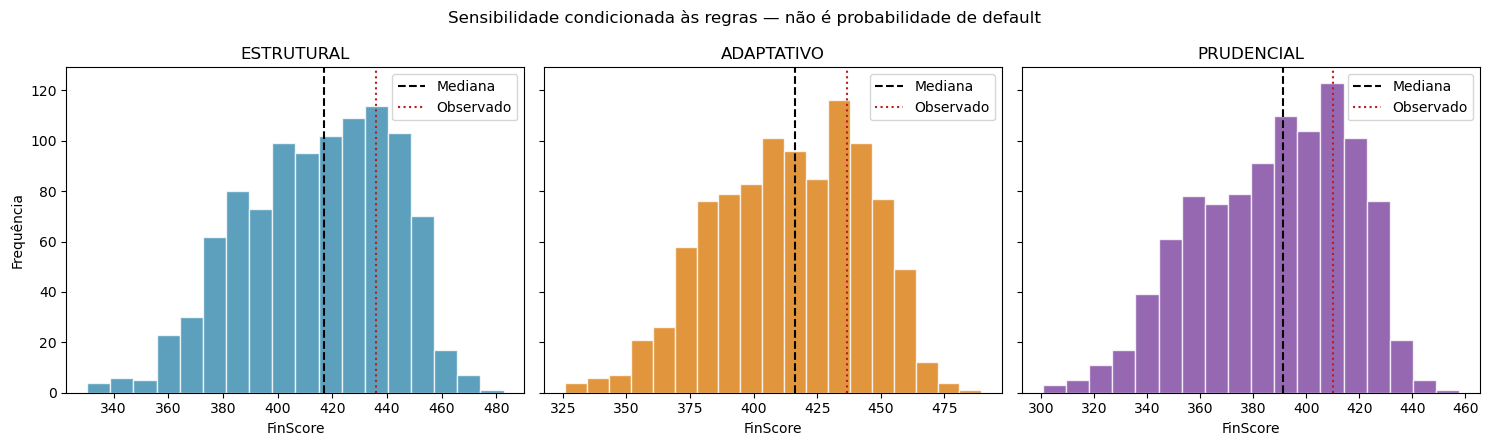

In [48]:
if MODELO_APTO:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    methods = ["estrutural", "adaptativo", "prudencial"]
    colors = ["#2E86AB", "#D97706", "#7A3E9D"]

    for ax, method, color in zip(axes, methods, colors):
        column = f"finscore_{method}"
        ax.hist(
            df_simulacoes[column], bins="fd", color=color,
            alpha=0.78, edgecolor="white"
        )
        ax.axvline(
            df_simulacoes[column].median(), color="black",
            linestyle="--", label="Mediana"
        )
        observed_value = finscore_observado.get(column, np.nan)
        if np.isfinite(observed_value):
            ax.axvline(
                observed_value, color="#B91C1C",
                linestyle=":", label="Observado"
            )
        ax.set_title(method.upper())
        ax.set_xlabel("FinScore")
        ax.legend()

    axes[0].set_ylabel("Frequência")
    fig.suptitle("Sensibilidade condicionada às regras — não é probabilidade de default")
    plt.tight_layout()
    plt.show()

#### 1.8 Evidência externa — Serasa


In [49]:
# Trata o Serasa como evidência externa independente, mede sua divergência em relação ao FinScore e impede uma integração aritmética sem fundamento metodológico.
def assess_external_credit(
    finscore_prudential,
    serasa_score,
    consultation_date=None,
    severe_restriction=False,
) -> pd.DataFrame:
    if serasa_score is None or pd.isna(serasa_score):
        return pd.DataFrame([{
            "serasa_score": np.nan,
            "data_consulta": consultation_date,
            "status": "AUSENTE",
            "divergencia_pontos": np.nan,
            "nivel_divergencia": "não calculado",
            "direcao": "avaliação externa ausente",
            "restricao_grave": bool(severe_restriction),
            "score_integrado": np.nan,
        }])
    if not 0 <= float(serasa_score) <= 1000:
        raise ValueError("SERASA_SCORE deve estar entre 0 e 1.000.")

    if pd.isna(finscore_prudential):
        difference = np.nan
        level = "não calculado"
        direction = "FinScore indisponível"
    else:
        signed = float(serasa_score) - float(finscore_prudential)
        difference = abs(signed)
        if difference <= 100:
            level = "baixa"
        elif difference <= 200:
            level = "moderada"
        elif difference <= 300:
            level = "relevante"
        else:
            level = "elevada"
        direction = (
            "convergente" if difference <= 100
            else "evidência externa mais favorável" if signed > 0
            else "evidência externa mais desfavorável"
        )

    status = "ESCALONAR_RESTRICAO_GRAVE" if severe_restriction else "ANALISAR_CONJUNTAMENTE"
    return pd.DataFrame([{
        "serasa_score": float(serasa_score),
        "data_consulta": consultation_date,
        "status": status,
        "divergencia_pontos": difference,
        "nivel_divergencia": level,
        "direcao": direction,
        "restricao_grave": bool(severe_restriction),
        # Deliberadamente ausente: não há média automática.
        "score_integrado": np.nan,
    }])


df_serasa = assess_external_credit(
    finscore_observado.get("finscore_prudencial", np.nan),
    SERASA_SCORE,
    SERASA_DATA_CONSULTA,
    SERASA_RESTRICAO_GRAVE,
)
display(df_serasa)


,serasa_score,data_consulta,status,divergencia_pontos,nivel_divergencia,direcao,restricao_grave,score_integrado
0,700.0000,2026-07-23,ANALISAR_CONJUNTAMENTE,290.0050,relevante,evidência externa mais favorável,False,NaN


#### 1.9 Autotestes

In [50]:
def synthetic_valid_data() -> pd.DataFrame:
    data = {
        "ano": [2023, 2024, 2025],
        "p_Caixa_Equivalentes": [100, 120, 150],
        "p_Contas_Receber_Clientes": [300, 330, 360],
        "p_Estoques": [200, 210, 220],
        "p_Ativo_Circulante": [700, 760, 830],
        "p_Imobilizado_Liquido": [500, 540, 580],
        "p_Ativo_Total": [1400, 1500, 1600],
        "p_Fornecedores": [150, 160, 170],
        "p_Obrigacoes_Tributarias_CP": [40, 45, 50],
        "p_Obrigacoes_Trabalhistas_CP": [60, 65, 70],
        "p_Passivo_Circulante": [400, 420, 430],
        "p_Passivo_Nao_Circulante": [300, 280, 250],
        "p_Emprestimos_Financiamentos_CP": [100, 90, 80],
        "p_Emprestimos_Financiamentos_LP": [250, 230, 200],
        "p_Patrimonio_Liquido": [700, 800, 920],
        "r_Receita_Liquida": [2000, 2200, 2420],
        "r_CMV_CPV_CSV": [1200, 1300, 1400],
        "r_Resultado_Antes_IR_CSLL": [200, 240, 300],
        "r_Lucro_Liquido": [140, 168, 210],
        "r_Receitas_Financeiras": [10, 10, 12],
        "r_Despesa_IR_CSLL": [60, 72, 90],
        "r_Despesas_Financeiras": [50, 45, 40],
    }
    return pd.DataFrame(data)


def run_self_tests() -> pd.DataFrame:
    tests = []

    def check(name, condition, detail=""):
        tests.append({
            "teste": name,
            "status": "PASSOU" if bool(condition) else "FALHOU",
            "detalhe": detail,
        })

    base = synthetic_valid_data()
    original = base.copy(deep=True)
    empty_report = pd.DataFrame(columns=QUALITY_COLUMNS)
    prepared, quality, audit, status = validate_correct_and_prepare(
        base, empty_report, []
    )

    check("21 contas primárias", len(PRIMARY) == 21)
    check("base sintética aprovada", status["apto_calculo"])
    check("base sintética sem correções", audit.empty)
    check("dados reportados imutáveis", base.equals(original))

    derived = derive(prepared)
    balance_difference = (
        prepared.p_Ativo_Total - prepared.p_Passivo_Circulante
        - prepared.p_Passivo_Nao_Circulante
        - prepared.p_Patrimonio_Liquido
    )
    check("identidade do balanço", np.allclose(balance_difference, 0))

    index_table = indices(derived)
    score_table = score_indices(index_table)
    scores, profiles, temporal, contributions = calculate_scores(
        index_table, score_table
    )
    cap, _ = evaluate_prudential_caps(index_table, prepared)
    scores["finscore_prudencial"] = min(
        scores["finscore_prudencial_pre_cap"], cap
    )
    check(
        "scores limitados a 0-1000",
        all(0 <= scores[k] <= 1000 for k in [
            "finscore_estrutural", "finscore_adaptativo",
            "finscore_prudencial",
        ]),
    )
    check(
        "gargalo reduz ou mantém score",
        scores["finscore_estrutural_pos_gargalo"]
        <= scores["finscore_estrutural"] + 1e-10
        and scores["finscore_adaptativo_pos_gargalo"]
        <= scores["finscore_adaptativo"] + 1e-10,
    )
    check(
        "pesos PCA válidos",
        all(
            np.isclose(profile.weights.sum(), 1.0)
            and (profile.weights >= 0).all()
            for profile in profiles.values()
        ),
    )
    check(
        "participação PCA limitada a 15%",
        all(
            profile.diagnostics["participacao_adaptativa"]
            in {0.0, PCA_ADAPTIVE_SHARE}
            for profile in profiles.values()
        ),
    )

    # Invariância à unidade monetária.
    scaled = base.copy()
    scaled[PRIMARY] = scaled[PRIMARY] * 1000
    scaled_scores, _ = score_prepared_base(scaled)
    check(
        "invariância à unidade monetária",
        np.isclose(
            scores["finscore_prudencial"],
            scaled_scores["finscore_prudencial"],
            atol=1e-8,
        ),
    )

    # Monotonicidade de todas as curvas conforme sua direção econômica.
    monotonic = True
    for indicator, points in ANCHORS.items():
        notes = np.array([p[1] for p in points], dtype=float)
        direction = INDICATOR_DIRECTION.get(indicator, 1)
        monotonic &= (
            np.all(np.diff(notes) >= -1e-12)
            if direction > 0
            else np.all(np.diff(notes) <= 1e-12)
        )
    check("curvas monotônicas", monotonic)

    # Dívida maior não pode melhorar o resultado, mantido o restante.
    debt_stress = base.copy()
    increment = 100.0
    debt_stress["p_Emprestimos_Financiamentos_CP"] += increment
    debt_stress["p_Passivo_Circulante"] += increment
    debt_stress["p_Ativo_Total"] += increment
    debt_scores, _ = score_prepared_base(debt_stress, profiles)
    check(
        "aumento de dívida não melhora score",
        debt_scores["finscore_prudencial"]
        <= scores["finscore_prudencial"] + 1e-10,
    )

    # Caixa adicional financiado por PL não deve piorar liquidez/capitalização.
    cash_gain = base.copy()
    cash_gain["p_Caixa_Equivalentes"] += increment
    cash_gain["p_Ativo_Circulante"] += increment
    cash_gain["p_Ativo_Total"] += increment
    cash_gain["p_Patrimonio_Liquido"] += increment
    cash_scores, _ = score_prepared_base(cash_gain, profiles)
    check(
        "aumento de caixa com capital não piora score",
        cash_scores["finscore_prudencial"]
        >= scores["finscore_prudencial"] - 1e-10,
    )

    # Um núcleo crítico não pode ser integralmente compensado.
    check(
        "núcleo crítico não é integralmente compensado",
        _geometric_nucleus_score(950, 200)
        < NUCLEUS_WEIGHTS["EO"] * 950 + NUCLEUS_WEIGHTS["FP"] * 200,
    )

    result_a, diagnostics_a = run_sensitivity(
        prepared, 120, 12345, profiles
    )
    result_b, diagnostics_b = run_sensitivity(
        prepared, 120, 12345, profiles
    )
    score_columns = [
        "finscore_estrutural", "finscore_adaptativo",
        "finscore_prudencial",
    ]
    check(
        "reprodutibilidade por semente",
        np.allclose(result_a[score_columns], result_b[score_columns]),
    )
    check(
        "simulações dentro da escala",
        result_a[score_columns].ge(0).all().all()
        and result_a[score_columns].le(1000).all().all(),
    )
    check(
        "drivers respeitam amplitudes declaradas",
        diagnostics_a["drivers_fora_limite"] == 0,
    )
    check(
        "PL não é residual do balanço",
        diagnostics_a["limites_choques"].loc[
            diagnostics_a["limites_choques"]["conta"].eq(
                "p_Patrimonio_Liquido"
            ),
            "natureza_simulacao",
        ].eq("DRIVER_SORTEADO").all(),
    )
    deterministic = run_deterministic_scenarios(prepared, profiles)
    check(
        "cenários determinísticos contabilmente válidos",
        deterministic["status"].eq("VALIDO").all(),
    )

    corrupted = base.copy()
    corrupted.loc[2, "p_Passivo_Circulante"] = 100
    _, corrupt_quality, corrupt_audit, corrupt_status = (
        validate_correct_and_prepare(corrupted, empty_report, [])
    )
    check(
        "subtotal inconsistente é colocado em quarentena",
        corrupt_quality["tipo"].eq(
            "subtotal_inferior_componentes"
        ).any()
        and corrupt_audit["acao"].eq(
            "QUARENTENA_DETALHAMENTO"
        ).any(),
    )

    serasa_test = assess_external_credit(
        scores["finscore_prudencial"], 500
    )
    check(
        "Serasa não gera média automática",
        pd.isna(serasa_test.loc[0, "score_integrado"]),
    )

    known_problem = base.copy()
    known_problem.loc[0, "p_Passivo_Nao_Circulante"] = 100
    known_problem.loc[0, "p_Ativo_Total"] = (
        known_problem.loc[0, "p_Passivo_Circulante"]
        + known_problem.loc[0, "p_Patrimonio_Liquido"]
    )
    known_problem.loc[0, "p_Ativo_Circulante"] = 600
    known_problem.loc[2, "p_Passivo_Nao_Circulante"] = np.nan
    known_problem.loc[2, "p_Passivo_Circulante"] = 430
    known_problem.loc[2, "p_Obrigacoes_Tributarias_CP"] = 300
    known_problem.loc[2, "p_Obrigacoes_Trabalhistas_CP"] = 250
    corrected, known_quality, known_audit, known_status = (
        validate_correct_and_prepare(known_problem, empty_report, [])
    )
    check(
        "correção automática não altera origem",
        known_problem.loc[0, "p_Passivo_Nao_Circulante"] == 100,
    )
    check(
        "rubrica redundante corrigida apenas na análise",
        np.isclose(
            corrected.loc[0, "p_Passivo_Nao_Circulante"], 0
        ),
    )
    check(
        "parcela ausente inferida e auditada",
        pd.notna(corrected.loc[2, "p_Passivo_Nao_Circulante"])
        and known_audit["acao"].eq("INFERENCIA_IDENTIDADE").any(),
    )
    check(
        "score com correção material é provisório",
        known_status["apto_calculo"]
        and known_status["score_provisorio"]
        and not known_status["apto_decisao"],
    )

    return pd.DataFrame(tests)


df_autotestes = (
    run_self_tests() if EXECUTAR_AUTOTESTES else pd.DataFrame()
)
if EXECUTAR_AUTOTESTES:
    display(df_autotestes)
    if not df_autotestes["status"].eq("PASSOU").all():
        raise AssertionError(
            "Há autoteste(s) com falha; revise antes de usar o modelo."
        )

,teste,status,detalhe
0,21 contas primárias,PASSOU,
1,base sintética aprovada,PASSOU,
2,base sintética sem correções,PASSOU,
3,dados reportados imutáveis,PASSOU,
4,identidade do balanço,PASSOU,
5,scores limitados a 0-1000,PASSOU,
6,gargalo reduz ou mantém score,PASSOU,
7,pesos PCA válidos,PASSOU,
8,participação PCA limitada a 15%,PASSOU,
9,invariância à unidade monetária,PASSOU,


#### 1.10 Exportação auditável

In [51]:
from openpyxl.comments import Comment
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter


PARAMETROS_REGRAS = {
    "versao": VERSAO_MODELO,
    "hash_codigo": HASH_CODIGO_MODELO,
    "politica_correcao": POLITICA_CORRECAO,
    "limiar_confianca_automatica": LIMIAR_CONFIANCA_AUTOMATICA,
    "limiar_materialidade": LIMIAR_MATERIALIDADE,
    "limiar_vies_alto": LIMIAR_VIES_ALTO,
    "tolerancia_balanco": BALANCE_TOLERANCE,
    "cobertura_minima_nucleo": MIN_NUCLEUS_COVERAGE,
    "participacao_pca": PCA_ADAPTIVE_SHARE,
    "repeticoes_estabilidade_pca": PCA_STABILITY_REPETITIONS,
    "limiar_l1_pca": PCA_MAX_MEAN_L1_DISTANCE,
    "limiar_cosseno_pca": PCA_MIN_MEAN_COSINE,
    "pesos_nucleos": NUCLEUS_WEIGHTS,
    "peso_gargalo": BOTTLENECK_SHARE,
    "pesos_temporais": TEMPORAL_COMPONENT_WEIGHTS,
    "caps_prudenciais": PRUDENTIAL_CAPS,
    "ancoras": ANCHORS,
    "pesos_fixos": FIXED_WEIGHTS,
}
HASH_REGRAS = hashlib.sha256(
    json.dumps(PARAMETROS_REGRAS, sort_keys=True).encode("utf-8")
).hexdigest()

configuration_rows = [
    ("versao", VERSAO_MODELO),
    ("hash_codigo_modelo", HASH_CODIGO_MODELO),
    ("planilha", str(CAMINHO_PLANILHA)),
    ("aba", ABA_DADOS),
    ("simulacoes", NUM_SIMULACOES),
    ("semente", SEMENTE),
    (
        "data_hora_processamento",
        DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
    ),
    ("politica_correcao", POLITICA_CORRECAO),
    ("aplicar_correcoes_automaticas", APLICAR_CORRECOES_AUTOMATICAS),
    ("limiar_confianca_automatica", LIMIAR_CONFIANCA_AUTOMATICA),
    ("limiar_materialidade", LIMIAR_MATERIALIDADE),
    ("limiar_vies_alto", LIMIAR_VIES_ALTO),
    ("delta_min", DELTA_MIN),
    ("delta_max", DELTA_MAX),
    ("peso_EO", NUCLEUS_WEIGHTS["EO"]),
    ("peso_FP", NUCLEUS_WEIGHTS["FP"]),
    ("peso_gargalo", BOTTLENECK_SHARE),
    ("participacao_pca", PCA_ADAPTIVE_SHARE),
    ("pca_variaveis_minimas", PCA_MIN_ACTIVE_VARIABLES),
    ("pca_repeticoes_estabilidade", PCA_STABILITY_REPETITIONS),
    ("pca_l1_maximo", PCA_MAX_MEAN_L1_DISTANCE),
    ("pca_cosseno_minimo", PCA_MIN_MEAN_COSINE),
    ("peso_temporal_nivel", TEMPORAL_COMPONENT_WEIGHTS["nivel_atual"]),
    ("peso_temporal_trajetoria", TEMPORAL_COMPONENT_WEIGHTS["trajetoria"]),
    ("peso_temporal_resiliencia", TEMPORAL_COMPONENT_WEIGHTS["resiliencia"]),
    ("cobertura_minima_nucleo", MIN_NUCLEUS_COVERAGE),
    ("proxy_juros", USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS),
    ("status_base", status_qualidade["status"]),
    ("classificacao_uso", status_qualidade["classificacao_uso"]),
    ("indice_confiabilidade", q_observado),
    ("hash_dados_reportados", HASH_DADOS_REPORTADOS),
    ("hash_dados_utilizados", HASH_DADOS_UTILIZADOS),
    ("hash_regras", HASH_REGRAS),
]
df_configuracao = pd.DataFrame(
    configuration_rows, columns=["parametro", "valor"]
)

df_resumo_modelo = pd.DataFrame({
    "campo": [
        "Versão",
        "Status do cálculo",
        "Classificação de uso",
        "Apto para decisão",
        "Natureza do score",
        "Índice de confiabilidade",
        "Classificação da confiabilidade",
        "Correções/quarentenas aplicadas",
        "Pendências de confirmação",
        "Alertas de viés alto/crítico",
        "Score EO estrutural",
        "Score FP estrutural",
        "FinScore estrutural geométrico",
        "FinScore adaptativo geométrico",
        "FinScore prudencial antes do cap",
        "Cap prudencial aplicável",
        "FinScore prudencial final",
        "Faixa de incerteza inferior",
        "Faixa de incerteza superior",
        "Hash da base reportada",
        "Hash da base utilizada",
        "Hash das regras",
        "Hash do código",
    ],
    "valor": [
        VERSAO_MODELO,
        status_qualidade["status"],
        status_qualidade["classificacao_uso"],
        "SIM" if status_qualidade["apto_decisao"] else "NÃO",
        finscore_observado.get("natureza_resultado", "NÃO CALCULADO"),
        q_observado,
        confiabilidade_observada["classificacao_confiabilidade"],
        status_qualidade["correcoes_aplicadas"],
        status_qualidade["correcoes_pendentes_confirmacao"],
        status_qualidade.get("alertas_vies_alto_critico", 0),
        finscore_observado.get("nucleo_EO_estrutural", np.nan),
        finscore_observado.get("nucleo_FP_estrutural", np.nan),
        finscore_observado.get("finscore_estrutural", np.nan),
        finscore_observado.get("finscore_adaptativo", np.nan),
        finscore_observado.get("finscore_prudencial_pre_cap", np.nan),
        finscore_observado.get("cap_prudencial_aplicavel", np.nan),
        finscore_observado.get("finscore_prudencial", np.nan),
        finscore_observado.get("faixa_incerteza_inferior", np.nan),
        finscore_observado.get("faixa_incerteza_superior", np.nan),
        HASH_DADOS_REPORTADOS,
        HASH_DADOS_UTILIZADOS,
        HASH_REGRAS,
        HASH_CODIGO_MODELO,
    ],
})


def _style_workbook(workbook):
    '''Formatação operacional sem esconder a trilha de auditoria.'''
    navy = "17365D"
    red = "F4CCCC"
    amber = "FCE5CD"
    green = "D9EAD3"
    blue = "D9EAF7"

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.sheet_view.showGridLines = False
        worksheet.auto_filter.ref = worksheet.dimensions
        for cell in worksheet[1]:
            cell.fill = PatternFill("solid", fgColor=navy)
            cell.font = Font(color="FFFFFF", bold=True)
            cell.alignment = Alignment(
                horizontal="center", vertical="center", wrap_text=True
            )
        worksheet.row_dimensions[1].height = 34

        for column_cells in worksheet.columns:
            letter = get_column_letter(column_cells[0].column)
            max_length = 0
            for cell in column_cells[:200]:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
                cell.alignment = Alignment(vertical="top", wrap_text=True)
            worksheet.column_dimensions[letter].width = min(
                max(max_length + 2, 11), 55
            )

        headers = {
            cell.value: cell.column
            for cell in worksheet[1]
            if cell.value is not None
        }
        for label in [
            "severidade", "potencial_vies", "risco_vies", "status",
            "status_acao", "classificacao_uso",
        ]:
            if label not in headers:
                continue
            column = headers[label]
            for row in range(2, worksheet.max_row + 1):
                cell = worksheet.cell(row, column)
                text = str(cell.value).upper()
                if "CRIT" in text or "BLOQUE" in text or "NAO APTA" in text:
                    cell.fill = PatternFill("solid", fgColor=red)
                elif "ALTO" in text or "PROVIS" in text or "PEND" in text:
                    cell.fill = PatternFill("solid", fgColor=amber)
                elif "PASS" in text or "DECISORIO" in text or "CONTROLADO" in text:
                    cell.fill = PatternFill("solid", fgColor=green)
                elif "QUARENTENA" in text or "INFO" in text:
                    cell.fill = PatternFill("solid", fgColor=blue)

        for header, column in headers.items():
            header_text = str(header).lower()
            if any(token in header_text for token in [
                "valor_", "delta_absoluto", "score", "observado",
                "media", "mediana", "minimo", "maximo", "cap",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = (
                        '#,##0.00;[Red](#,##0.00);-'
                    )
            if any(token in header_text for token in [
                "percentual", "materialidade", "confianca",
                "correlacao", "variancia", "participacao", "peso",
                "freq_", "impacto_absoluto", "cobertura",
                "amplitude", "choque",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = "0.00%"

        if worksheet.title == "indices_observados":
            percentage_indicators = {
                "crescimento_receita", "margem_bruta", "margem_ebit",
                "margem_liquida", "capitalizacao",
                "endividamento_exigivel", "ccl_ativo",
                "divida_liquida_ativo", "composicao_endividamento",
            }
            multiple_indicators = {
                "giro_ativo", "liquidez_corrente", "liquidez_seca",
                "cobertura_juros",
            }
            for header, column in headers.items():
                if header in percentage_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00%"
                elif header in multiple_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00x"

        narrative_heights = {
            "correcoes_auditoria": 72,
            "alertas_vies_material": 72,
            "qualidade_dados": 48,
            "motivos_nan": 48,
            "caps_prudenciais": 48,
            "intervalos_incerteza": 48,
        }
        if worksheet.title in narrative_heights:
            for row in range(2, worksheet.max_row + 1):
                worksheet.row_dimensions[row].height = (
                    narrative_heights[worksheet.title]
                )

    if "correcoes_auditoria" in workbook.sheetnames:
        ws = workbook["correcoes_auditoria"]
        comments = {
            "valor_original": "Valor lido da planilha-fonte, nunca sobrescrito.",
            "valor_utilizado": "Valor empregado somente na cópia analítica.",
            "confianca": (
                "Confiança da regra; não equivale a probabilidade estatística."
            ),
            "materialidade_pct_ativo": (
                "Magnitude da mudança dividida pelo Ativo Total do exercício."
            ),
            "confirmado": (
                "Verdadeiro somente após verificação documental."
            ),
        }
        for cell in ws[1]:
            if cell.value in comments:
                cell.comment = Comment(comments[cell.value], "FinScore")

    if "resumo_modelo" in workbook.sheetnames:
        ws = workbook["resumo_modelo"]
        for row in range(2, ws.max_row + 1):
            field = str(ws.cell(row, 1).value)
            if any(token in field for token in [
                "Status", "Natureza", "Apto", "Classificação de uso",
            ]):
                ws.cell(row, 2).font = Font(bold=True)
                text = str(ws.cell(row, 2).value).upper()
                fill = (
                    red if "NÃO" in text or "NAO" in text or "BLOQUE" in text
                    else amber if "PROVIS" in text or "EXPLOR" in text
                    else green
                )
                ws.cell(row, 2).fill = PatternFill("solid", fgColor=fill)


def export_audit_workbook(path: Path):
    sheets = {
        "resumo_modelo": df_resumo_modelo,
        "confiabilidade": df_confiabilidade_componentes,
        "correcoes_auditoria": df_correcoes_auditoria,
        "alertas_vies_material": df_alertas_vies,
        "qualidade_dados": df_qualidade,
        "rastreabilidade_contas": df_rastreabilidade_contas,
        "contas_reportadas": df_contas_reportadas,
        "contas_utilizadas": df_contas_analise,
        "evidencia_serasa": df_serasa,
        "autotestes": df_autotestes,
        "configuracao": df_configuracao,
    }
    if MODELO_APTO:
        sheets.update({
            "score_observado": pd.DataFrame([finscore_observado]),
            "score_temporal": df_score_temporal,
            "contribuicoes_score": df_contribuicoes_score,
            "caps_prudenciais": df_caps_prudenciais,
            "intervalos_incerteza": df_intervalos_incerteza,
            "contas_derivadas": df_contas_derivadas,
            "indices_observados": df_indices_observados,
            "notas_observadas": df_notas_observadas,
            "motivos_nan": df_motivos_nan,
            "diagnostico_pca": df_diagnostico_pca,
            "pesos_pca": df_pesos_pca,
            "cargas_pca": df_cargas_pca,
            "cenarios_deterministicos": df_cenarios_deterministicos,
            "resumo_simulacao": df_resumo,
            "simulacoes": df_simulacoes,
            "sensibilidade": df_sensibilidade,
            "amplitudes": df_amplitudes,
        })

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, table in sheets.items():
            table.to_excel(
                writer, sheet_name=sheet_name[:31], index=False
            )
        _style_workbook(writer.book)


if EXPORTAR_EXCEL:
    export_audit_workbook(ARQUIVO_SAIDA)
    print(f"Resultados salvos em: {ARQUIVO_SAIDA.resolve()}")
else:
    print("Exportação Excel desativada.")

Exportação Excel desativada.


***

## 2. RESULTADOS

In [52]:
# Leia a saída nesta ordem:

# 1. classificação de uso e confiabilidade — determinam se o resultado pode apoiar decisão;
# 2. Score EO e FP — mostram qual dimensão limita a capacidade econômica;
# 3. FinScore geométrico, gargalo e cap — explicam a passagem ao resultado prudencial;
# 4. faixa de incerteza — mostra o efeito parcial de dívida onerosa não classificada;
# 5. nível, trajetória e resiliência — mostram por que cada indicador contribuiu;
# 6. PCA — informa o que mais variou, desde que o teste de estabilidade permita ajuste;
# 7. cenários determinísticos e Monte Carlo — avaliam sensibilidade às regras adotadas.

# ### Limites que permanecem

# - três exercícios não permitem inferência estatística robusta nem estimação de PD;
# - pesos, curvas e caps ainda são normativos e precisam de validação transversal;
# - a faixa de incerteza cobre a classificação desconhecida da dívida, não todas as omissões;
# - Monte Carlo representa sensibilidade condicionada, não previsão econômica;
# - Serasa continua sendo evidência comportamental separada;
# - julgamento de crédito, documentos assinados, notas explicativas e contexto setorial continuam indispensáveis.

In [53]:
# =============================================================================
# SAÍDA FINAL AMPLIADA AO PARECERISTA
# =============================================================================
# Esta célula apenas resume resultados já produzidos pelo modelo.
#
# NÃO altera:
# - dados contábeis;
# - validações;
# - parâmetros;
# - PCA;
# - simulações;
# - regras prudenciais;
# - scores;
# - arquivos exportados.
# =============================================================================


def _formatar_numero_resumo(valor, casas=2):
    """Formata valores sem interferir nos cálculos."""
    try:
        numero = float(valor)
    except (TypeError, ValueError):
        return "não disponível"

    if not np.isfinite(numero):
        return "não disponível"

    return (
        f"{numero:,.{casas}f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


def _formatar_percentual_resumo(valor, casas=1, proporcao=True):
    """Formata proporções ou percentuais."""
    try:
        numero = float(valor)
    except (TypeError, ValueError):
        return "não disponível"

    if not np.isfinite(numero):
        return "não disponível"

    if proporcao:
        numero *= 100

    return f"{_formatar_numero_resumo(numero, casas)}%"


def _obter_valor(objeto, chave, padrao=np.nan):
    """
    Obtém uma chave de dict, Series ou objeto semelhante,
    sem interromper a saída se a chave não existir.
    """
    if objeto is None:
        return padrao

    try:
        if hasattr(objeto, "get"):
            return objeto.get(chave, padrao)
    except Exception:
        pass

    return padrao


def _serie_numerica(df, coluna):
    """Converte uma coluna em série numérica finita."""
    if (
        not isinstance(df, pd.DataFrame)
        or df.empty
        or coluna not in df.columns
    ):
        return pd.Series(dtype=float)

    return (
        pd.to_numeric(df[coluna], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )


def _buscar_coluna(df, candidatos):
    """Localiza a primeira coluna disponível entre nomes candidatos."""
    if not isinstance(df, pd.DataFrame):
        return None

    mapa = {str(coluna).lower(): coluna for coluna in df.columns}

    for candidato in candidatos:
        if candidato.lower() in mapa:
            return mapa[candidato.lower()]

    return None


def _resumir_motivos_bloqueio(limite=5):
    """Consolida bloqueios já identificados pela validação."""
    motivos = []

    df = globals().get("df_qualidade")

    if isinstance(df, pd.DataFrame) and not df.empty:
        if "bloqueia_calculo" in df.columns:
            bloqueios = df.loc[
                df["bloqueia_calculo"].fillna(False).astype(bool)
            ].copy()
        else:
            bloqueios = pd.DataFrame()

        colunas_duplicidade = [
            coluna
            for coluna in ["tipo", "conta", "exercicios", "detalhe"]
            if coluna in bloqueios.columns
        ]

        if colunas_duplicidade:
            bloqueios_unicos = bloqueios.drop_duplicates(
                subset=colunas_duplicidade
            )
        else:
            bloqueios_unicos = bloqueios

        for _, ocorrencia in bloqueios_unicos.head(limite).iterrows():
            conta = str(ocorrencia.get("conta", "")).strip()
            exercicios = str(
                ocorrencia.get("exercicios", "")
            ).strip()
            detalhe = str(ocorrencia.get("detalhe", "")).strip()

            referencia = " / ".join(
                parte
                for parte in [
                    conta,
                    f"exercício {exercicios}" if exercicios else "",
                ]
                if parte
            )

            texto = (
                f"{referencia}: {detalhe}"
                if referencia and detalhe
                else referencia or detalhe
            )

            if texto:
                motivos.append(texto)

        excedentes = max(len(bloqueios_unicos) - len(motivos), 0)

        if excedentes:
            motivos.append(
                f"mais {excedentes} ocorrência(s) bloqueadora(s) "
                "detalhada(s) na planilha"
            )

    if not motivos:
        motivos.append(
            "a base não atendeu aos critérios impeditivos de "
            "qualidade definidos pelo modelo"
        )

    return motivos


def _resumo_monte_carlo():
    """
    Resume a distribuição Monte Carlo do FinScore prudencial.
    Retorna None caso as simulações não estejam disponíveis.
    """
    df = globals().get("df_simulacoes")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna = _buscar_coluna(
        df,
        [
            "finscore_prudencial",
            "FinScore_prudencial",
            "finscore_final",
            "FinScore",
        ],
    )

    if coluna is None:
        return None

    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    media = serie.mean()
    desvio = serie.std(ddof=1)

    # A trava de 500 é identificada pela concentração exatamente nesse valor.
    # Não se presume que todo valor 500 decorra necessariamente da mesma regra.
    quantidade_500 = int(np.isclose(serie.to_numpy(), 500.0).sum())
    proporcao_500 = quantidade_500 / len(serie)

    erro_padrao = (
        desvio / np.sqrt(len(serie))
        if len(serie) > 1 and np.isfinite(desvio)
        else np.nan
    )

    return {
        "coluna": coluna,
        "simulacoes": int(len(serie)),
        "media": media,
        "mediana": serie.median(),
        "desvio_padrao": desvio,
        "erro_padrao_media": erro_padrao,
        "p01": serie.quantile(0.01),
        "p05": serie.quantile(0.05),
        "p10": serie.quantile(0.10),
        "p90": serie.quantile(0.90),
        "p95": serie.quantile(0.95),
        "p99": serie.quantile(0.99),
        "minimo": serie.min(),
        "maximo": serie.max(),
        "amplitude": serie.max() - serie.min(),
        "valores_unicos": int(serie.nunique()),
        "quantidade_500": quantidade_500,
        "proporcao_500": proporcao_500,
    }


def _resumo_convergencia_mc(coluna="finscore_prudencial"):
    """
    Compara estatísticas acumuladas da simulação.
    Isso não substitui uma execução independente com sementes diferentes.
    """
    df = globals().get("df_simulacoes")

    if (
        not isinstance(df, pd.DataFrame)
        or df.empty
        or coluna not in df.columns
    ):
        return None

    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    candidatos = [25, 50, 100, 250, 500, 1000, 3000, 5000, 10000]
    tamanhos = [n for n in candidatos if n <= len(serie)]

    if len(serie) not in tamanhos:
        tamanhos.append(len(serie))

    registros = []

    for n in sorted(set(tamanhos)):
        amostra = serie.iloc[:n]

        registros.append(
            {
                "simulacoes": n,
                "media": amostra.mean(),
                "mediana": amostra.median(),
                "p05": amostra.quantile(0.05),
                "p95": amostra.quantile(0.95),
                "desvio_padrao": amostra.std(ddof=1),
                "proporcao_500": np.isclose(
                    amostra.to_numpy(), 500.0
                ).mean(),
            }
        )

    return pd.DataFrame(registros)


def _resumo_pca_por_nucleo():
    """
    Extrai informações do diagnóstico do PCA sem pressupor uma estrutura
    rígida de colunas.
    """
    df = globals().get("df_diagnostico_pca")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna_nucleo = _buscar_coluna(
        df,
        ["nucleo", "núcleo", "grupo", "bloco"],
    )

    coluna_componentes = _buscar_coluna(
        df,
        [
            "n_componentes",
            "componentes_retidos",
            "componentes",
            "n_components",
        ],
    )

    coluna_variancia = _buscar_coluna(
        df,
        [
            "variancia_explicada",
            "variancia_explicada_acumulada",
            "variancia_acumulada",
            "explained_variance",
            "explained_variance_ratio",
        ],
    )

    coluna_condicao = _buscar_coluna(
        df,
        [
            "numero_condicao",
            "número_condição",
            "condition_number",
            "condicao",
        ],
    )

    coluna_status = _buscar_coluna(
        df,
        [
            "status",
            "diagnostico",
            "diagnóstico",
            "classificacao",
            "classificação",
        ],
    )

    colunas = [
        coluna
        for coluna in [
            coluna_nucleo,
            coluna_componentes,
            coluna_variancia,
            coluna_condicao,
            coluna_status,
        ]
        if coluna is not None
    ]

    if not colunas:
        return df.copy()

    return df[colunas].copy()


def _principais_cargas_pca(limite=5):
    """
    Identifica os índices com maiores cargas absolutas no PCA.
    A carga absoluta representa influência, não direção econômica.
    """
    df = globals().get("df_cargas_pca")

    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    coluna_indice = _buscar_coluna(
        df,
        [
            "indice",
            "índice",
            "variavel",
            "variável",
            "indicador",
            "conta",
        ],
    )

    coluna_nucleo = _buscar_coluna(
        df,
        ["nucleo", "núcleo", "grupo", "bloco"],
    )

    colunas_carga = [
        coluna
        for coluna in df.columns
        if (
            str(coluna).lower().startswith("pc")
            or "carga" in str(coluna).lower()
            or "loading" in str(coluna).lower()
        )
        and pd.to_numeric(df[coluna], errors="coerce").notna().any()
    ]

    if not colunas_carga:
        return None

    registros = []

    for coluna_carga in colunas_carga:
        carga = pd.to_numeric(df[coluna_carga], errors="coerce")

        tabela = pd.DataFrame(
            {
                "nucleo": (
                    df[coluna_nucleo].astype(str)
                    if coluna_nucleo is not None
                    else ""
                ),
                "indice": (
                    df[coluna_indice].astype(str)
                    if coluna_indice is not None
                    else df.index.astype(str)
                ),
                "componente": str(coluna_carga),
                "carga": carga,
                "carga_absoluta": carga.abs(),
            }
        ).dropna(subset=["carga"])

        registros.append(
            tabela.sort_values(
                "carga_absoluta",
                ascending=False,
            ).head(limite)
        )

    if not registros:
        return None

    return pd.concat(registros, ignore_index=True)


def _comparar_observado_simulado(
    score_observado,
    resumo_mc,
):
    """Compara o FinScore pontual à distribuição simulada."""
    if resumo_mc is None:
        return None

    try:
        observado = float(score_observado)
    except (TypeError, ValueError):
        return None

    if not np.isfinite(observado):
        return None

    df = globals().get("df_simulacoes")
    coluna = resumo_mc["coluna"]
    serie = _serie_numerica(df, coluna)

    if serie.empty:
        return None

    percentil_empirico = (
        (serie <= observado).sum() / len(serie)
    )

    return {
        "observado": observado,
        "media_simulada": resumo_mc["media"],
        "mediana_simulada": resumo_mc["mediana"],
        "diferenca_media": observado - resumo_mc["media"],
        "diferenca_mediana": observado - resumo_mc["mediana"],
        "percentil_empirico": percentil_empirico,
    }


def _imprimir_tabela_texto(
    df,
    colunas=None,
    limite=10,
    casas=3,
):
    """Imprime DataFrame de forma compacta para a saída textual."""
    if not isinstance(df, pd.DataFrame) or df.empty:
        print("• informação não disponível")
        return

    tabela = df.copy()

    if colunas:
        colunas_existentes = [
            coluna for coluna in colunas if coluna in tabela.columns
        ]
        if colunas_existentes:
            tabela = tabela[colunas_existentes]

    tabela = tabela.head(limite)

    for coluna in tabela.columns:
        if pd.api.types.is_numeric_dtype(tabela[coluna]):
            tabela[coluna] = tabela[coluna].round(casas)

    print(
        tabela.to_string(
            index=False,
            max_cols=12,
            max_colwidth=35,
        )
    )


# =============================================================================
# EXECUÇÃO DA SAÍDA
# =============================================================================

modelo_apto = bool(globals().get("MODELO_APTO", False))
exportar_excel = bool(globals().get("EXPORTAR_EXCEL", False))
arquivo_saida = globals().get("ARQUIVO_SAIDA")

status = globals().get("status_qualidade", {})
finscore = globals().get("finscore_observado", {})
confiabilidade = globals().get("confiabilidade_observada", {})

q_atual = globals().get("q_observado", np.nan)

linha = "=" * 88


if not modelo_apto:
    motivos_bloqueio = _resumir_motivos_bloqueio()

    pontos_observacao = [
        "conferir as contas e os exercícios citados nos demonstrativos originais",
        "reconciliar Balanço Patrimonial, subtotais e componentes",
        "validar pendências de confirmação e rubricas colocadas em quarentena",
        "consultar as abas 'qualidade_dados', 'correcoes_auditoria' e "
        "'alertas_vies_material' da planilha exportada",
    ]

    print("\n" + linha)
    print("AVISO FINAL — FINSCORE NÃO CALCULADO")

    print("\nMotivos simplificados:")
    for motivo in motivos_bloqueio:
        print(f"• {motivo}")

    print("\nO que o parecerista deve observar:")
    for ponto in pontos_observacao:
        print(f"• {ponto}")

    if exportar_excel and arquivo_saida is not None:
        try:
            print(
                "\nInformações completas: "
                f"{arquivo_saida.resolve()}"
            )
        except Exception:
            print(f"\nInformações completas: {arquivo_saida}")

    print(linha)


else:
    score_prudencial_observado = _obter_valor(
        finscore,
        "finscore_prudencial",
    )

    score_estrutural = _obter_valor(
        finscore,
        "finscore_estrutural",
    )

    score_estrutural_pos_gargalo = _obter_valor(
        finscore,
        "finscore_estrutural_pos_gargalo",
    )

    score_adaptativo = _obter_valor(
        finscore,
        "finscore_adaptativo",
    )

    score_adaptativo_pos_gargalo = _obter_valor(
        finscore,
        "finscore_adaptativo_pos_gargalo",
    )

    score_prudencial_pre_cap = _obter_valor(
        finscore,
        "finscore_prudencial_pre_cap",
    )

    nucleo_eo = _obter_valor(
        finscore,
        "nucleo_EO_estrutural",
    )

    nucleo_fp = _obter_valor(
        finscore,
        "nucleo_FP_estrutural",
    )

    resumo_mc = _resumo_monte_carlo()

    comparacao_mc = _comparar_observado_simulado(
        score_prudencial_observado,
        resumo_mc,
    )

    resumo_pca = _resumo_pca_por_nucleo()
    cargas_pca = _principais_cargas_pca(limite=5)

    print("\n" + linha)
    print("RESUMO FINAL — FINSCORE CALCULADO")

    # -------------------------------------------------------------------------
    # 1. RESULTADO PRINCIPAL
    # -------------------------------------------------------------------------

    print("\n1. RESULTADO PRINCIPAL")

    print(
        "Classificação de uso: "
        f"{_obter_valor(status, 'classificacao_uso', 'não disponível')}"
    )

    print(
        "FinScore prudencial observado: "
        f"{_formatar_numero_resumo(score_prudencial_observado)}"
    )

    print(
        "Núcleo econômico-operacional (EO): "
        f"{_formatar_numero_resumo(nucleo_eo)}"
    )

    print(
        "Núcleo financeiro-patrimonial (FP): "
        f"{_formatar_numero_resumo(nucleo_fp)}"
    )

    print(
        "Índice de confiabilidade: "
        f"{_formatar_numero_resumo(q_atual, 3)} "
        f"({_obter_valor(confiabilidade, 'classificacao_confiabilidade', 'não disponível')})"
    )

    limite_inferior = _obter_valor(
        finscore,
        "faixa_incerteza_inferior",
    )

    limite_superior = _obter_valor(
        finscore,
        "faixa_incerteza_superior",
    )

    try:
        faixa_valida = (
            np.isfinite(float(limite_inferior))
            and np.isfinite(float(limite_superior))
            and not np.isclose(
                float(limite_inferior),
                float(limite_superior),
            )
        )
    except (TypeError, ValueError):
        faixa_valida = False

    if faixa_valida:
        print(
            "Faixa parcial de incerteza: "
            f"{_formatar_numero_resumo(limite_inferior)} a "
            f"{_formatar_numero_resumo(limite_superior)}"
        )

    # -------------------------------------------------------------------------
    # 2. DECOMPOSIÇÃO DO SCORE
    # -------------------------------------------------------------------------

    print("\n2. DECOMPOSIÇÃO DO FINSCORE")

    componentes_score = [
        ("Estrutural", score_estrutural),
        (
            "Estrutural após gargalo",
            score_estrutural_pos_gargalo,
        ),
        ("Adaptativo/PCA", score_adaptativo),
        (
            "Adaptativo/PCA após gargalo",
            score_adaptativo_pos_gargalo,
        ),
        (
            "Prudencial antes da trava",
            score_prudencial_pre_cap,
        ),
        (
            "Prudencial final",
            score_prudencial_observado,
        ),
    ]

    encontrou_componente = False

    for nome, valor in componentes_score:
        try:
            valor_valido = np.isfinite(float(valor))
        except (TypeError, ValueError):
            valor_valido = False

        if valor_valido:
            encontrou_componente = True
            print(
                f"• {nome}: "
                f"{_formatar_numero_resumo(valor)}"
            )

    if not encontrou_componente:
        print(
            "• decomposição detalhada não disponível no objeto "
            "'finscore_observado'"
        )

    # Efeitos incrementais, quando calculáveis
    try:
        efeito_gargalo_estrutural = (
            float(score_estrutural_pos_gargalo)
            - float(score_estrutural)
        )

        print(
            "• Efeito do gargalo sobre o estrutural: "
            f"{_formatar_numero_resumo(efeito_gargalo_estrutural)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    try:
        efeito_adaptativo = (
            float(score_adaptativo)
            - float(score_estrutural)
        )

        print(
            "• Efeito adaptativo/PCA antes do gargalo: "
            f"{_formatar_numero_resumo(efeito_adaptativo)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    try:
        efeito_trava = (
            float(score_prudencial_observado)
            - float(score_prudencial_pre_cap)
        )

        print(
            "• Efeito da trava prudencial no resultado observado: "
            f"{_formatar_numero_resumo(efeito_trava)} ponto(s)"
        )
    except (TypeError, ValueError):
        pass

    # -------------------------------------------------------------------------
    # 3. DIAGNÓSTICO DO PCA
    # -------------------------------------------------------------------------

    print("\n3. DIAGNÓSTICO DO PCA")

    if resumo_pca is not None:
        _imprimir_tabela_texto(
            resumo_pca,
            limite=10,
            casas=4,
        )
    else:
        print(
            "• diagnóstico consolidado do PCA não disponível"
        )

    print("\nÍndices com maiores cargas absolutas:")

    if cargas_pca is not None:
        _imprimir_tabela_texto(
            cargas_pca,
            colunas=[
                "nucleo",
                "indice",
                "componente",
                "carga",
                "carga_absoluta",
            ],
            limite=15,
            casas=4,
        )

        print(
            "Observação: a carga absoluta indica influência estatística; "
            "o sinal da carga deve ser interpretado conjuntamente com o "
            "sentido econômico e a orientação do componente."
        )
    else:
        print(
            "• cargas do PCA não disponíveis em estrutura reconhecida"
        )

    # -------------------------------------------------------------------------
    # 4. MONTE CARLO
    # -------------------------------------------------------------------------

    print("\n4. ANÁLISE DE INCERTEZA — MONTE CARLO")

    if resumo_mc is None:
        print(
            "• distribuição simulada do FinScore prudencial não disponível"
        )
    else:
        print(
            "• Simulações válidas: "
            f"{resumo_mc['simulacoes']}"
        )

        print(
            "• Média simulada: "
            f"{_formatar_numero_resumo(resumo_mc['media'])}"
        )

        print(
            "• Mediana simulada: "
            f"{_formatar_numero_resumo(resumo_mc['mediana'])}"
        )

        print(
            "• Desvio-padrão: "
            f"{_formatar_numero_resumo(resumo_mc['desvio_padrao'])}"
        )

        print(
            "• Intervalo central P05–P95: "
            f"{_formatar_numero_resumo(resumo_mc['p05'])} a "
            f"{_formatar_numero_resumo(resumo_mc['p95'])}"
        )

        print(
            "• Intervalo ampliado P01–P99: "
            f"{_formatar_numero_resumo(resumo_mc['p01'])} a "
            f"{_formatar_numero_resumo(resumo_mc['p99'])}"
        )

        print(
            "• Mínimo e máximo simulados: "
            f"{_formatar_numero_resumo(resumo_mc['minimo'])} a "
            f"{_formatar_numero_resumo(resumo_mc['maximo'])}"
        )

        print(
            "• Amplitude total: "
            f"{_formatar_numero_resumo(resumo_mc['amplitude'])} ponto(s)"
        )

        print(
            "• Cenários exatamente em 500: "
            f"{resumo_mc['quantidade_500']} "
            f"({_formatar_percentual_resumo(resumo_mc['proporcao_500'])})"
        )

        if comparacao_mc is not None:
            print(
                "• Diferença entre score observado e média simulada: "
                f"{_formatar_numero_resumo(comparacao_mc['diferenca_media'])} "
                "ponto(s)"
            )

            print(
                "• Diferença entre score observado e mediana simulada: "
                f"{_formatar_numero_resumo(comparacao_mc['diferenca_mediana'])} "
                "ponto(s)"
            )

            print(
                "• Posição do score observado na distribuição simulada: "
                f"percentil empírico "
                f"{_formatar_percentual_resumo(comparacao_mc['percentil_empirico'])}"
            )

        # ---------------------------------------------------------------------
        # 5. CONVERGÊNCIA
        # ---------------------------------------------------------------------

        print("\n5. ESTABILIDADE NUMÉRICA DA SIMULAÇÃO")

        df_convergencia = _resumo_convergencia_mc(
            resumo_mc["coluna"]
        )

        if (
            isinstance(df_convergencia, pd.DataFrame)
            and not df_convergencia.empty
        ):
            tabela_convergencia = df_convergencia.copy()

            tabela_convergencia["proporcao_500"] = (
                tabela_convergencia["proporcao_500"] * 100
            )

            tabela_convergencia = tabela_convergencia.rename(
                columns={
                    "simulacoes": "N",
                    "media": "média",
                    "mediana": "mediana",
                    "p05": "P05",
                    "p95": "P95",
                    "desvio_padrao": "desvio",
                    "proporcao_500": "% em 500",
                }
            )

            _imprimir_tabela_texto(
                tabela_convergencia,
                limite=20,
                casas=3,
            )

            if len(tabela_convergencia) >= 2:
                primeira = tabela_convergencia.iloc[-2]
                ultima = tabela_convergencia.iloc[-1]

                variacao_media = (
                    float(ultima["média"])
                    - float(primeira["média"])
                )

                variacao_p05 = (
                    float(ultima["P05"])
                    - float(primeira["P05"])
                )

                print(
                    "• Variação da média entre os dois últimos "
                    "tamanhos avaliados: "
                    f"{_formatar_numero_resumo(variacao_media, 3)}"
                )

                print(
                    "• Variação do P05 entre os dois últimos "
                    "tamanhos avaliados: "
                    f"{_formatar_numero_resumo(variacao_p05, 3)}"
                )

            print(
                "Observação: esta tabela avalia subconjuntos acumulados "
                "da mesma execução. Ela indica estabilidade numérica, mas "
                "não substitui execuções independentes com sementes distintas."
            )
        else:
            print(
                "• informações de convergência não disponíveis"
            )

    # -------------------------------------------------------------------------
    # 6. ALERTAS AUTOMÁTICOS
    # -------------------------------------------------------------------------

    print("\n6. PONTOS DE ATENÇÃO AO PARECERISTA")

    alertas = []

    apto_decisao = bool(
        _obter_valor(status, "apto_decisao", False)
    )

    if not apto_decisao:
        alertas.append(
            "o FinScore é interpretável, mas existem alertas prudenciais "
            "e/ou documentais que devem ser considerados na decisão"
        )

    if resumo_mc is not None:
        if resumo_mc["simulacoes"] < 1000:
            alertas.append(
                "a simulação possui menos de 1.000 cenários; as medidas "
                "centrais são úteis, mas probabilidades de cauda e "
                "percentis extremos ainda podem apresentar instabilidade"
            )

        if resumo_mc["proporcao_500"] >= 0.05:
            alertas.append(
                "há concentração material de cenários exatamente em 500; "
                "o parecerista deve identificar a regra prudencial que "
                "provocou essa reclassificação"
            )

        if resumo_mc["desvio_padrao"] >= 40:
            alertas.append(
                "a dispersão do FinScore prudencial é elevada em relação "
                "aos scores anteriores à trava, indicando sensibilidade "
                "relevante aos cenários adversos"
            )

    try:
        diferenca_fluxos = abs(
            float(score_prudencial_pre_cap)
            - float(score_estrutural_pos_gargalo)
        )

        diferenca_adaptativo = abs(
            float(score_prudencial_pre_cap)
            - float(score_adaptativo_pos_gargalo)
        )

        if (
            diferenca_fluxos < 0.10
            and diferenca_adaptativo > 0.50
        ):
            alertas.append(
                "o prudencial antes da trava está mais próximo do "
                "estrutural pós-gargalo do que do adaptativo pós-gargalo; "
                "convém confirmar se esse encadeamento foi intencional"
            )
    except (TypeError, ValueError):
        pass

    if alertas:
        for alerta in alertas:
            print(f"• {alerta}")
    else:
        print(
            "• nenhum alerta adicional foi identificado automaticamente "
            "pelos critérios desta célula"
        )

    print(
        "• observar a substância econômica da operação, a origem e "
        "realização dos créditos fiscais, as partes relacionadas, as "
        "garantias e a capacidade de absorção de perdas"
    )

    # -------------------------------------------------------------------------
    # 7. LOCALIZAÇÃO DOS RESULTADOS COMPLETOS
    # -------------------------------------------------------------------------

    print("\n7. INFORMAÇÕES COMPLETAS")

    if exportar_excel and arquivo_saida is not None:
        try:
            caminho_saida = arquivo_saida.resolve()
        except Exception:
            caminho_saida = arquivo_saida

        print(
            "Consulte a planilha para resultados completos, cenários, "
            f"simulações e trilha de auditoria: {caminho_saida}"
        )
    else:
        print(
            "Consulte as tabelas geradas pelo notebook; a exportação "
            "da planilha está desativada."
        )

    print(linha)


RESUMO FINAL — FINSCORE CALCULADO

1. RESULTADO PRINCIPAL
Classificação de uso: CALCULADO_COM_ALERTAS
FinScore prudencial observado: 409,99
Núcleo econômico-operacional (EO): 572,29
Núcleo financeiro-patrimonial (FP): 332,11
Índice de confiabilidade: 0,918 (ALTA)

2. DECOMPOSIÇÃO DO FINSCORE
• Estrutural: 435,96
• Estrutural após gargalo: 409,99
• Adaptativo/PCA: 436,54
• Adaptativo/PCA após gargalo: 412,34
• Prudencial antes da trava: 409,99
• Prudencial final: 409,99
• Efeito do gargalo sobre o estrutural: -25,96 ponto(s)
• Efeito adaptativo/PCA antes do gargalo: 0,58 ponto(s)
• Efeito da trava prudencial no resultado observado: 0,00 ponto(s)

3. DIAGNÓSTICO DO PCA
nucleo  componentes
    EO            2
    FP            2

Índices com maiores cargas absolutas:
nucleo                 indice componente   carga  carga_absoluta
    EO           margem_bruta        PC1  0.7056          0.7056
    EO            margem_ebit        PC1  0.7056          0.7056
    FP      liquidez_corrente

In [54]:
# Por que a faixa de incerteza não fica acima do finscore prudencial? 
# Porque o modelo não é determinístico e não há garantia de que a simulação monte cenários que explorem todos os extremos possíveis. A faixa de incerteza é apenas uma aproximação do intervalo plausível, com base nas simulações realizadas, e não deve ser interpretada como um limite absoluto.

In [55]:
# Núcleo econômico-operacional (EO) e Núcleo financeiro-patrimonial (FP) são os dois componentes do FinScore estrutural, que refletem a saúde operacional e financeira da empresa, respectivamente. O FinScore adaptativo considera a evolução temporal dos indicadores, enquanto o FinScore prudencial incorpora limites regulatórios e de risco.
# São compostos por métricas derivadas dos demonstrativos financeiros, ajustadas por pesos e regras definidas no modelo, e são utilizados para fornecer uma visão abrangente da capacidade de crédito da empresa.
# São elas: liquidez, endividamento, rentabilidade, capitalização, eficiência operacional e outros indicadores financeiros que refletem a performance da empresa em diferentes dimensões.
# Ou seja, são os indicadores que o modelo utiliza para avaliar a saúde financeira e operacional da empresa, permitindo uma análise mais completa e fundamentada do risco de crédito.
# Em específico, o Núcleo econômico-operacional (EO) é composto pelos seguintes indicadores: crescimento da receita, margem bruta, margem EBIT, margem líquida, giro do ativo, liquidez corrente, liquidez seca e cobertura de juros. Já o Núcleo financeiro-patrimonial (FP) inclui: capitalização, endividamento exigível, dívida líquida sobre ativo e composição do endividamento.